In [ ]:
import pandas as pd

# Define the file path
file_path = "/Users/nijat/Downloads/sesame_results/beta_values_cases.csv"

# Load the CSV file
try:
    beta_values_df = pd.read_csv(file_path, index_col=0)
    # Display the structure of the dataframe
    beta_values_df.info()
    beta_values_df.head()
except FileNotFoundError:
    print(f"File not found: {file_path}. Please check the path and try again.")


In [ ]:
df_excel = pd.read_excel("/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data/2019_TCGA-CDR-SupplementalTableS1.xlsx",sheet_name='TCGA-CDR')

In [ ]:
mx_df = pd.read_csv("/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data/Matrix_WHO2021.csv")

In [ ]:
df_matrix = pd.merge(
    mx_df, 
    df_excel[['bcr_patient_barcode', 'OS', 'OS.time']],  # Ensure correct column selection
    left_on='Patient_ID', 
    right_on='bcr_patient_barcode', 
    how='left'
)


In [ ]:
mx_df.columns

In [ ]:
df_excel.columns

In [ ]:
df_matrix.columns

In [ ]:
# Check for missing values
missing_values_summary = beta_values_df.isnull().sum()
missing_values_percentage = (beta_values_df.isnull().sum() / len(beta_values_df)) * 100

# Filter only the columns that have missing values
missing_values_summary = missing_values_summary[missing_values_summary > 0]
missing_values_percentage = missing_values_percentage[missing_values_percentage > 0]

# Display results
print("Missing Values Summary:\n", missing_values_summary)
print("\n🔍 Percentage of Missing Values:\n", missing_values_percentage)


In [ ]:
beta_values_df.head()

In [ ]:
len(beta_values_df)

In [ ]:
beta_values_df.shape[1]

In [ ]:
import pandas as pd

# File paths
#matrix_file = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data/Matrix_WHO2021.csv"
connect_file = "/Users/nijat/Desktop/connect.csv"
output_file = "/Users/nijat/Desktop/connect_with_labels.csv"

# Read the CSV file with labels
#df_matrix = pd.read_csv(matrix_file)

# Read the connect file
df_connect = pd.read_csv(connect_file)

# Merge the labels into the connect file.
# We match df_matrix['Patient_ID'] with df_connect['Sample_Name']
df_merged = pd.merge(
    df_connect,
    df_matrix[['Patient_ID', 'classification.2021_simplified.labels','OS','OS.time']],
    left_on='Sample_Name',
    right_on='Patient_ID',
    how='left'
)

# Optionally, drop the redundant Patient_ID column if not needed
df_merged.drop(columns=['Patient_ID'], inplace=True)

# Save the merged dataframe to a new CSV file
df_merged.to_csv(output_file, index=False)

print("Merged file saved as:", output_file)


In [ ]:
import pandas as pd

# Load the beta values file
beta_file = "/Users/nijat/Downloads/sesame_results/beta_values_cases.csv"
beta_values_df = pd.read_csv(beta_file, index_col=0)
print("Original beta values shape:", beta_values_df.shape)
print("First few rows (before transpose):")
print(beta_values_df.head())


In [ ]:
# Transpose so that samples become rows and probes become columns
beta_values_df = beta_values_df.transpose().reset_index()

# Rename the column from 'index' to 'Sample'
beta_values_df.rename(columns={'index': 'Sample'}, inplace=True)
print("Transposed beta values shape:", beta_values_df.shape)
print("First few rows after transpose and renaming:")
print(beta_values_df.head())


In [ ]:
# Load the connect file
connect_file = "/Users/nijat/Desktop/connect_with_labels.csv"
connect_df = pd.read_csv(connect_file)
print("Connect DataFrame shape:", connect_df.shape)
print("Connect DataFrame columns:", connect_df.columns.tolist())
print("First few rows from connect file:")
print(connect_df.head())


In [ ]:
# Clean the sample names by stripping whitespace and converting to uppercase
beta_values_df['Sample'] = beta_values_df['Sample'].str.strip().str.upper()
connect_df['Sample'] = connect_df['Sample'].str.strip().str.upper()

# Check the first few cleaned sample names from both files
print("Beta file sample names (first 5):", beta_values_df['Sample'].head().tolist())
print("Connect file sample names (first 5):", connect_df['Sample'].head().tolist())


In [ ]:
# Merge the beta values with labels using the "Sample" column
merged_df = pd.merge(
    beta_values_df,
    connect_df[['Sample', 'classification.2021_simplified.labels','OS','OS.time']],
    on='Sample',
    how='left'
)
print("Merged DataFrame shape:", merged_df.shape)

# Check how many samples are missing labels
missing_labels = merged_df['classification.2021_simplified.labels'].isnull().sum()
print("Number of samples missing labels:", missing_labels)


In [ ]:
# Optionally, drop samples missing labels
merged_df = merged_df.dropna(subset=['classification.2021_simplified.labels'])
print("Shape after dropping missing labels:", merged_df.shape)


In [ ]:
# Drop duplicate samples based on the 'Sample' column, keeping the last occurrence (i.e. drop the first instance)
merged_df = merged_df.drop_duplicates(subset=['Sample'], keep='last')
print("Shape after dropping duplicate samples:", merged_df.shape)

In [ ]:
import pickle

# Define the output file path for pickle
output_pickle_file = "/Users/nijat/Downloads/cleaned_merged_beta_values.pkl"

# Save the DataFrame as a pickle file
merged_df.to_pickle(output_pickle_file)

print(f"✅ Cleaned merged data saved as: {output_pickle_file}")


In [ ]:
# Define your list of probes (features)
features = [
    'cg23609985', 'cg03609308', 'cg22304169', 'cg02483271', 'cg00339300',
    'cg20326704', 'cg26146617', 'cg27255678', 'cg04779720', 'cg10902825',
    'cg08535928', 'cg20629587', 'cg05976753', 'cg12163952', 'cg24934561',
    'cg25604994', 'cg08409074', 'cg01873236', 'cg00090619', 'cg18943693',
    'cg20564913', 'cg12869912', 'cg12621315', 'cg17213402', 'cg22230604',
    'cg13999415', 'cg15472784', 'cg02864688', 'cg12630147', 'cg10706230',
    'cg20276103', 'cg04770813', 'cg03962809', 'cg19093820', 'cg24284369',
    'cg03505995', 'cg25467973', 'cg20532370', 'cg14453978', 'cg13586420',
    'cg25503044', 'cg20732367', 'cg18108087', 'cg08090640', 'cg08414647',
    'cg17393296', 'cg07893801', 'cg14640066', 'cg25653638', 'cg21195256',
    'cg05903444', 'cg26073416', 'cg17895157', 'cg01660911', 'cg12210255',
    'cg04437966', 'cg09219721', 'cg01813033', 'cg15752043', 'cg14030586',
    'cg14905632', 'cg04951819', 'cg01547541', 'cg26694713', 'cg18875371',
    'cg19490297', 'cg24081688', 'cg02103647', 'cg24597705', 'cg07482935'
]

# Ensure the features are available in merged_df
available_features = [f for f in features if f in merged_df.columns]
print("Number of specified features available:", len(available_features))
if len(available_features) != len(features):
    missing = set(features) - set(available_features)
    print("Missing features:", missing)

# Create feature matrix X and target vector y
X = merged_df[available_features]
y = merged_df['classification.2021_simplified.labels']


In [ ]:
# 1. Drop samples with missing labels
merged_df = merged_df.dropna(subset=['classification.2021_simplified.labels'])
print("Shape after dropping missing labels:", merged_df.shape)

# 2. Drop duplicate samples (keeping the last occurrence)
merged_df = merged_df.drop_duplicates(subset=['Sample'], keep='last')
print("Shape after dropping duplicate samples:", merged_df.shape)

# 3. Filter to only keep the 3 cancer types, dropping "unclassified"
# Define the list of allowed labels
allowed_labels = ["glioblastoma", "astrocytoma", "oligodendroglioma"]

# Optionally, if labels need to be normalized (e.g., lower case)
merged_df['classification.2021_simplified.labels'] = merged_df['classification.2021_simplified.labels'].str.lower()

# Filter the DataFrame
merged_df = merged_df[merged_df['classification.2021_simplified.labels'].isin(allowed_labels)]
print("Shape after filtering unclassified samples:", merged_df.shape)


In [ ]:
# 1. Check unique labels
print("Unique labels:", merged_df['classification.2021_simplified.labels'].unique())


In [ ]:
# 2. Encode labels (using LabelEncoder)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
merged_df['labels_encoded'] = le.fit_transform(merged_df['classification.2021_simplified.labels'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 3. Prepare feature matrix and target vector
# (Assuming 'available_features' has been defined as your list of 70 probes)
X = merged_df[available_features]
y = merged_df['labels_encoded']

# 4. Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Define XGBoost parameters
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

best_params = {
    "colsample_bytree": 0.25276592895441286,
    "learning_rate": 0.001037772866579333,
    "max_depth": 5,
    "n_estimators": 86,
    "reg_alpha": 11.553140668247567,
    "reg_lambda": 14.308787386296595,
    "subsample": 0.6914397498447116,
    "objective": "multi:softmax",
    "num_class": len(y_train.unique()),  # Should be 3 after filtering
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "n_jobs": -1
}

# 6. Train the XGBoost classifier
best_xgb = xgb.XGBClassifier(**best_params)
best_xgb.fit(X_train, y_train)

# 7. Predict on the test set and evaluate
y_pred = best_xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Optionally, decode predictions for readability:
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)
print("\nClassification Report with original labels:\n", classification_report(y_test_labels, y_pred_labels))

In [ ]:
# Define the output file path
output_pickle_file = "/Users/nijat/Downloads/filtered_cleaned_beta_values.pkl"

# Save the DataFrame as a pickle file
merged_df.to_pickle(output_pickle_file)

print(f"✅ Filtered and cleaned data saved as: {output_pickle_file}")


In [ ]:
import pandas as pd

astro_df = pd.read_pickle("/Users/nijat/Downloads/filtered_cleaned_beta_values.pkl")
print("Astro DataFrame shape:", astro_df.shape)


In [ ]:
astro_df.columns

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# =============================================================================
# 1. Load and Subset Astrocytoma Data
# =============================================================================

# Load the cleaned dataset (adjust the path if needed)
#astro_df = pd.read_pickle("/Users/nijat/Desktop/filtered_cleaned_beta_values.pkl")
# Subset only astrocytoma samples
astro_df = astro_df[astro_df['classification.2021_simplified.labels'] == 'astrocytoma']
print("Astrocytoma Data Shape:", astro_df.shape)

# =============================================================================
# 2. Define Predictor Features and Survival Outcomes
# =============================================================================

# Predictor features: columns that start with "cg"
cg_features = [col for col in astro_df.columns if col.startswith("cg")]
X = astro_df[cg_features]

# Survival outcomes: assume OS indicates event status (1=event, 0=censored) and OS.time is the follow-up time
y_surv = astro_df[['OS', 'OS.time']]

print("Number of predictor features:", X.shape[1])
print("Survival outcome sample (first 5):\n", y_surv.head())

# =============================================================================
# 3. Split Data into Train and Test Sets
# =============================================================================

# Here we split X and the survival outcomes (y_surv) into training and testing sets.
# Adjust test_size and random_state as needed.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_surv, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# =============================================================================
# 4. Apply Variance Thresholding on the Training Data (Predictors)
# =============================================================================

# First, remove any constant features from the training data.
var_thresh = VarianceThreshold(threshold=0.01)  # Adjust threshold as necessary
X_train_selected = var_thresh.fit_transform(X_train)

# Transform the test data using the same thresholding.
X_test_selected = var_thresh.transform(X_test)

print("Number of cg features after variance thresholding (Training):", X_train_selected.shape[1])
print("Number of cg features after variance thresholding (Testing):", X_test_selected.shape[1])

# =============================================================================
# 5. Prepare the Survival Outcome as Structured Arrays
# =============================================================================

# scikit-survival expects the survival outcome as a structured numpy array with two fields:
#  - 'status': event indicator (bool) — True if the event (death) occurred, False if censored.
#  - 'time': time-to-event.
# Adjust conversion if your OS column is not already binary.
y_train_array = np.array(
    [(bool(event), float(time)) for event, time in zip(y_train['OS'], y_train['OS.time'])],
    dtype=[('status', 'bool'), ('time', 'float')]
)

y_test_array = np.array(
    [(bool(event), float(time)) for event, time in zip(y_test['OS'], y_test['OS.time'])],
    dtype=[('status', 'bool'), ('time', 'float')]
)

# =============================================================================
# 6. Fit a Random Survival Forest Model
# =============================================================================

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rsf.fit(X_train_selected, y_train_array)

# =============================================================================
# 7. Evaluate the Model with the Concordance Index
# =============================================================================

# The concordance index (C-index) measures the model's performance in survival analysis.
score = rsf.score(X_test_selected, y_test_array)
print("Random Survival Forest C-index (score):", score)

# Optionally, get more detailed concordance metrics:
cindex_result = concordance_index_censored(y_test_array['status'], y_test_array['time'], rsf.predict(X_test_selected))
print("Detailed concordance index:", cindex_result[0])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# =============================================================================
# 1. Load and Subset Astrocytoma Data
# =============================================================================

# Load the cleaned dataset (adjust the path if needed)
#astro_df = pd.read_pickle("/Users/nijat/Desktop/filtered_cleaned_beta_values.pkl")
# Subset only astrocytoma samples
glio_df = df[df['classification.2021_simplified.labels'] == 'gliodendroma']
print("Astrocytoma Data Shape:", glio_df.shape)

# =============================================================================
# 2. Define Predictor Features and Survival Outcomes
# =============================================================================

# Predictor features: columns that start with "cg"
cg_features = [col for col in glio_df.columns if col.startswith("cg")]
X = glio_df[cg_features]

# Survival outcomes: assume OS indicates event status (1=event, 0=censored) and OS.time is the follow-up time
y_surv = glio_df[['OS', 'OS.time']]

print("Number of predictor features:", X.shape[1])
print("Survival outcome sample (first 5):\n", y_surv.head())

# =============================================================================
# 3. Split Data into Train and Test Sets
# =============================================================================

# Here we split X and the survival outcomes (y_surv) into training and testing sets.
# Adjust test_size and random_state as needed.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_surv, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# =============================================================================
# 4. Apply Variance Thresholding on the Training Data (Predictors)
# =============================================================================

# First, remove any constant features from the training data.
var_thresh = VarianceThreshold(threshold=0.01)  # Adjust threshold as necessary
X_train_selected = var_thresh.fit_transform(X_train)

# Transform the test data using the same thresholding.
X_test_selected = var_thresh.transform(X_test)

print("Number of cg features after variance thresholding (Training):", X_train_selected.shape[1])
print("Number of cg features after variance thresholding (Testing):", X_test_selected.shape[1])

# =============================================================================
# 5. Prepare the Survival Outcome as Structured Arrays
# =============================================================================

# scikit-survival expects the survival outcome as a structured numpy array with two fields:
#  - 'status': event indicator (bool) — True if the event (death) occurred, False if censored.
#  - 'time': time-to-event.
# Adjust conversion if your OS column is not already binary.
y_train_array = np.array(
    [(bool(event), float(time)) for event, time in zip(y_train['OS'], y_train['OS.time'])],
    dtype=[('status', 'bool'), ('time', 'float')]
)

y_test_array = np.array(
    [(bool(event), float(time)) for event, time in zip(y_test['OS'], y_test['OS.time'])],
    dtype=[('status', 'bool'), ('time', 'float')]
)

# =============================================================================
# 6. Fit a Random Survival Forest Model
# =============================================================================

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rsf.fit(X_train_selected, y_train_array)

# =============================================================================
# 7. Evaluate the Model with the Concordance Index
# =============================================================================

# The concordance index (C-index) measures the model's performance in survival analysis.
score = rsf.score(X_test_selected, y_test_array)
print("Random Survival Forest C-index (score):", score)

# Optionally, get more detailed concordance metrics:
cindex_result = concordance_index_censored(y_test_array['status'], y_test_array['time'], rsf.predict(X_test_selected))
print("Detailed concordance index:", cindex_result[0])


In [ ]:
# %%
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from itertools import product
from sklearn.model_selection import train_test_split, KFold
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings("ignore")
random_state = 42

results_tracker = {}

# -----------------------------------------------------------------------------
# Data Loading & Preprocessing
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None

    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")

    results_tracker["data_load"] = {
        "clinical_data": main_data_df.shape,
        "new_labels": new_categories.shape,
        "gbm_data": gbm_data.shape,
        "lgg_data": lgg_data.shape
    }
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')

    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)

    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    results_tracker["merged_data"] = final_data.shape
    return final_data

def split_data(df):
    df = df[df['classification.2021_simplified.labels'] != 'unclassified']
    subsets = {
        'astrocytoma': df[df['classification.2021_simplified.labels'] == 'astrocytoma'],
        'glioblastoma': df[df['classification.2021_simplified.labels'] == 'glioblastoma'],
        'oligodendroglioma': df[df['classification.2021_simplified.labels'] == 'oligodendroglioma']
    }
    print(f"✅ Data Split into: {', '.join(subsets.keys())}")
    results_tracker["split_data"] = {k: v.shape for k, v in subsets.items()}
    return subsets

# -----------------------------------------------------------------------------
# Train-Test Split, Variance Thresholding, M Value Conversion, and Scaling
# -----------------------------------------------------------------------------
def prepare_subtype_data(df):
    # Remove samples with missing survival data and ensure numeric types.
    df = df.dropna(subset=["OS.time", "OS"])
    df = df.apply(pd.to_numeric, errors="coerce")
    df["OS"] = df["OS"].astype(int)

    # Select methylation beta value features (assumed to start with 'cg')
    methylation_features = [col for col in df.columns if col.startswith("cg")]
    if len(methylation_features) == 0:
        print("❌ No valid methylation features found. Skipping.")
        return None

    # Extract raw beta values and survival data.
    X = df[methylation_features]
    y = df[['OS.time', 'OS']]

    # Perform train-test split on the raw beta values.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y["OS"]
    )

    # Variance threshold filtering on raw beta values (fit on training only).
    vt = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed.
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)
    retained_features = X_train.columns[vt.get_support()]
    X_train_vt = pd.DataFrame(X_train_vt, index=X_train.index, columns=retained_features)
    X_test_vt = pd.DataFrame(X_test_vt, index=X_test.index, columns=retained_features)

    # Convert the filtered beta values to M values using: M = log2(beta / (1 - beta))
    eps = 1e-6
    X_train_m = np.log2((X_train_vt + eps) / (1 - X_train_vt + eps))
    X_test_m = np.log2((X_test_vt + eps) / (1 - X_test_vt + eps))
    X_train_m = pd.DataFrame(X_train_m, index=X_train_vt.index, columns=X_train_vt.columns)
    X_test_m = pd.DataFrame(X_test_m, index=X_test_vt.index, columns=X_test_vt.columns)

    # Scale data: fit the scaler on the training set and transform both splits.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_m), index=X_train_m.index, columns=X_train_m.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_m), index=X_test_m.index, columns=X_test_m.columns
    )
    
    print(f"✅ Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")
    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test
    }

def convert_survival_data(y_df):
    return np.array(
        [(bool(event), time) for event, time in zip(y_df["OS"], y_df["OS.time"])],
        dtype=[('event', '?'), ('time', '<f8')]
    )

# -----------------------------------------------------------------------------
# Training & Evaluation Functions
# -----------------------------------------------------------------------------
def train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50):
    model = CoxnetSurvivalAnalysis(
        l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
    )
    model.fit(X_train, y_train_struct)
    return model

def extract_significant_features(coxnet, X_train):
    best_alpha_index = np.argmax(np.sum(coxnet.coef_ != 0, axis=0))
    selected_features = X_train.columns[coxnet.coef_[:, best_alpha_index] != 0]
    return selected_features

def evaluate_model(coxnet, X_train, y_train_struct, X_test, y_test_struct):
    train_c_index = coxnet.score(X_train, y_train_struct)
    test_c_index = coxnet.score(X_test, y_test_struct)
    
    # Compute time-dependent AUC using a range of times (e.g., percentiles of event times)
    times = np.percentile(y_test_struct["time"], np.linspace(5, 95, 10))
    auc, mean_auc = cumulative_dynamic_auc(y_train_struct, y_test_struct, coxnet.predict(X_test), times)
    
    print(f"📈 Harrell’s C-index: Train={train_c_index:.3f}, Test={test_c_index:.3f}")
    print(f"📈 Mean Time-dependent AUC: {mean_auc:.3f}")
    
    return train_c_index, test_c_index, mean_auc

# ---- Optuna-based CV Tuning ----
def cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    c_indexes = []
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        X_val_fold   = X.iloc[val_idx]
        y_train_fold = y_struct[train_idx]
        y_val_fold   = y_struct[val_idx]
        
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
        )
        model.fit(X_train_fold, y_train_fold)
        c_indexes.append(model.score(X_val_fold, y_val_fold))
    return np.mean(c_indexes)

def tune_hyperparameters_optuna(X, y_struct, n_trials=20):
    def objective(trial):
        alpha_min_ratio = trial.suggest_float("alpha_min_ratio", 0.3, 0.9)
        n_alphas = trial.suggest_int("n_alphas", 10, 100)
        return cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

def compute_shap_importance(model, X_subset):
    print(f"🔍 Computing SHAP on {X_subset.shape[1]} features...")
    explainer = shap.Explainer(model.predict, X_subset)
    shap_values = explainer(X_subset)
    shap.summary_plot(shap_values, X_subset, show=False)
    plt.title("SHAP Summary Plot")
    plt.show()

# -----------------------------------------------------------------------------
# Main Workflow
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data_loaded = load_data(base_path)
    if data_loaded is None:
        return

    main_data_df, new_categories, gbm_data, lgg_data = data_loaded
    merged_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)
    subsets = split_data(merged_data)

    split_data_dict = {}
    for label, df in subsets.items():
        print(f"\n🔹 Processing subtype={label}")
        subtype_data = prepare_subtype_data(df)
        if subtype_data is None:
            continue
        # Convert survival data for model compatibility.
        subtype_data["y_train_struct"] = convert_survival_data(subtype_data["y_train"])
        subtype_data["y_test_struct"]  = convert_survival_data(subtype_data["y_test"])
        split_data_dict[label] = subtype_data

    for label, data in split_data_dict.items():
        print(f"\n==============================")
        print(f"🔹 Subtype: {label}")

        # Use train-test split (70/30)
        X_train = data["X_train"]
        X_test  = data["X_test"]

        y_train_struct = data["y_train_struct"]
        y_test_struct  = data["y_test_struct"]

        print("🔸 Baseline: alpha_min_ratio=0.5, n_alphas=50")
        baseline_model = train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50)
        train_c, test_c, auc_val = evaluate_model(baseline_model, X_train, y_train_struct, X_test, y_test_struct)
        print(f"   Baseline C-index -> Train={train_c:.3f}, Test={test_c:.3f}, AUC={auc_val:.3f}")

        # Hyperparameter Tuning with Optuna using 5-fold CV on the training set.
        print("🔸 Tuning with Optuna + 5-fold CV...")
        best_params = tune_hyperparameters_optuna(X_train, y_train_struct, n_trials=20)
        print(f"   Best params -> {best_params}")

        # Retrain final model on the entire training set with tuned parameters.
        final_model = train_lasso_cox_model(X_train, y_train_struct,
                                            alpha_min_ratio=best_params["alpha_min_ratio"],
                                            n_alphas=best_params["n_alphas"])
        final_train_c, final_test_c, final_auc = evaluate_model(
            final_model, X_train, y_train_struct,
            X_test, y_test_struct
        )
        print(f"   Final Model -> Train C-index={final_train_c:.3f}, Test C-index={final_test_c:.3f}, AUC={final_auc:.3f}")

        # Optional: Extract significant features and compute SHAP values if desired.
        selected_features = extract_significant_features(final_model, X_train)
        print(f"   -> {len(selected_features)} features retained")
        final_model_subset = train_lasso_cox_model(
            X_train[selected_features],
            y_train_struct,
            alpha_min_ratio=best_params["alpha_min_ratio"],
            n_alphas=best_params["n_alphas"]
        )
        subset_train_c, subset_test_c, subset_auc = evaluate_model(
            final_model_subset,
            X_train[selected_features],
            y_train_struct,
            X_test[selected_features],
            y_test_struct
        )
        print(f"   Subset Model -> Train C-index={subset_train_c:.3f}, Test C-index={subset_test_c:.3f}, AUC={subset_auc:.3f}")
        compute_shap_importance(final_model_subset, X_train[selected_features])
    
    print("\n✅ Workflow Complete!")

if __name__ == "__main__":
    main()


In [ ]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from itertools import product
from sklearn.model_selection import train_test_split, KFold
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings("ignore")
random_state = 42

results_tracker = {}

# -----------------------------------------------------------------------------
# Data Loading & Preprocessing
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None

    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")

    results_tracker["data_load"] = {
        "clinical_data": main_data_df.shape,
        "new_labels": new_categories.shape,
        "gbm_data": gbm_data.shape,
        "lgg_data": lgg_data.shape
    }
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')

    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)

    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    results_tracker["merged_data"] = final_data.shape
    return final_data

def split_data(df):
    df = df[df['classification.2021_simplified.labels'] != 'unclassified']
    subsets = {
        'astrocytoma': df[df['classification.2021_simplified.labels'] == 'astrocytoma'],
        'glioblastoma': df[df['classification.2021_simplified.labels'] == 'glioblastoma'],
        'oligodendroglioma': df[df['classification.2021_simplified.labels'] == 'oligodendroglioma']
    }
    print(f"✅ Data Split into: {', '.join(subsets.keys())}")
    results_tracker["split_data"] = {k: v.shape for k, v in subsets.items()}
    return subsets

# -----------------------------------------------------------------------------
# Train-Test Split, Variance Thresholding, M Value Conversion, and Scaling
# -----------------------------------------------------------------------------
def prepare_subtype_data(df):
    # Remove samples with missing survival data and ensure numeric types.
    df = df.dropna(subset=["OS.time", "OS"])
    df = df.apply(pd.to_numeric, errors="coerce")
    df["OS"] = df["OS"].astype(int)

    # Select methylation beta value features (assumed to start with 'cg')
    methylation_features = [col for col in df.columns if col.startswith("cg")]
    if len(methylation_features) == 0:
        print("❌ No valid methylation features found. Skipping.")
        return None

    # Extract raw beta values and survival data.
    X = df[methylation_features]
    y = df[['OS.time', 'OS']]

    # Perform train-test split on the raw beta values.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y["OS"]
    )

    # Variance threshold filtering on raw beta values (fit on training only).
    vt = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed.
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)
    retained_features = X_train.columns[vt.get_support()]
    X_train_vt = pd.DataFrame(X_train_vt, index=X_train.index, columns=retained_features)
    X_test_vt = pd.DataFrame(X_test_vt, index=X_test.index, columns=retained_features)

    # Convert the filtered beta values to M values using: M = log2(beta / (1 - beta))
    eps = 1e-6
    X_train_m = np.log2((X_train_vt + eps) / (1 - X_train_vt + eps))
    X_test_m = np.log2((X_test_vt + eps) / (1 - X_test_vt + eps))
    X_train_m = pd.DataFrame(X_train_m, index=X_train_vt.index, columns=X_train_vt.columns)
    X_test_m = pd.DataFrame(X_test_m, index=X_test_vt.index, columns=X_test_vt.columns)

    # Scale data: fit the scaler on the training set and transform both splits.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_m), index=X_train_m.index, columns=X_train_m.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_m), index=X_test_m.index, columns=X_test_m.columns
    )
    
    print(f"✅ Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")
    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test
    }

def convert_survival_data(y_df):
    return np.array(
        [(bool(event), time) for event, time in zip(y_df["OS"], y_df["OS.time"])],
        dtype=[('event', '?'), ('time', '<f8')]
    )

# -----------------------------------------------------------------------------
# Training & Evaluation Functions
# -----------------------------------------------------------------------------
def train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50):
    model = CoxnetSurvivalAnalysis(
        l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
    )
    model.fit(X_train, y_train_struct)
    return model

def extract_significant_features(coxnet, X_train):
    best_alpha_index = np.argmax(np.sum(coxnet.coef_ != 0, axis=0))
    selected_features = X_train.columns[coxnet.coef_[:, best_alpha_index] != 0]
    return selected_features

def evaluate_model(coxnet, X_train, y_train_struct, X_test, y_test_struct):
    train_c_index = coxnet.score(X_train, y_train_struct)
    test_c_index = coxnet.score(X_test, y_test_struct)
    
    # Compute time-dependent AUC using a range of times (e.g., percentiles of event times)
    times = np.percentile(y_test_struct["time"], np.linspace(5, 95, 10))
    auc, mean_auc = cumulative_dynamic_auc(y_train_struct, y_test_struct, coxnet.predict(X_test), times)
    
    print(f"📈 Harrell’s C-index: Train={train_c_index:.3f}, Test={test_c_index:.3f}")
    print(f"📈 Mean Time-dependent AUC: {mean_auc:.3f}")
    
    return train_c_index, test_c_index, mean_auc

# ---- Optuna-based CV Tuning ----
def cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    c_indexes = []
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        X_val_fold   = X.iloc[val_idx]
        y_train_fold = y_struct[train_idx]
        y_val_fold   = y_struct[val_idx]
        
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
        )
        model.fit(X_train_fold, y_train_fold)
        c_indexes.append(model.score(X_val_fold, y_val_fold))
    return np.mean(c_indexes)

def tune_hyperparameters_optuna(X, y_struct, n_trials=20):
    def objective(trial):
        alpha_min_ratio = trial.suggest_float("alpha_min_ratio", 0.3, 0.9)
        n_alphas = trial.suggest_int("n_alphas", 10, 100)
        return cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

def compute_shap_importance(model, X_subset):
    print(f"🔍 Computing SHAP on {X_subset.shape[1]} features...")
    explainer = shap.Explainer(model.predict, X_subset)
    shap_values = explainer(X_subset)
    shap.summary_plot(shap_values, X_subset, show=False)
    plt.title("SHAP Summary Plot")
    plt.show()

# -----------------------------------------------------------------------------
# Main Workflow
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data_loaded = load_data(base_path)
    if data_loaded is None:
        return

    main_data_df, new_categories, gbm_data, lgg_data = data_loaded
    merged_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)
    subsets = split_data(merged_data)

    split_data_dict = {}
    # Dictionary to store selected features for each subtype.
    selected_features_dict = {}

    for label, df in subsets.items():
        print(f"\n🔹 Processing subtype={label}")
        subtype_data = prepare_subtype_data(df)
        if subtype_data is None:
            continue
        # Convert survival data for model compatibility.
        subtype_data["y_train_struct"] = convert_survival_data(subtype_data["y_train"])
        subtype_data["y_test_struct"]  = convert_survival_data(subtype_data["y_test"])
        split_data_dict[label] = subtype_data

    for label, data in split_data_dict.items():
        print(f"\n==============================")
        print(f"🔹 Subtype: {label}")

        # Use train-test split (70/30)
        X_train = data["X_train"]
        X_test  = data["X_test"]

        y_train_struct = data["y_train_struct"]
        y_test_struct  = data["y_test_struct"]

        print("🔸 Baseline: alpha_min_ratio=0.5, n_alphas=50")
        baseline_model = train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50)
        train_c, test_c, auc_val = evaluate_model(baseline_model, X_train, y_train_struct, X_test, y_test_struct)
        print(f"   Baseline C-index -> Train={train_c:.3f}, Test={test_c:.3f}, AUC={auc_val:.3f}")

        # Hyperparameter Tuning with Optuna using 5-fold CV on the training set.
        print("🔸 Tuning with Optuna + 5-fold CV...")
        best_params = tune_hyperparameters_optuna(X_train, y_train_struct, n_trials=20)
        print(f"   Best params -> {best_params}")

        # Retrain final model on the entire training set with tuned parameters.
        final_model = train_lasso_cox_model(X_train, y_train_struct,
                                            alpha_min_ratio=best_params["alpha_min_ratio"],
                                            n_alphas=best_params["n_alphas"])
        final_train_c, final_test_c, final_auc = evaluate_model(
            final_model, X_train, y_train_struct,
            X_test, y_test_struct
        )
        print(f"   Final Model -> Train C-index={final_train_c:.3f}, Test C-index={final_test_c:.3f}, AUC={final_auc:.3f}")

        # Extract significant features and store them in the dictionary.
        selected_features = extract_significant_features(final_model, X_train)
        print(f"   -> {len(selected_features)} features retained")
        selected_features_dict[label] = set(selected_features)
        
        # Optional: Retrain a model on only the selected features.
        final_model_subset = train_lasso_cox_model(
            X_train[selected_features],
            y_train_struct,
            alpha_min_ratio=best_params["alpha_min_ratio"],
            n_alphas=best_params["n_alphas"]
        )
        subset_train_c, subset_test_c, subset_auc = evaluate_model(
            final_model_subset,
            X_train[selected_features],
            y_train_struct,
            X_test[selected_features],
            y_test_struct
        )
        print(f"   Subset Model -> Train C-index={subset_train_c:.3f}, Test C-index={subset_test_c:.3f}, AUC={subset_auc:.3f}")
        compute_shap_importance(final_model_subset, X_train[selected_features])
    
    # After processing all subtypes, compute the intersection and union of the selected features.
    if selected_features_dict:
        # Intersection: features common to all subtypes.
        common_features = set.intersection(*selected_features_dict.values())
        # Union: all features found in any subtype.
        union_features = set.union(*selected_features_dict.values())
        
        print("\n==============================")
        print("Selected Features Summary Across Subtypes:")
        print("Intersection (common to all subtypes):")
        print(common_features)
        print(f"Count: {len(common_features)}\n")
        
        print("Union (all unique features across subtypes):")
        print(union_features)
        print(f"Count: {len(union_features)}")
    
    print("\n✅ Workflow Complete!")

if __name__ == "__main__":
    main()


In [ ]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from itertools import product
from sklearn.model_selection import train_test_split, KFold
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings("ignore")
random_state = 42

results_tracker = {}

# -----------------------------------------------------------------------------
# Data Loading & Preprocessing
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None

    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")

    results_tracker["data_load"] = {
        "clinical_data": main_data_df.shape,
        "new_labels": new_categories.shape,
        "gbm_data": gbm_data.shape,
        "lgg_data": lgg_data.shape
    }
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')

    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)

    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    results_tracker["merged_data"] = final_data.shape
    return final_data

def split_data(df):
    df = df[df['classification.2021_simplified.labels'] != 'unclassified']
    subsets = {
        'astrocytoma': df[df['classification.2021_simplified.labels'] == 'astrocytoma'],
        'glioblastoma': df[df['classification.2021_simplified.labels'] == 'glioblastoma'],
        'oligodendroglioma': df[df['classification.2021_simplified.labels'] == 'oligodendroglioma']
    }
    print(f"✅ Data Split into: {', '.join(subsets.keys())}")
    results_tracker["split_data"] = {k: v.shape for k, v in subsets.items()}
    return subsets

# -----------------------------------------------------------------------------
# Train-Test Split, Variance Thresholding, M Value Conversion, and Scaling
# -----------------------------------------------------------------------------
def prepare_subtype_data(df):
    # Remove samples with missing survival data and ensure numeric types.
    df = df.dropna(subset=["OS.time", "OS"])
    df = df.apply(pd.to_numeric, errors="coerce")
    df["OS"] = df["OS"].astype(int)

    # Select methylation beta value features (assumed to start with 'cg')
    methylation_features = [col for col in df.columns if col.startswith("cg")]
    if len(methylation_features) == 0:
        print("❌ No valid methylation features found. Skipping.")
        return None

    # Extract raw beta values and survival data.
    X = df[methylation_features]
    y = df[['OS.time', 'OS']]

    # Perform train-test split on the raw beta values.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y["OS"]
    )

    # Variance threshold filtering on raw beta values (fit on training only).
    vt = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed.
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)
    retained_features = X_train.columns[vt.get_support()]
    X_train_vt = pd.DataFrame(X_train_vt, index=X_train.index, columns=retained_features)
    X_test_vt = pd.DataFrame(X_test_vt, index=X_test.index, columns=retained_features)

    # Convert the filtered beta values to M values using: M = log2(beta / (1 - beta))
    eps = 1e-6
    X_train_m = np.log2((X_train_vt + eps) / (1 - X_train_vt + eps))
    X_test_m = np.log2((X_test_vt + eps) / (1 - X_test_vt + eps))
    X_train_m = pd.DataFrame(X_train_m, index=X_train_vt.index, columns=X_train_vt.columns)
    X_test_m = pd.DataFrame(X_test_m, index=X_test_vt.index, columns=X_test_vt.columns)

    # Scale data: fit the scaler on the training set and transform both splits.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_m), index=X_train_m.index, columns=X_train_m.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_m), index=X_test_m.index, columns=X_test_m.columns
    )
    
    print(f"✅ Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")
    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test
    }

def convert_survival_data(y_df):
    return np.array(
        [(bool(event), time) for event, time in zip(y_df["OS"], y_df["OS.time"])],
        dtype=[('event', '?'), ('time', '<f8')]
    )

# -----------------------------------------------------------------------------
# Training & Evaluation Functions
# -----------------------------------------------------------------------------
def train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50):
    model = CoxnetSurvivalAnalysis(
        l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
    )
    model.fit(X_train, y_train_struct)
    return model

def extract_significant_features(coxnet, X_train):
    best_alpha_index = np.argmax(np.sum(coxnet.coef_ != 0, axis=0))
    selected_features = X_train.columns[coxnet.coef_[:, best_alpha_index] != 0]
    return selected_features

def evaluate_model(coxnet, X_train, y_train_struct, X_test, y_test_struct):
    train_c_index = coxnet.score(X_train, y_train_struct)
    test_c_index = coxnet.score(X_test, y_test_struct)
    
    # Compute time-dependent AUC using a range of times (e.g., percentiles of event times)
    times = np.percentile(y_test_struct["time"], np.linspace(5, 95, 10))
    auc, mean_auc = cumulative_dynamic_auc(y_train_struct, y_test_struct, coxnet.predict(X_test), times)
    
    print(f"📈 Harrell’s C-index: Train={train_c_index:.3f}, Test={test_c_index:.3f}")
    print(f"📈 Mean Time-dependent AUC: {mean_auc:.3f}")
    
    return train_c_index, test_c_index, mean_auc

# ---- Optuna-based CV Tuning ----
def cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    c_indexes = []
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        X_val_fold   = X.iloc[val_idx]
        y_train_fold = y_struct[train_idx]
        y_val_fold   = y_struct[val_idx]
        
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
        )
        model.fit(X_train_fold, y_train_fold)
        c_indexes.append(model.score(X_val_fold, y_val_fold))
    return np.mean(c_indexes)

def tune_hyperparameters_optuna(X, y_struct, n_trials=20):
    def objective(trial):
        alpha_min_ratio = trial.suggest_float("alpha_min_ratio", 0.05, 0.5)
        n_alphas = trial.suggest_int("n_alphas", 10, 150)
        return cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

def compute_shap_importance(model, X_subset):
    print(f"🔍 Computing SHAP on {X_subset.shape[1]} features...")
    explainer = shap.Explainer(model.predict, X_subset)
    shap_values = explainer(X_subset)
    shap.summary_plot(shap_values, X_subset, show=False)
    plt.title("SHAP Summary Plot")
    plt.show()

# -----------------------------------------------------------------------------
# Main Workflow
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data_loaded = load_data(base_path)
    if data_loaded is None:
        return

    main_data_df, new_categories, gbm_data, lgg_data = data_loaded
    merged_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)
    subsets = split_data(merged_data)

    split_data_dict = {}
    # Dictionary to store selected features for each subtype.
    selected_features_dict = {}

    for label, df in subsets.items():
        print(f"\n🔹 Processing subtype={label}")
        subtype_data = prepare_subtype_data(df)
        if subtype_data is None:
            continue
        # Convert survival data for model compatibility.
        subtype_data["y_train_struct"] = convert_survival_data(subtype_data["y_train"])
        subtype_data["y_test_struct"]  = convert_survival_data(subtype_data["y_test"])
        split_data_dict[label] = subtype_data

    for label, data in split_data_dict.items():
        print(f"\n==============================")
        print(f"🔹 Subtype: {label}")

        # Use train-test split (70/30)
        X_train = data["X_train"]
        X_test  = data["X_test"]

        y_train_struct = data["y_train_struct"]
        y_test_struct  = data["y_test_struct"]

        print("🔸 Baseline: alpha_min_ratio=0.5, n_alphas=50")
        baseline_model = train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50)
        train_c, test_c, auc_val = evaluate_model(baseline_model, X_train, y_train_struct, X_test, y_test_struct)
        print(f"   Baseline C-index -> Train={train_c:.3f}, Test={test_c:.3f}, AUC={auc_val:.3f}")

        # Hyperparameter Tuning with Optuna using 5-fold CV on the training set.
        print("🔸 Tuning with Optuna + 5-fold CV...")
        best_params = tune_hyperparameters_optuna(X_train, y_train_struct, n_trials=20)
        print(f"   Best params -> {best_params}")

        # Retrain final model on the entire training set with tuned parameters.
        final_model = train_lasso_cox_model(X_train, y_train_struct,
                                            alpha_min_ratio=best_params["alpha_min_ratio"],
                                            n_alphas=best_params["n_alphas"])
        final_train_c, final_test_c, final_auc = evaluate_model(
            final_model, X_train, y_train_struct,
            X_test, y_test_struct
        )
        print(f"   Final Model -> Train C-index={final_train_c:.3f}, Test C-index={final_test_c:.3f}, AUC={final_auc:.3f}")

        # Extract significant features and store them in the dictionary.
        selected_features = extract_significant_features(final_model, X_train)
        print(f"   -> {len(selected_features)} features retained")
        selected_features_dict[label] = set(selected_features)
        
        # Optional: Retrain a model on only the selected features.
        final_model_subset = train_lasso_cox_model(
            X_train[selected_features],
            y_train_struct,
            alpha_min_ratio=best_params["alpha_min_ratio"],
            n_alphas=best_params["n_alphas"]
        )
        subset_train_c, subset_test_c, subset_auc = evaluate_model(
            final_model_subset,
            X_train[selected_features],
            y_train_struct,
            X_test[selected_features],
            y_test_struct
        )
        print(f"   Subset Model -> Train C-index={subset_train_c:.3f}, Test C-index={subset_test_c:.3f}, AUC={subset_auc:.3f}")
        compute_shap_importance(final_model_subset, X_train[selected_features])
    
    # After processing all subtypes, compute the intersection and union of the selected features.
    if selected_features_dict:
        # Intersection: features common to all subtypes.
        common_features = set.intersection(*selected_features_dict.values())
        # Union: all features found in any subtype.
        union_features = set.union(*selected_features_dict.values())
        
        print("\n==============================")
        print("Selected Features Summary Across Subtypes:")
        print("Intersection (common to all subtypes):")
        print(common_features)
        print(f"Count: {len(common_features)}\n")
        
        print("Union (all unique features across subtypes):")
        print(union_features)
        print(f"Count: {len(union_features)}")
    
    print("\n✅ Workflow Complete!")

if __name__ == "__main__":
    main()


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings("ignore")
random_state = 42

# -----------------------------------------------------------------------------
# Data Loading & Preprocessing
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None

    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')

    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)

    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    return final_data

# -----------------------------------------------------------------------------
# Train-Test Split, Variance Thresholding, M Value Conversion, and Scaling
# -----------------------------------------------------------------------------
def prepare_overall_data(df):
    # Filter out unclassified samples and remove missing survival data
    df = df[(df['classification.2021_simplified.labels'] != 'unclassified')]
    df = df.dropna(subset=["OS.time", "OS"])
    df = df.apply(pd.to_numeric, errors="coerce")
    df["OS"] = df["OS"].astype(int)
    
    # Select methylation beta value features (assumed to start with 'cg')
    methylation_features = [col for col in df.columns if col.startswith("cg")]
    if len(methylation_features) == 0:
        print("❌ No valid methylation features found. Exiting.")
        return None

    X = df[methylation_features]
    y = df[['OS.time', 'OS']]

    # Train-Test Split (70/30) with stratification on the OS indicator.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y["OS"]
    )

    # Variance Threshold Filtering on training set.
    vt = VarianceThreshold(threshold=0.01)
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)
    retained_features = X_train.columns[vt.get_support()]
    X_train_vt = pd.DataFrame(X_train_vt, index=X_train.index, columns=retained_features)
    X_test_vt = pd.DataFrame(X_test_vt, index=X_test.index, columns=retained_features)

    # Convert beta values to M values: M = log2(beta / (1 - beta))
    eps = 1e-6
    X_train_m = np.log2((X_train_vt + eps) / (1 - X_train_vt + eps))
    X_test_m = np.log2((X_test_vt + eps) / (1 - X_test_vt + eps))
    X_train_m = pd.DataFrame(X_train_m, index=X_train_vt.index, columns=X_train_vt.columns)
    X_test_m = pd.DataFrame(X_test_m, index=X_test_vt.index, columns=X_test_vt.columns)

    # Scaling: fit scaler on training set and transform both splits.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_m), index=X_train_m.index, columns=X_train_m.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_m), index=X_test_m.index, columns=X_test_m.columns
    )
    
    print(f"✅ Train samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")
    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test
    }

def convert_survival_data(y_df):
    return np.array(
        [(bool(event), time) for event, time in zip(y_df["OS"], y_df["OS.time"])],
        dtype=[('event', '?'), ('time', '<f8')]
    )

# -----------------------------------------------------------------------------
# Training & Evaluation Functions
# -----------------------------------------------------------------------------
def train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50):
    model = CoxnetSurvivalAnalysis(
        l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
    )
    model.fit(X_train, y_train_struct)
    return model

def extract_significant_features(coxnet, X_train):
    best_alpha_index = np.argmax(np.sum(coxnet.coef_ != 0, axis=0))
    selected_features = X_train.columns[coxnet.coef_[:, best_alpha_index] != 0]
    return selected_features

def evaluate_model(coxnet, X_train, y_train_struct, X_test, y_test_struct):
    train_c_index = coxnet.score(X_train, y_train_struct)
    test_c_index = coxnet.score(X_test, y_test_struct)
    
    # Time-dependent AUC over a range of event times
    times = np.percentile(y_test_struct["time"], np.linspace(5, 95, 10))
    auc, mean_auc = cumulative_dynamic_auc(y_train_struct, y_test_struct, coxnet.predict(X_test), times)
    
    print(f"📈 Harrell’s C-index: Train={train_c_index:.3f}, Test={test_c_index:.3f}")
    print(f"📈 Mean Time-dependent AUC: {mean_auc:.3f}")
    return train_c_index, test_c_index, mean_auc

def cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    c_indexes = []
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y_struct[train_idx]
        y_val_fold = y_struct[val_idx]
        
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
        )
        model.fit(X_train_fold, y_train_fold)
        c_indexes.append(model.score(X_val_fold, y_val_fold))
    return np.mean(c_indexes)

def tune_hyperparameters_optuna(X, y_struct, n_trials=50):
    def objective(trial):
        alpha_min_ratio = trial.suggest_float("alpha_min_ratio", 0.01, 0.9)
        n_alphas = trial.suggest_int("n_alphas", 10, 100)
        return cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

def compute_shap_importance(model, X_subset):
    print(f"🔍 Computing SHAP on {X_subset.shape[1]} features...")
    explainer = shap.Explainer(model.predict, X_subset)
    shap_values = explainer(X_subset)
    shap.summary_plot(shap_values, X_subset, show=False)
    plt.title("SHAP Summary Plot")
    plt.show()

# -----------------------------------------------------------------------------
# Main Workflow for Overall Data
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data_loaded = load_data(base_path)
    if data_loaded is None:
        return

    main_data_df, new_categories, gbm_data, lgg_data = data_loaded
    merged_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)

    print("\n🔹 Processing Overall Data (no subtyping)")
    overall_data = prepare_overall_data(merged_data)
    if overall_data is None:
        return

    # Convert survival data for model compatibility.
    overall_data["y_train_struct"] = convert_survival_data(overall_data["y_train"])
    overall_data["y_test_struct"]  = convert_survival_data(overall_data["y_test"])

    X_train = overall_data["X_train"]
    X_test  = overall_data["X_test"]
    y_train_struct = overall_data["y_train_struct"]
    y_test_struct  = overall_data["y_test_struct"]

    # Baseline model training.
    print("\n🔸 Training Baseline Model: alpha_min_ratio=0.5, n_alphas=50")
    baseline_model = train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50)
    train_c, test_c, auc_val = evaluate_model(baseline_model, X_train, y_train_struct, X_test, y_test_struct)
    print(f"Baseline C-index -> Train: {train_c:.3f}, Test: {test_c:.3f}, AUC: {auc_val:.3f}")

    # Hyperparameter tuning with Optuna.
    print("\n🔸 Tuning with Optuna + 5-fold CV...")
    best_params = tune_hyperparameters_optuna(X_train, y_train_struct, n_trials=50)
    print(f"Best params -> {best_params}")

    # Final model training with tuned hyperparameters.
    overall_final_model = train_lasso_cox_model(
        X_train, y_train_struct,
        alpha_min_ratio=best_params["alpha_min_ratio"],
        n_alphas=best_params["n_alphas"]
    )
    final_train_c, final_test_c, final_auc = evaluate_model(
        overall_final_model, X_train, y_train_struct, X_test, y_test_struct
    )
    print(f"Final Model -> Train C-index: {final_train_c:.3f}, Test C-index: {final_test_c:.3f}, AUC: {final_auc:.3f}")

    # Extract and display the significant features.
    #overall_selected_features = extract_significant_features(overall_final_model, X_train)
    print(f"\nOverall Model retained {len(overall_selected_features)} features:")
    print(overall_selected_features)
    
    # Optionally, compute SHAP importance for further insight.
    #compute_shap_importance(overall_final_model, X_train)

    print("\n✅ Workflow Complete!")

if __name__ == "__main__":
    main()


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings("ignore")
random_state = 42

# -----------------------------------------------------------------------------
# Data Loading & Preprocessing
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None

    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')

    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)

    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    return final_data

# -----------------------------------------------------------------------------
# Train-Test Split, Variance Thresholding, M Value Conversion, and Scaling
# -----------------------------------------------------------------------------
def prepare_overall_data(df):
    # Filter out unclassified samples and remove missing survival data
    df = df[(df['classification.2021_simplified.labels'] != 'unclassified')]
    df = df.dropna(subset=["OS.time", "OS"])
    df = df.apply(pd.to_numeric, errors="coerce")
    df["OS"] = df["OS"].astype(int)
    
    # Select methylation beta value features (assumed to start with 'cg')
    methylation_features = [col for col in df.columns if col.startswith("cg")]
    if len(methylation_features) == 0:
        print("❌ No valid methylation features found. Exiting.")
        return None

    X = df[methylation_features]
    y = df[['OS.time', 'OS']]

    # Train-Test Split (70/30) with stratification on the OS indicator.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y["OS"]
    )

    # Variance Threshold Filtering on training set.
    vt = VarianceThreshold(threshold=0.01)
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)
    retained_features = X_train.columns[vt.get_support()]
    X_train_vt = pd.DataFrame(X_train_vt, index=X_train.index, columns=retained_features)
    X_test_vt = pd.DataFrame(X_test_vt, index=X_test.index, columns=retained_features)

    # Convert beta values to M values: M = log2(beta / (1 - beta))
    eps = 1e-6
    X_train_m = np.log2((X_train_vt + eps) / (1 - X_train_vt + eps))
    X_test_m = np.log2((X_test_vt + eps) / (1 - X_test_vt + eps))
    X_train_m = pd.DataFrame(X_train_m, index=X_train_vt.index, columns=X_train_vt.columns)
    X_test_m = pd.DataFrame(X_test_m, index=X_test_vt.index, columns=X_test_vt.columns)

    # Scaling: fit scaler on training set and transform both splits.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_m), index=X_train_m.index, columns=X_train_m.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_m), index=X_test_m.index, columns=X_test_m.columns
    )
    
    print(f"✅ Train samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")
    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test
    }

def convert_survival_data(y_df):
    return np.array(
        [(bool(event), time) for event, time in zip(y_df["OS"], y_df["OS.time"])],
        dtype=[('event', '?'), ('time', '<f8')]
    )

# -----------------------------------------------------------------------------
# Training & Evaluation Functions
# -----------------------------------------------------------------------------
def train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=50):
    model = CoxnetSurvivalAnalysis(
        l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
    )
    model.fit(X_train, y_train_struct)
    return model

def extract_significant_features(coxnet, X_train):
    best_alpha_index = np.argmax(np.sum(coxnet.coef_ != 0, axis=0))
    selected_features = X_train.columns[coxnet.coef_[:, best_alpha_index] != 0]
    return selected_features

def evaluate_model(coxnet, X_train, y_train_struct, X_test, y_test_struct):
    train_c_index = coxnet.score(X_train, y_train_struct)
    test_c_index = coxnet.score(X_test, y_test_struct)
    
    # Time-dependent AUC over a range of event times
    times = np.percentile(y_test_struct["time"], np.linspace(5, 95, 10))
    auc, mean_auc = cumulative_dynamic_auc(y_train_struct, y_test_struct, coxnet.predict(X_test), times)
    
    print(f"📈 Harrell’s C-index: Train={train_c_index:.3f}, Test={test_c_index:.3f}")
    print(f"📈 Mean Time-dependent AUC: {mean_auc:.3f}")
    return train_c_index, test_c_index, mean_auc

def cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    c_indexes = []
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y_struct[train_idx]
        y_val_fold = y_struct[val_idx]
        
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0, alpha_min_ratio=alpha_min_ratio, n_alphas=n_alphas
        )
        model.fit(X_train_fold, y_train_fold)
        c_indexes.append(model.score(X_val_fold, y_val_fold))
    return np.mean(c_indexes)

def tune_hyperparameters_optuna(X, y_struct, n_trials=50):
    def objective(trial):
        alpha_min_ratio = trial.suggest_float("alpha_min_ratio", 0.1, 0.9)
        n_alphas = trial.suggest_int("n_alphas", 10, 150)
        return cross_val_c_index(X, y_struct, alpha_min_ratio, n_alphas, n_splits=5)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

# -----------------------------------------------------------------------------
# Main Workflow for Overall Data
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data_loaded = load_data(base_path)
    if data_loaded is None:
        return

    main_data_df, new_categories, gbm_data, lgg_data = data_loaded
    merged_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)

    print("\n🔹 Processing Overall Data (no subtyping)")
    overall_data = prepare_overall_data(merged_data)
    if overall_data is None:
        return

    # Convert survival data for model compatibility.
    overall_data["y_train_struct"] = convert_survival_data(overall_data["y_train"])
    overall_data["y_test_struct"]  = convert_survival_data(overall_data["y_test"])

    X_train = overall_data["X_train"]
    X_test  = overall_data["X_test"]
    y_train_struct = overall_data["y_train_struct"]
    y_test_struct  = overall_data["y_test_struct"]

    # Baseline model training.
    print("\n🔸 Training Baseline Model: alpha_min_ratio=0.5, n_alphas=50")
    baseline_model = train_lasso_cox_model(X_train, y_train_struct, alpha_min_ratio=0.5, n_alphas=20)
    train_c, test_c, auc_val = evaluate_model(baseline_model, X_train, y_train_struct, X_test, y_test_struct)
    print(f"Baseline C-index -> Train: {train_c:.3f}, Test: {test_c:.3f}, AUC: {auc_val:.3f}")

    # Hyperparameter tuning with Optuna.
    print("\n🔸 Tuning with Optuna + 5-fold CV...")
    best_params = tune_hyperparameters_optuna(X_train, y_train_struct, n_trials=20)
    print(f"Best params -> {best_params}")

    # Final model training with tuned hyperparameters.
    overall_final_model = train_lasso_cox_model(
        X_train, y_train_struct,
        alpha_min_ratio=best_params["alpha_min_ratio"],
        n_alphas=best_params["n_alphas"]
    )
    final_train_c, final_test_c, final_auc = evaluate_model(
        overall_final_model, X_train, y_train_struct, X_test, y_test_struct
    )
    print(f"Final Model -> Train C-index: {final_train_c:.3f}, Test C-index: {final_test_c:.3f}, AUC: {final_auc:.3f}")

    # Extract and display the significant features.
    overall_selected_features = extract_significant_features(overall_final_model, X_train)
    print(f"\nOverall Model retained {len(overall_selected_features)} features:")
    print(overall_selected_features)
    
    # Retrain a new model using only the selected features.
    print("\n🔸 Retraining model on selected features for SHAP analysis...")
    model_subset = train_lasso_cox_model(X_train[overall_selected_features], y_train_struct,
                                         alpha_min_ratio=best_params["alpha_min_ratio"],
                                         n_alphas=best_params["n_alphas"])
    
    # Compute SHAP on the retrained model (the feature names now exactly match).
    print("\n🔸 Computing SHAP on selected features:")
    explainer = shap.Explainer(model_subset.predict, X_train[overall_selected_features])
    shap_values = explainer(X_train[overall_selected_features])
    shap.summary_plot(shap_values, X_train[overall_selected_features], show=False)
    plt.title("SHAP Summary Plot on Selected Features")
    plt.show()

    print("\n✅ Workflow Complete!")

if __name__ == "__main__":
    main()


In [ ]:
# Define the two lists (for demonstration, we use shortened versions)
features_1 = set([
    'cg03221073', 'cg12437148', 'cg23399173', 'cg14754761', 'cg14692854',
    'cg02878891', 'cg03964958', 'cg09666573', 'cg00902763', 'cg04056669',
    'cg14959580', 'cg02549628', 'cg09098545', 'cg21499459', 'cg01747862',
    'cg06821992', 'cg05228964', 'cg08650910', 'cg22772747', 'cg25644556',
    'cg03721064', 'cg22121687', 'cg22974952', 'cg14290576', 'cg13709496',
    'cg18855096', 'cg04513549', 'cg25536137', 'cg11481582', 'cg04812509',
    'cg17984375', 'cg10299976', 'cg23906261', 'cg00329154', 'cg01890712',
    'cg10283277', 'cg18567882', 'cg26962924', 'cg03078269', 'cg05516537',
    'cg09822192', 'cg09954698', 'cg01704105', 'cg10214640', 'cg14174336',
    'cg01855245', 'cg20681798', 'cg16270222', 'cg19057986', 'cg14120010',
    'cg12423344', 'cg16377872', 'cg06908895', 'cg26118698'
])

features_2 = {
    'cg19538733', 'cg06145435', 'cg26954625', 'cg15961105', 'cg09607396', 'cg13971262',
    'cg12601945', 'cg14407437', 'cg27353899', 'cg04136149', 'cg19865616', 'cg04733826',
    'cg00334245', 'cg19481686', 'cg22580372', 'cg26134147', 'cg15355298', 'cg00925778',
    'cg11086760', 'cg01765545', 'cg06034792', 'cg14321343', 'cg14097425', 'cg04148458',
    'cg23916044', 'cg21435394', 'cg26685352', 'cg18524091', 'cg27213549', 'cg27660920',
    'cg06645033', 'cg04446284', 'cg10760320', 'cg08855729', 'cg08187687', 'cg18997188',
    'cg18170141', 'cg03005121', 'cg19693031', 'cg26344024', 'cg11326574', 'cg23429678',
    'cg03870397', 'cg27165687', 'cg01849093', 'cg04207142', 'cg20395153', 'cg18946117',
    'cg23778363', 'cg08015253', 'cg15531403', 'cg03730969', 'cg15421962', 'cg26998044',
    'cg25174412', 'cg04434896', 'cg04285130', 'cg00792723', 'cg20439101', 'cg06452184',
    'cg25771140', 'cg22091297', 'cg21922841', 'cg10267724', 'cg22679940', 'cg05389922',
    'cg25997306', 'cg08830139', 'cg26557658', 'cg16225168', 'cg19187155', 'cg21476299',
    'cg20303021', 'cg06859735', 'cg11146034', 'cg04257969', 'cg19960880', 'cg22666103',
    'cg01434649', 'cg07859640', 'cg08521684', 'cg12654519', 'cg00917251', 'cg10785622',
    'cg00857862', 'cg03349184', 'cg26874282', 'cg05789005', 'cg04555941', 'cg19132462',
    'cg19409679', 'cg11906827', 'cg14928902', 'cg05765605', 'cg27403265', 'cg02111741',
    'cg22764925', 'cg19901940', 'cg06860600', 'cg20261167', 'cg21629653', 'cg11481582',
    'cg02458113', 'cg12251804', 'cg11075509', 'cg01099231', 'cg07536018', 'cg15298323',
    'cg02093006'
}


# Compute the intersection, and differences.
common_features = features_1.intersection(features_2)
only_in_selected = features_1.difference(features_2)
only_in_union = features_2.difference(features_1)

print("Common features (intersection):", common_features)
print("Count of common features:", len(common_features))
print("Features only in selected list:", only_in_selected)
print("Features only in union list:", only_in_union)


In [13]:
feat1= {'cg19538733', 'cg06145435', 'cg26954625', 'cg15961105', 'cg09607396',
        'cg13971262', 'cg12601945', 'cg14407437', 'cg19865616', 'cg04733826',
        'cg00334245', 'cg19481686', 'cg23682934', 'cg22580372', 'cg26134147',
        'cg15355298', 'cg00925778', 'cg01765545', 'cg06034792', 'cg14097425',
        'cg04148458', 'cg23916044', 'cg21435394', 'cg26685352', 'cg27213549',
        'cg27660920', 'cg04446284', 'cg08855729', 'cg08187687', 'cg18170141',
        'cg03005121', 'cg19693031', 'cg26344024', 'cg23429678', 'cg27165687',
        'cg04207142', 'cg20395153', 'cg24148447', 'cg18946117', 'cg23778363',
        'cg15531403', 'cg03730969', 'cg15421962', 'cg26998044', 'cg08351336',
        'cg25174412', 'cg04434896', 'cg04285130', 'cg20439101', 'cg06452184',
        'cg25771140', 'cg22091297', 'cg10267724', 'cg22679940', 'cg05389922',
        'cg26557658', 'cg16225168', 'cg19187155', 'cg06859735', 'cg27304110',
        'cg19960880', 'cg22666103', 'cg08521684', 'cg10785622', 'cg00857862',
        'cg03349184', 'cg26874282', 'cg05789005', 'cg04555941', 'cg19132462',
        'cg11906827', 'cg13456960', 'cg13387235', 'cg14928902', 'cg05765605',
        'cg27403265', 'cg02111741', 'cg22764925', 'cg04476927', 'cg19901940',
        'cg06860600', 'cg02458113', 'cg12251804', 'cg11075509', 'cg01099231',
        'cg07536018', 'cg15298323', 'cg02093006'}
feat2= {'cg03221073', 'cg12437148', 'cg23399173', 'cg14754761', 'cg14692854',
       'cg02878891', 'cg03964958', 'cg09666573', 'cg00902763', 'cg04056669',
       'cg14959580', 'cg02549628', 'cg09098545', 'cg21499459', 'cg01747862',
       'cg06821992', 'cg05228964', 'cg08650910', 'cg22772747', 'cg25644556',
       'cg03721064', 'cg22121687', 'cg22974952', 'cg14290576', 'cg13709496',
       'cg18855096', 'cg04513549', 'cg25536137', 'cg11481582', 'cg04812509',
       'cg17984375', 'cg10299976', 'cg23906261', 'cg00329154', 'cg01890712',
       'cg10283277', 'cg18567882', 'cg26962924', 'cg03078269', 'cg05516537',
       'cg09822192', 'cg09954698', 'cg01704105', 'cg10214640', 'cg14174336',
       'cg01855245', 'cg20681798', 'cg16270222', 'cg19057986', 'cg14120010',
       'cg12423344', 'cg16377872', 'cg06908895', 'cg26118698'}


In [14]:
print(len(feat1))
print(len(feat2))
# Compute the union
features_union = feat1.union(feat2)

# Print the results
print("Union of features:")
print(features_union)
print("Count of union features:", len(features_union))

88
54
Union of features:
{'cg08855729', 'cg06145435', 'cg02111741', 'cg19693031', 'cg25771140', 'cg19057986', 'cg08187687', 'cg23399173', 'cg22772747', 'cg26557658', 'cg06908895', 'cg12601945', 'cg26998044', 'cg22666103', 'cg19187155', 'cg11481582', 'cg15421962', 'cg26874282', 'cg15961105', 'cg09607396', 'cg19481686', 'cg22121687', 'cg25536137', 'cg13971262', 'cg04555941', 'cg03221073', 'cg19132462', 'cg00329154', 'cg11075509', 'cg07536018', 'cg26685352', 'cg06860600', 'cg09954698', 'cg25174412', 'cg10214640', 'cg01765545', 'cg10785622', 'cg24148447', 'cg09098545', 'cg04733826', 'cg12423344', 'cg02878891', 'cg14754761', 'cg13456960', 'cg26134147', 'cg06452184', 'cg03730969', 'cg10299976', 'cg20439101', 'cg03005121', 'cg06821992', 'cg01704105', 'cg05389922', 'cg10283277', 'cg14097425', 'cg03721064', 'cg20681798', 'cg01855245', 'cg15531403', 'cg14928902', 'cg14959580', 'cg27213549', 'cg14174336', 'cg04434896', 'cg04476927', 'cg03349184', 'cg23778363', 'cg26344024', 'cg00925778', 'cg17984

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
random_state = 42

# -----------------------------------------------------------------------------
# Define the Union of Features
# -----------------------------------------------------------------------------
# features_union
# -----------------------------------------------------------------------------
# Data Loading & Preprocessing Functions
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None

    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')
    
    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)
    
    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    return final_data

# -----------------------------------------------------------------------------
# Main Workflow
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data = load_data(base_path)
    if data is None:
        return
    main_data_df, new_categories, gbm_data, lgg_data = data
    
    # Merge the data
    final_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)
    
    # Subset final_data to include only the union of features.
    # We select only those columns from final_data that are in features_union.
    selected_cols = [col for col in final_data.columns if col in features_union]
    
    # Optionally, you might want to keep additional metadata columns (e.g., Patient_ID, survival info)
    # For example:
    metadata_cols = ['Patient_ID', 'OS.time', 'OS']  # adjust as needed
    # Combine metadata with selected features (keeping only those metadata columns that exist in final_data)
    metadata_cols = [col for col in metadata_cols if col in final_data.columns]
    all_cols = metadata_cols + selected_cols
    
    # Create the subset DataFrame
    subset_df = final_data[all_cols]
    
    print(f"Subset DataFrame Shape: {subset_df.shape}")
    print(subset_df.head())

if __name__ == "__main__":
    main()


In [17]:
features= ['cg08855729', 'cg06145435', 'cg02111741', 'cg19693031', 'cg25771140', 'cg19057986', 'cg08187687',
    'cg23399173', 'cg22772747', 'cg26557658', 'cg06908895', 'cg12601945', 'cg26998044', 'cg22666103',
    'cg19187155', 'cg11481582', 'cg15421962', 'cg26874282', 'cg15961105', 'cg09607396', 'cg19481686',
    'cg22121687', 'cg25536137', 'cg13971262', 'cg04555941', 'cg03221073', 'cg19132462', 'cg00329154',
    'cg11075509', 'cg07536018', 'cg26685352', 'cg06860600', 'cg09954698', 'cg25174412', 'cg10214640',
    'cg01765545', 'cg10785622', 'cg24148447', 'cg09098545', 'cg04733826', 'cg12423344', 'cg02878891',
    'cg14754761', 'cg13456960', 'cg26134147', 'cg06452184', 'cg03730969', 'cg10299976', 'cg20439101',
    'cg03005121', 'cg06821992', 'cg01704105', 'cg05389922', 'cg10283277', 'cg14097425', 'cg03721064',
    'cg20681798', 'cg01855245', 'cg15531403', 'cg14928902', 'cg14959580', 'cg27213549', 'cg14174336',
    'cg04434896', 'cg04476927', 'cg03349184', 'cg23778363', 'cg26344024', 'cg00925778', 'cg17984375',
    'cg02549628', 'cg14407437', 'cg01890712', 'cg12251804', 'cg22580372', 'cg06859735', 'cg19901940',
    'cg04285130', 'cg14290576', 'cg06034792', 'cg20395153', 'cg08521684', 'cg08650910', 'cg18170141',
    'cg14692854', 'cg18567882', 'cg22764925', 'cg04056669', 'cg02093006', 'cg23682934', 'cg26954625',
    'cg04207142', 'cg04148458', 'cg05516537', 'cg23906261', 'cg12437148', 'cg21499459', 'cg05228964',
    'cg04812509', 'cg19960880', 'cg05789005', 'cg05765605', 'cg01099231', 'cg14120010', 'cg10267724',
    'cg02458113', 'cg13709496', 'cg15298323', 'cg04446284', 'cg27660920', 'cg16270222', 'cg23429678',
    'cg01747862', 'cg25644556', 'cg03078269', 'cg08351336', 'cg16225168', 'cg18946117', 'cg22974952',
    'cg04513549', 'cg27403265', 'cg27165687', 'cg03964958', 'cg22091297', 'cg22679940', 'cg26118698',
    'cg00857862', 'cg09822192', 'cg16377872', 'cg00334245', 'cg27304110', 'cg11906827', 'cg21435394',
    'cg19865616', 'cg18855096', 'cg13387235', 'cg26962924', 'cg15355298', 'cg19538733', 'cg00902763',
    'cg23916044', 'cg09666573']

# Using a set to remove duplicates (order is not preserved with this approach)
unique_features = list(set(features))

print("Unique features count:", len(unique_features))
print(unique_features)

Unique features count: 142
['cg19057986', 'cg23399173', 'cg26557658', 'cg26998044', 'cg22666103', 'cg04555941', 'cg03221073', 'cg19132462', 'cg11075509', 'cg07536018', 'cg25174412', 'cg01765545', 'cg10785622', 'cg24148447', 'cg09098545', 'cg12423344', 'cg02878891', 'cg26134147', 'cg06452184', 'cg03730969', 'cg06821992', 'cg01704105', 'cg10283277', 'cg01855245', 'cg15531403', 'cg27213549', 'cg14174336', 'cg04434896', 'cg03349184', 'cg02549628', 'cg26344024', 'cg14407437', 'cg22580372', 'cg14290576', 'cg06034792', 'cg20395153', 'cg08521684', 'cg18170141', 'cg18567882', 'cg04056669', 'cg05516537', 'cg23682934', 'cg26954625', 'cg04207142', 'cg04148458', 'cg12437148', 'cg21499459', 'cg19960880', 'cg05789005', 'cg14120010', 'cg01099231', 'cg02458113', 'cg04446284', 'cg23429678', 'cg01747862', 'cg03078269', 'cg08351336', 'cg16225168', 'cg27403265', 'cg27165687', 'cg00857862', 'cg16377872', 'cg21435394', 'cg18855096', 'cg13387235', 'cg00902763', 'cg15355298', 'cg23916044', 'cg09666573', 'cg088

In [21]:
features_union = {
    'cg08855729', 'cg06145435', 'cg02111741', 'cg19693031', 'cg25771140', 'cg19057986', 'cg08187687',
    'cg23399173', 'cg22772747', 'cg26557658', 'cg06908895', 'cg12601945', 'cg26998044', 'cg22666103',
    'cg19187155', 'cg11481582', 'cg15421962', 'cg26874282', 'cg15961105', 'cg09607396', 'cg19481686',
    'cg22121687', 'cg25536137', 'cg13971262', 'cg04555941', 'cg03221073', 'cg19132462', 'cg00329154',
    'cg11075509', 'cg07536018', 'cg26685352', 'cg06860600', 'cg09954698', 'cg25174412', 'cg10214640',
    'cg01765545', 'cg10785622', 'cg24148447', 'cg09098545', 'cg04733826', 'cg12423344', 'cg02878891',
    'cg14754761', 'cg13456960', 'cg26134147', 'cg06452184', 'cg03730969', 'cg10299976', 'cg20439101',
    'cg03005121', 'cg06821992', 'cg01704105', 'cg05389922', 'cg10283277', 'cg14097425', 'cg03721064',
    'cg20681798', 'cg01855245', 'cg15531403', 'cg14928902', 'cg14959580', 'cg27213549', 'cg14174336',
    'cg04434896', 'cg04476927', 'cg03349184', 'cg23778363', 'cg26344024', 'cg00925778', 'cg17984375',
    'cg02549628', 'cg14407437', 'cg01890712', 'cg12251804', 'cg22580372', 'cg06859735', 'cg19901940',
    'cg04285130', 'cg14290576', 'cg06034792', 'cg20395153', 'cg08521684', 'cg08650910', 'cg18170141',
    'cg14692854', 'cg18567882', 'cg22764925', 'cg04056669', 'cg02093006', 'cg23682934', 'cg26954625',
    'cg04207142', 'cg04148458', 'cg05516537', 'cg23906261', 'cg12437148', 'cg21499459', 'cg05228964',
    'cg04812509', 'cg19960880', 'cg05789005', 'cg05765605', 'cg01099231', 'cg14120010', 'cg10267724',
    'cg02458113', 'cg13709496', 'cg15298323', 'cg04446284', 'cg27660920', 'cg16270222', 'cg23429678',
    'cg01747862', 'cg25644556', 'cg03078269', 'cg08351336', 'cg16225168', 'cg18946117', 'cg22974952',
    'cg04513549', 'cg27403265', 'cg27165687', 'cg03964958', 'cg22091297', 'cg22679940', 'cg26118698',
    'cg00857862', 'cg09822192', 'cg16377872', 'cg00334245', 'cg27304110', 'cg11906827', 'cg21435394',
    'cg19865616', 'cg18855096', 'cg13387235', 'cg26962924', 'cg15355298', 'cg19538733', 'cg00902763',
    'cg23916044', 'cg09666573'}

MGMT_cols = ['cg12434587','cg12981137']

# Compute the intersection (common elements)
intersection = features_union.intersection(MGMT_cols)

# Compute the union (all unique elements from both)
union = features_union.union(MGMT_cols)

print("Intersection:", intersection)
print("Union:", union)

Intersection: set()
Union: {'cg12434587', 'cg19057986', 'cg23399173', 'cg26557658', 'cg26998044', 'cg22666103', 'cg04555941', 'cg03221073', 'cg19132462', 'cg11075509', 'cg07536018', 'cg25174412', 'cg01765545', 'cg10785622', 'cg24148447', 'cg09098545', 'cg12423344', 'cg02878891', 'cg26134147', 'cg06452184', 'cg03730969', 'cg06821992', 'cg01704105', 'cg10283277', 'cg01855245', 'cg15531403', 'cg27213549', 'cg14174336', 'cg04434896', 'cg03349184', 'cg02549628', 'cg26344024', 'cg14407437', 'cg22580372', 'cg14290576', 'cg06034792', 'cg20395153', 'cg08521684', 'cg18170141', 'cg18567882', 'cg04056669', 'cg05516537', 'cg23682934', 'cg26954625', 'cg04207142', 'cg04148458', 'cg12437148', 'cg21499459', 'cg19960880', 'cg05789005', 'cg14120010', 'cg01099231', 'cg02458113', 'cg04446284', 'cg23429678', 'cg01747862', 'cg03078269', 'cg08351336', 'cg16225168', 'cg27403265', 'cg27165687', 'cg00857862', 'cg16377872', 'cg21435394', 'cg18855096', 'cg13387235', 'cg00902763', 'cg15355298', 'cg23916044', 'cg096

In [22]:
len(union)

144

In [44]:
import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
random_state = 42

# -----------------------------------------------------------------------------
# Define the Union of Features
# -----------------------------------------------------------------------------
features_union = {
    'cg08855729', 'cg06145435', 'cg02111741', 'cg19693031', 'cg25771140', 'cg19057986', 'cg08187687',
    'cg23399173', 'cg22772747', 'cg26557658', 'cg06908895', 'cg12601945', 'cg26998044', 'cg22666103',
    'cg19187155', 'cg11481582', 'cg15421962', 'cg26874282', 'cg15961105', 'cg09607396', 'cg19481686',
    'cg22121687', 'cg25536137', 'cg13971262', 'cg04555941', 'cg03221073', 'cg19132462', 'cg00329154',
    'cg11075509', 'cg07536018', 'cg26685352', 'cg06860600', 'cg09954698', 'cg25174412', 'cg10214640',
    'cg01765545', 'cg10785622', 'cg24148447', 'cg09098545', 'cg04733826', 'cg12423344', 'cg02878891',
    'cg14754761', 'cg13456960', 'cg26134147', 'cg06452184', 'cg03730969', 'cg10299976', 'cg20439101',
    'cg03005121', 'cg06821992', 'cg01704105', 'cg05389922', 'cg10283277', 'cg14097425', 'cg03721064',
    'cg20681798', 'cg01855245', 'cg15531403', 'cg14928902', 'cg14959580', 'cg27213549', 'cg14174336',
    'cg04434896', 'cg04476927', 'cg03349184', 'cg23778363', 'cg26344024', 'cg00925778', 'cg17984375',
    'cg02549628', 'cg14407437', 'cg01890712', 'cg12251804', 'cg22580372', 'cg06859735', 'cg19901940',
    'cg04285130', 'cg14290576', 'cg06034792', 'cg20395153', 'cg08521684', 'cg08650910', 'cg18170141',
    'cg14692854', 'cg18567882', 'cg22764925', 'cg04056669', 'cg02093006', 'cg23682934', 'cg26954625',
    'cg04207142', 'cg04148458', 'cg05516537', 'cg23906261', 'cg12437148', 'cg21499459', 'cg05228964',
    'cg04812509', 'cg19960880', 'cg05789005', 'cg05765605', 'cg01099231', 'cg14120010', 'cg10267724',
    'cg02458113', 'cg13709496', 'cg15298323', 'cg04446284', 'cg27660920', 'cg16270222', 'cg23429678',
    'cg01747862', 'cg25644556', 'cg03078269', 'cg08351336', 'cg16225168', 'cg18946117', 'cg22974952',
    'cg04513549', 'cg27403265', 'cg27165687', 'cg03964958', 'cg22091297', 'cg22679940', 'cg26118698',
    'cg00857862', 'cg09822192', 'cg16377872', 'cg00334245', 'cg27304110', 'cg11906827', 'cg21435394',
    'cg19865616', 'cg18855096', 'cg13387235', 'cg26962924', 'cg15355298', 'cg19538733', 'cg00902763',
    'cg23916044', 'cg09666573'}

MGMT_cols = ['cg12434587','cg12981137']
# -----------------------------------------------------------------------------
# Data Loading & Preprocessing Functions
# -----------------------------------------------------------------------------
def load_data(base_path):
    file_paths = {
        "clinical_data": os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx"),
        "new_labels": os.path.join(base_path, "Matrix_WHO2021.csv"),
        "gbm_data": os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
        "lgg_data": os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"),
    }
    for key, path in file_paths.items():
        if not os.path.exists(path):
            print(f"❌ Error: Missing {key} file: {path}")
            return None
    print("📂 Loading data...")
    main_data_df = pd.read_excel(file_paths["clinical_data"])
    new_categories = pd.read_csv(file_paths["new_labels"])
    gbm_data = pd.read_csv(file_paths["gbm_data"])
    lgg_data = pd.read_csv(file_paths["lgg_data"])
    print("✅ Data Loaded Successfully!")
    return main_data_df, new_categories, gbm_data, lgg_data

def preprocess_methylation_data(df):
    df_trns = df.T
    df_trns.columns = df_trns.iloc[0]
    return df_trns[1:]

def merge_data(main_data_df, new_categories, gbm_data, lgg_data):
    # Rename column for merging.
    main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)
    # Filter for cancer types.
    filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]
    # Merge clinical data with new labels.
    merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')
    
    gbm_trns_final = preprocess_methylation_data(gbm_data)
    lgg_trns_final = preprocess_methylation_data(lgg_data)
    # Concatenate methylation data.
    merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])
    merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)
    
    # Merge methylation and clinical data.
    final_data = pd.merge(
        merged_methylation_data,
        merged_clinical_data,
        left_index=True,
        right_on='Patient_ID',
        how='inner'
    )
    print(f"✅ Final Merged Data Shape: {final_data.shape}")
    return final_data

def create_subset(final_data, features_union):
    # Select only those columns that are in features_union.
    selected_cols = [col for col in final_data.columns if col in features_union]
    
    # Include metadata columns.
    metadata_cols = ['Patient_ID', 'OS.time', 'OS', 'classification.2021_simplified.labels']
    metadata_cols = [col for col in metadata_cols if col in final_data.columns]
    all_cols = metadata_cols + selected_cols + MGMT_cols
    
    subset_df = final_data[all_cols]
    return subset_df

# -----------------------------------------------------------------------------
# Main Workflow
# -----------------------------------------------------------------------------
def main():
    base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"
    data = load_data(base_path)
    if data is None:
        return None
    main_data_df, new_categories, gbm_data, lgg_data = data
    
    # Merge the data
    final_data = merge_data(main_data_df, new_categories, gbm_data, lgg_data)
    
    # Create a subset DataFrame containing only the features from features_union plus metadata
    subset_df = create_subset(final_data, features_union)
    
    print(f"Subset DataFrame Shape: {subset_df.shape}")
    print(subset_df.head())
    
    return subset_df

# Capture the returned subset DataFrame in a new variable and save it.
if __name__ == "__main__":
    subset_data = main()
    if subset_data is not None:
        subset_data.to_csv("/Users/nijat/Desktop/Final/subset_features_data.csv", index=False)
        print("Subset data saved to 'subset_features_data.csv'.")


📂 Loading data...
✅ Data Loaded Successfully!
✅ Final Merged Data Shape: (653, 403991)
Subset DataFrame Shape: (653, 148)
       Patient_ID  OS.time   OS classification.2021_simplified.labels  \
368  TCGA-14-1043     24.0  1.0                          glioblastoma   
96   TCGA-06-0125   1448.0  1.0                          glioblastoma   
422  TCGA-19-1389    141.0  1.0                          glioblastoma   
369  TCGA-14-1395     42.0  1.0                          glioblastoma   
372  TCGA-14-1402    975.0  1.0                          unclassified   

    cg12601945 cg26557658 cg14407437 cg27165687 cg27304110 cg19693031  ...  \
368   0.018467    0.10861   0.254087   0.951141   0.016215   0.535454  ...   
96    0.015087   0.247877   0.114261   0.937515   0.287753   0.814828  ...   
422   0.016025   0.110134   0.072275   0.923604   0.024882   0.541767  ...   
369    0.02808   0.115157   0.167812   0.955527   0.016914   0.836221  ...   
372   0.052373   0.095549   0.071878   0.940746  

In [42]:
print("MGMT Columns Presence:", [col for col in MGMT_cols if col in subset_data.columns])


MGMT Columns Presence: ['cg12434587', 'cg12981137']


In [ ]:
import pandas as pd

# Define file paths.
connect_path = "/Users/nijat/Desktop/Final/connect.csv"
final_wide_path = "/Users/nijat/Desktop/Final/final_wide.csv"  # adjust if needed

# Read in the CSV files.
df_connect = pd.read_csv(connect_path)
df_final = pd.read_csv(final_wide_path)

# Display initial info (optional)
print("Connect CSV shape:", df_connect.shape)
print("Final CSV shape:", df_final.shape)

# Merge the dataframes on the 'Sample' column.
# We select only the 'Sample' and 'Sample_Name' columns from df_connect.
merged_df = pd.merge(df_final, df_connect[['Sample', 'Sample_Name']], on='Sample', how='left')

# Display info about merged dataframe (optional)
print("Merged DataFrame shape:", merged_df.shape)
print(merged_df.head())

# Save the merged dataframe to a new CSV file.
merged_df.to_csv("/Users/nijat/Desktop/Final/final_wide_csv_updated.csv", index=False)
print("Merged data saved to '/Users/nijat/Desktop/Final/final_wide_csv_updated.csv'.")


In [10]:
merged_df = pd.read_csv("/Users/nijat/Desktop/Final/final_wide_csv_updated.csv")

In [24]:
import pandas as pd

# Assume merged_df and subset_data have already been created and loaded.
# For example, merged_df might come from your connect merge step,
# and subset_data from your subset creation.

# Display the first few rows of each to verify their key columns:
print("merged_df head:")
print(merged_df.head())
print("\nsubset_data head:")
print(subset_data.head())

# Merge the two DataFrames:
# - 'Patient_ID' from merged_df will be matched with 'Sample_Name' from subset_data.
final_merged = pd.merge(merged_df, subset_data, left_on="Sample_Name", right_on="Patient_ID", how="right")

# Print info about the final merged DataFrame
print("\nFinal merged DataFrame shape:", final_merged.shape)
print(final_merged.head())

# Optionally, save the final merged DataFrame to CSV:
final_merged.to_csv("/Users/nijat/Desktop/Final/final_merged.csv", index=False)
#print("Final merged data saved to '/Users/nijat/Desktop/Final/final_merged.csv'.")


merged_df head:
              Sample       RB1  CDKN2A/B  MDM4  PDGFRA  MDM2  PTEN  EGFR  \
0  6042316060_R01C01 -0.341343       0.0   0.0     0.0   0.0   0.0   0.0   
1  6042316060_R01C01 -0.341343       0.0   0.0     0.0   0.0   0.0   0.0   
2  6042316060_R01C02  0.000000       0.0   0.0     0.0   0.0   0.0   0.0   
3  6042316060_R01C02  0.000000       0.0   0.0     0.0   0.0   0.0   0.0   
4  6042316060_R02C01  0.000000       0.0   0.0     0.0   0.0   0.0   0.0   

    Sample_Name  
0  TCGA-DU-6407  
1  TCGA-DU-6407  
2  TCGA-CS-6290  
3  TCGA-CS-6290  
4  TCGA-DU-5872  

subset_data head:
       Patient_ID  OS.time   OS classification.2021_simplified.labels  \
368  TCGA-14-1043     24.0  1.0                          glioblastoma   
96   TCGA-06-0125   1448.0  1.0                          glioblastoma   
422  TCGA-19-1389    141.0  1.0                          glioblastoma   
369  TCGA-14-1395     42.0  1.0                          glioblastoma   
372  TCGA-14-1402    975.0  1.0    

In [25]:
final_merged.shape

(1306, 157)

In [26]:
final_df = final_merged.drop_duplicates(keep='first')

In [39]:
final_df.columns[:30]

Index(['Sample', 'RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR',
       'Sample_Name', 'Patient_ID', 'OS.time', 'OS',
       'classification.2021_simplified.labels', 'cg12601945', 'cg26557658',
       'cg14407437', 'cg27165687', 'cg27304110', 'cg19693031', 'cg11075509',
       'cg03221073', 'cg25771140', 'cg12437148', 'cg23399173', 'cg14754761',
       'cg02458113', 'cg15355298', 'cg14692854', 'cg02878891', 'cg22580372'],
      dtype='object')

In [28]:
final_df.to_csv("/Users/nijat/Desktop/Final/final_df.csv", index=False)

In [2]:
import pandas as pd

final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

In [29]:
final_df.columns

Index(['Sample', 'RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR',
       'Sample_Name', 'Patient_ID',
       ...
       'cg04285130', 'cg10267724', 'cg06908895', 'cg05389922', 'cg27660920',
       'cg26118698', 'cg22764925', 'cg03005121', 'cg12434587', 'cg12981137'],
      dtype='object', length=157)

In [31]:
import numpy as np
import pandas as pd
from scipy.special import expit  # inverse logit

# Ensure the beta columns are numeric
final_df['cg12434587'] = pd.to_numeric(final_df['cg12434587'], errors='coerce')
final_df['cg12981137'] = pd.to_numeric(final_df['cg12981137'], errors='coerce')

# Check for any non-numeric values that became NaN
if final_df['cg12434587'].isnull().any() or final_df['cg12981137'].isnull().any():
    print("Warning: Some beta values could not be converted to numeric and are set to NaN.")

# Convert beta values to M-values: M = log2(B / (1 - B))
final_df['M1'] = np.log2(final_df['cg12434587'] / (1 - final_df['cg12434587']))
final_df['M2'] = np.log2(final_df['cg12981137'] / (1 - final_df['cg12981137']))

# Calculate the linear predictor y
final_df['y'] = 4.3215 + 0.5271 * final_df['M1'] + 0.9265 * final_df['M2']

# Compute the final MGMT probability using the inverse logit function
final_df['MGMT'] = expit(final_df['y'])

# Remove the original beta columns and intermediate columns
final_df.drop(columns=['cg12434587', 'cg12981137', 'M1', 'M2', 'y'], inplace=True)

# Optionally, save the updated DataFrame to a CSV file
final_df.to_csv("/Users/nijat/Desktop/Final.csv", index=False)

# Display the first few rows of the final DataFrame
print(final_df.head())


              Sample  RB1  CDKN2A/B  MDM4  PDGFRA  MDM2  PTEN      EGFR  \
0  6929718036_R04C01  0.0 -0.465521   0.0     0.0   0.0   0.0  0.660861   
2  9976861010_R01C01  0.0 -1.740515   0.0     0.0   0.0   0.0  1.051032   
4  9976861010_R05C02  0.0 -0.239854   0.0     0.0   0.0   0.0  0.000000   
6  6929718033_R04C02  0.0  0.000000   0.0     0.0   0.0   0.0  0.900258   
8  9976861010_R02C02  0.0 -0.990653   0.0     0.0   0.0   0.0  1.153076   

    Sample_Name    Patient_ID  ...  cg13387235  cg04285130 cg10267724  \
0  TCGA-14-1043  TCGA-14-1043  ...    0.645852    0.105426   0.244318   
2  TCGA-06-0125  TCGA-06-0125  ...    0.808982     0.09579   0.174356   
4  TCGA-19-1389  TCGA-19-1389  ...    0.854042    0.114926   0.375485   
6  TCGA-14-1395  TCGA-14-1395  ...    0.771772    0.092829   0.151717   
8  TCGA-14-1402  TCGA-14-1402  ...    0.849921    0.070187   0.073301   

  cg06908895 cg05389922 cg27660920 cg26118698 cg22764925 cg03005121      MGMT  
0   0.065786   0.126423   0.17


--- Analyzing risk for glioblastoma ---
Maximum follow-up time for glioblastoma: 3667 days

For glioblastoma at t = 365 days:
RSF C-index: 0.821
Mean AUC at 365 days: 0.867

For glioblastoma at t = 1095 days:
RSF C-index: 0.821
Mean AUC at 1095 days: 0.911

For glioblastoma at t = 1825 days:
RSF C-index: 0.821
No valid time points in the test set.
Mean AUC at 1825 days: nan

For glioblastoma at t = 2555 days:
RSF C-index: 0.821
No valid time points in the test set.
Mean AUC at 2555 days: nan

Optimal cutoff for glioblastoma at 365 days: 0.3661 (log-rank p=0.0000)


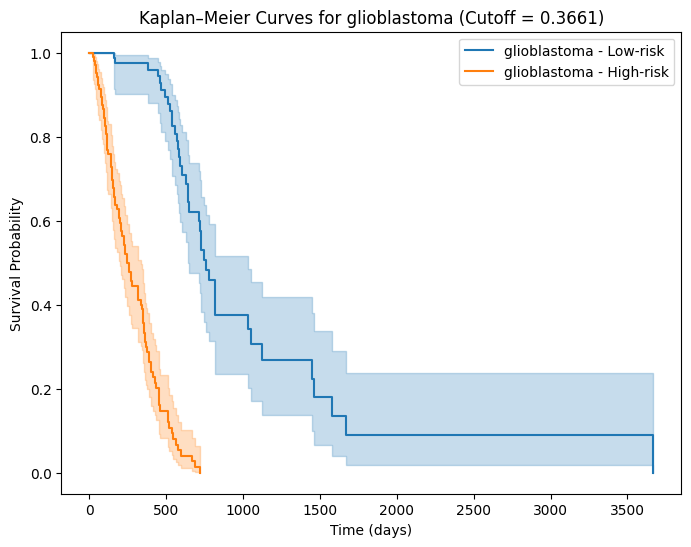

Log-rank test p-value for glioblastoma: 0.0000

--- Analyzing risk for astrocytoma ---
Maximum follow-up time for astrocytoma: 5255 days

For astrocytoma at t = 365 days:
RSF C-index: 0.938
Mean AUC at 365 days: 1.000

For astrocytoma at t = 1095 days:
RSF C-index: 0.938
Mean AUC at 1095 days: 0.947

For astrocytoma at t = 1825 days:
RSF C-index: 0.938
Mean AUC at 1825 days: 1.000

For astrocytoma at t = 2555 days:
RSF C-index: 0.938
Mean AUC at 2555 days: 1.000

Optimal cutoff for astrocytoma at 365 days: 0.0216 (log-rank p=0.0000)


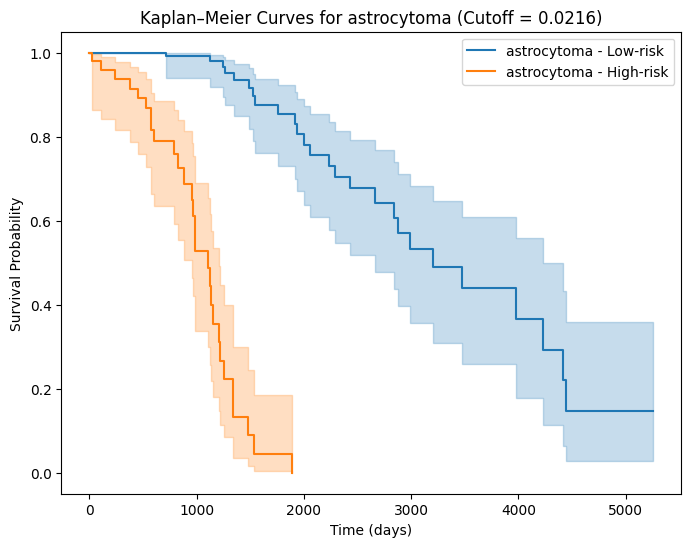

Log-rank test p-value for astrocytoma: 0.0000

--- Analyzing risk for oligodendroglioma ---
Maximum follow-up time for oligodendroglioma: 5546 days

For oligodendroglioma at t = 365 days:
RSF C-index: 0.975
Mean AUC at 365 days: nan

For oligodendroglioma at t = 1095 days:
RSF C-index: 0.975
Mean AUC at 1095 days: 0.978

For oligodendroglioma at t = 1825 days:
RSF C-index: 0.975
Mean AUC at 1825 days: 1.000

For oligodendroglioma at t = 2555 days:
RSF C-index: 0.975
Mean AUC at 2555 days: 1.000

Optimal cutoff for oligodendroglioma at 365 days: 0.0355 (log-rank p=0.0000)


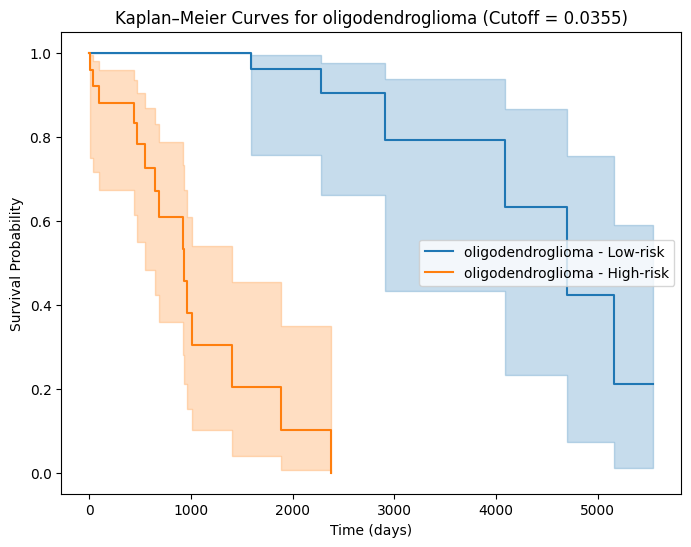

Log-rank test p-value for oligodendroglioma: 0.0000


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test  # correct import from lifelines.statistics
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import cumulative_dynamic_auc

random_state = 42

# -------------------------------
# Helper: Select Predictors
# -------------------------------
def select_predictors(df):
    """
    Select predictors from the DataFrame:
      - Methylation features: columns starting with 'cg'
      - MGMT column (if it exists)
      - Gene features: a specified list (if present)
      - Cancer type dummies from one-hot encoding of 'classification.2021_simplified.labels'
    """
    # Methylation features (columns starting with 'cg')
    cg_features = [col for col in df.columns if col.startswith("cg")]
    
    # Add MGMT column if it exists
    mgmt_feature = ['MGMT'] if 'MGMT' in df.columns else []
    
    # Gene features
    gene_features = ['RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR']
    gene_feats = [col for col in gene_features if col in df.columns]
    
    # One-hot encode cancer type if available
    if 'classification.2021_simplified.labels' in df.columns:
        dummies = pd.get_dummies(df['classification.2021_simplified.labels'], prefix='cancer')
        df = pd.concat([df, dummies], axis=1)
        dummy_cols = list(dummies.columns)
    else:
        dummy_cols = []
    
    # Combine all predictors
    predictors = cg_features + mgmt_feature + gene_feats + dummy_cols
    return predictors, df


# -------------------------------
# Compute Risk Scores using RSF
# -------------------------------
def compute_risk_scores(df_sub, eval_time):
    """
    For a given cancer subtype (df_sub), ensure survival data are numeric,
    extract predictors (methylation features, gene features, and cancer type dummies),
    fit an RSF model, and compute risk scores as 1 - S(eval_time).
    
    Returns:
      risk_scores: NumPy array of risk scores.
      model: Fitted RSF model.
      X: Predictor DataFrame.
      durations: Array of survival times.
      events: Array of event indicators.
      y_struct: Structured survival array.
    """
    df_sub = df_sub.copy()
    df_sub['OS.time'] = pd.to_numeric(df_sub['OS.time'], errors='coerce')
    df_sub = df_sub.dropna(subset=['OS.time', 'OS'])
    df_sub['OS'] = df_sub['OS'].astype(int)
    
    predictors, df_sub = select_predictors(df_sub)
    X = df_sub[predictors].copy()
    durations = df_sub['OS.time'].values
    events = df_sub['OS'].values.astype(bool)
    
    y_struct = np.array([(e, t) for e, t in zip(events, durations)],
                        dtype=[('event', '?'), ('time', '<f8')])
    
    rsf = RandomSurvivalForest(n_estimators=100,
                               min_samples_split=10,
                               min_samples_leaf=15,
                               max_features="sqrt",
                               n_jobs=-1,
                               random_state=random_state)
    rsf.fit(X, y_struct)
    
    surv_funcs = rsf.predict_survival_function(X)
    risk_scores = np.array([1 - fn(eval_time) for fn in surv_funcs])
    
    return risk_scores, rsf, X, durations, events, y_struct

# -------------------------------
# Find Optimal Cutoff via Log-rank Test
# -------------------------------
def find_optimal_cutoff(risk_scores, durations, events, candidate_quantiles=np.arange(10, 90, 5)):
    best_p = 1.0
    best_cutoff = None
    for q in candidate_quantiles:
        cutoff = np.percentile(risk_scores, q)
        low_mask = risk_scores < cutoff
        high_mask = risk_scores >= cutoff
        if low_mask.sum() < 5 or high_mask.sum() < 5:
            continue
        try:
            lr = logrank_test(durations[low_mask], durations[high_mask],
                              event_observed_A=events[low_mask],
                              event_observed_B=events[high_mask])
            p_val = lr.p_value
        except Exception:
            continue
        if p_val < best_p:
            best_p = p_val
            best_cutoff = cutoff
    if best_cutoff is None:
        best_cutoff = np.median(risk_scores)
        best_p = np.nan
    return best_cutoff, best_p

# -------------------------------
# Kaplan–Meier Plot for Risk Groups
# -------------------------------
def plot_km_for_subgroup(df_sub, risk_scores, cutoff, label):
    df_sub = df_sub.copy()
    df_sub['OS.time'] = pd.to_numeric(df_sub['OS.time'], errors='coerce')
    df_sub = df_sub.dropna(subset=['OS.time', 'OS'])
    df_sub['OS'] = df_sub['OS'].astype(int)
    df_sub['risk_score'] = risk_scores
    df_sub['risk_group'] = np.where(risk_scores < cutoff, 'Low-risk', 'High-risk')
    
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8,6))
    for grp in ['Low-risk', 'High-risk']:
        mask = df_sub['risk_group'] == grp
        durations_grp = df_sub.loc[mask, 'OS.time']
        events_grp = df_sub.loc[mask, 'OS']
        if durations_grp.size == 0:
            print(f"No data for {grp} group in {label}.")
            continue
        kmf.fit(durations_grp, event_observed=events_grp, label=f"{label} - {grp}")
        kmf.plot_survival_function(ci_show=True)
    plt.title(f"Kaplan–Meier Curves for {label} (Cutoff = {cutoff:.4f})")
    plt.xlabel("Time (days)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()
    
    low = df_sub[df_sub['risk_group'] == 'Low-risk']
    high = df_sub[df_sub['risk_group'] == 'High-risk']
    if low.empty or high.empty:
        print(f"Not enough data for log-rank test in {label}.")
    else:
        lr_results = logrank_test(low['OS.time'], high['OS.time'],
                                  event_observed_A=low['OS'],
                                  event_observed_B=high['OS'])
        print(f"Log-rank test p-value for {label}: {lr_results.p_value:.4f}")

# -------------------------------
# Compute Time-Dependent AUC
# -------------------------------
def compute_time_dependent_metrics(X, y_struct, model, time_points):
    from sksurv.metrics import cumulative_dynamic_auc
    X_train, X_test, y_train, y_test = train_test_split(X, y_struct, test_size=0.3, random_state=random_state)
    
    test_times = np.array([t for _, t in y_test])
    max_test_time = test_times.max()
    time_points_valid = time_points[time_points <= max_test_time]
    if len(time_points_valid) == 0:
        print("No valid time points in the test set.")
        return np.array([]), np.nan
    if len(time_points_valid) < len(time_points):
        print(f"Note: Using valid time points: {time_points_valid}")
    
    aucs, mean_auc = cumulative_dynamic_auc(y_train, y_test, model.predict(X_test), time_points_valid)
    return aucs, mean_auc

# -------------------------------
# Main Analysis by Cancer Type
# -------------------------------
def analyze_risk_by_cancer_type(final_df):
    """
    For each cancer type:
      - Compute RSF-based risk scores at fixed time intervals (1, 3, 5, 7 years).
      - Report overall performance (C-index) on the full subgroup.
      - Compute time-dependent AUC at these intervals.
      - Use risk scores at 1 year (365 days) to define risk groups via an optimal cutoff.
      - Plot Kaplan–Meier curves for low- and high-risk groups.
    """
    df = final_df[final_df['classification.2021_simplified.labels'] != 'unclassified'].copy()
    df['OS.time'] = pd.to_numeric(df['OS.time'], errors='coerce')
    cancer_types = df['classification.2021_simplified.labels'].unique()
    
    # Fixed time points (in days): 1, 3, 5, and 7 years.
    fixed_time_points = np.array([365, 1095, 1825, 2555])
    
    for ctype in cancer_types:
        print(f"\n--- Analyzing risk for {ctype} ---")
        df_sub = df[df['classification.2021_simplified.labels'] == ctype].copy()
        T_max = df_sub['OS.time'].max()
        print(f"Maximum follow-up time for {ctype}: {T_max:.0f} days")
        
        # Report time-dependent performance metrics at fixed intervals.
        for t in fixed_time_points:
            if t > T_max:
                continue
            risk_scores, model, X, durations, events, y_struct = compute_risk_scores(df_sub, t)
            print(f"\nFor {ctype} at t = {t} days:")
            c_index = model.score(X, y_struct)
            print(f"RSF C-index: {c_index:.3f}")
            aucs, mean_auc = compute_time_dependent_metrics(X, y_struct, model, np.array([t]))
            print(f"Mean AUC at {t} days: {mean_auc:.3f}")
        
        # Use risk scores at 1 year (365 days) to define risk groups.
        if 365 <= T_max:
            risk_scores, model, X, durations, events, y_struct = compute_risk_scores(df_sub, 365)
            cutoff, p_val = find_optimal_cutoff(risk_scores, durations, events)
            print(f"\nOptimal cutoff for {ctype} at 365 days: {cutoff:.4f} (log-rank p={p_val:.4f})")
            plot_km_for_subgroup(df_sub, risk_scores, cutoff, label=ctype)
        else:
            print(f"Not enough follow-up for 365 days risk stratification in {ctype}.")

if __name__ == "__main__":
    final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")
    analyze_risk_by_cancer_type(final_df)



--- Analyzing risk for glioblastoma ---
Maximum follow-up time for glioblastoma: 3667 days
Calculating SHAP values for risk scores at t = 365 days...
Computing SHAP values (this may take a while)...


  0%|          | 0/194 [00:00<?, ?it/s]

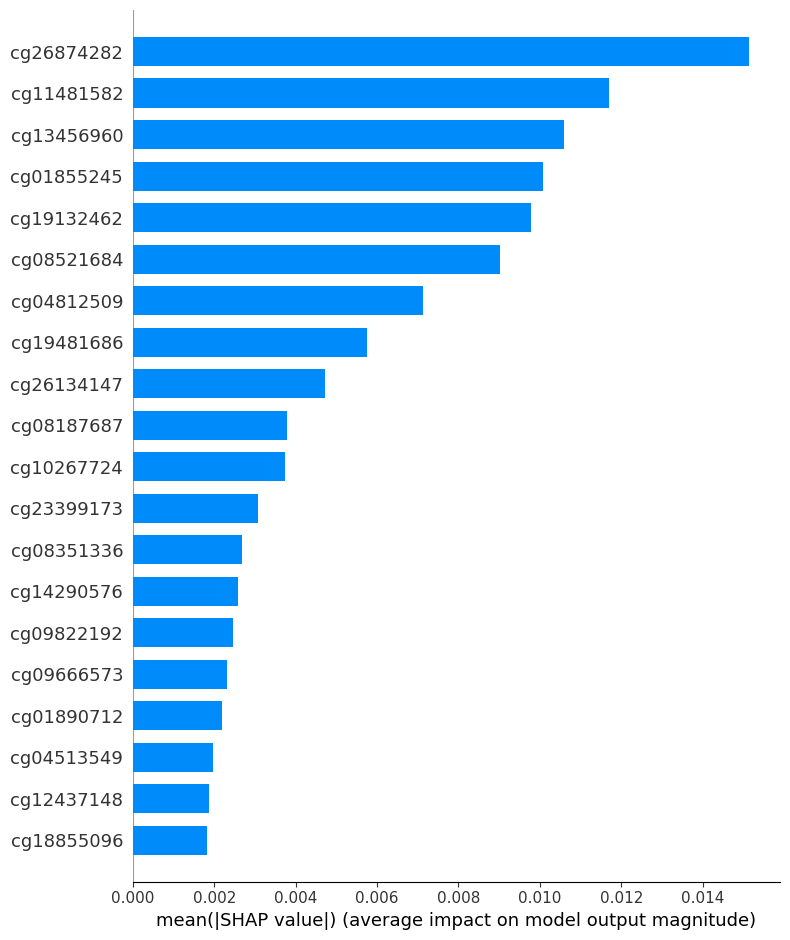

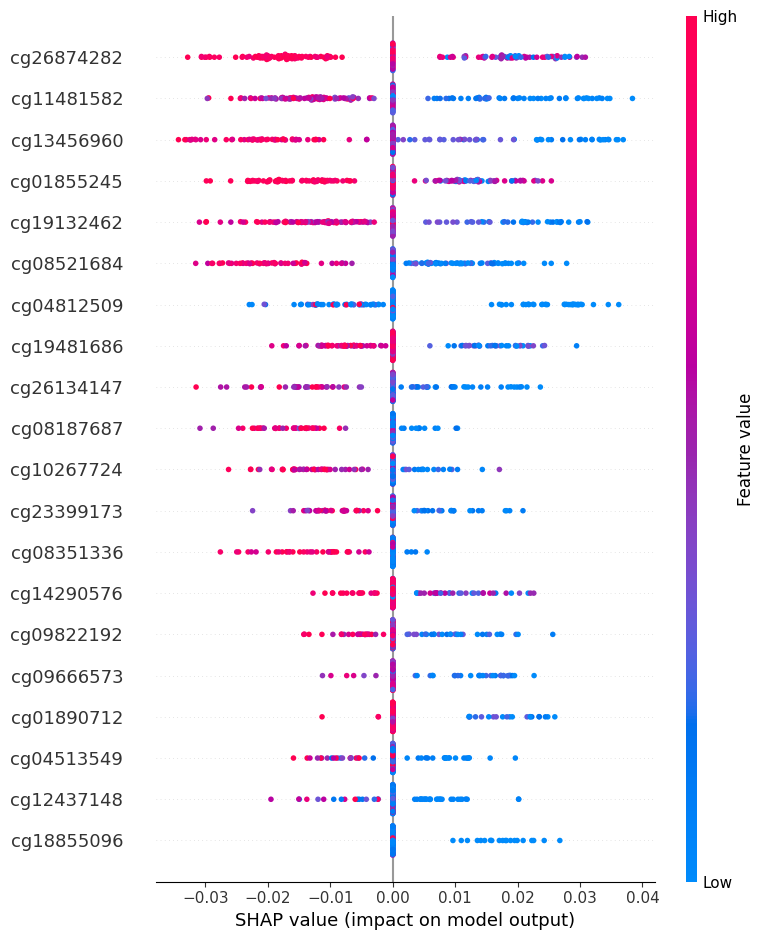


Optimal cutoff for glioblastoma at 365 days: 0.3935


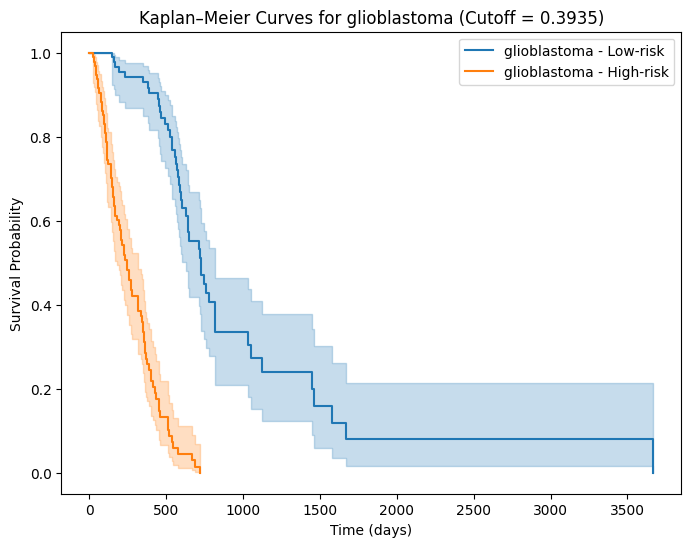


--- Analyzing risk for astrocytoma ---
Maximum follow-up time for astrocytoma: 5255 days
Calculating SHAP values for risk scores at t = 365 days...
Computing SHAP values (this may take a while)...


  0%|          | 0/256 [00:00<?, ?it/s]

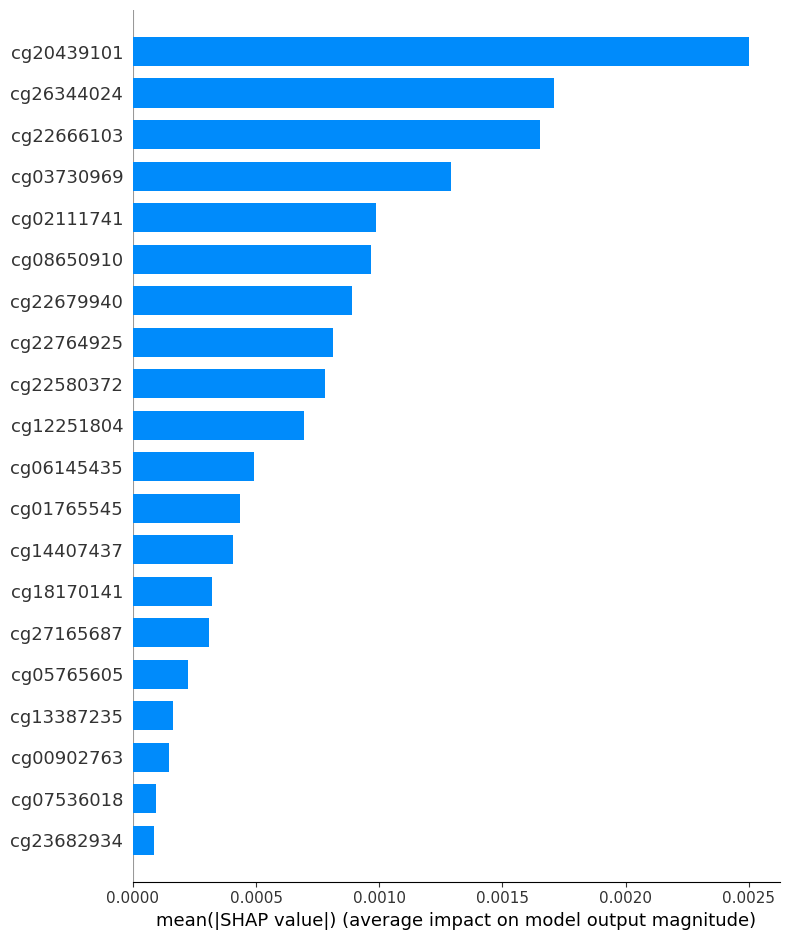

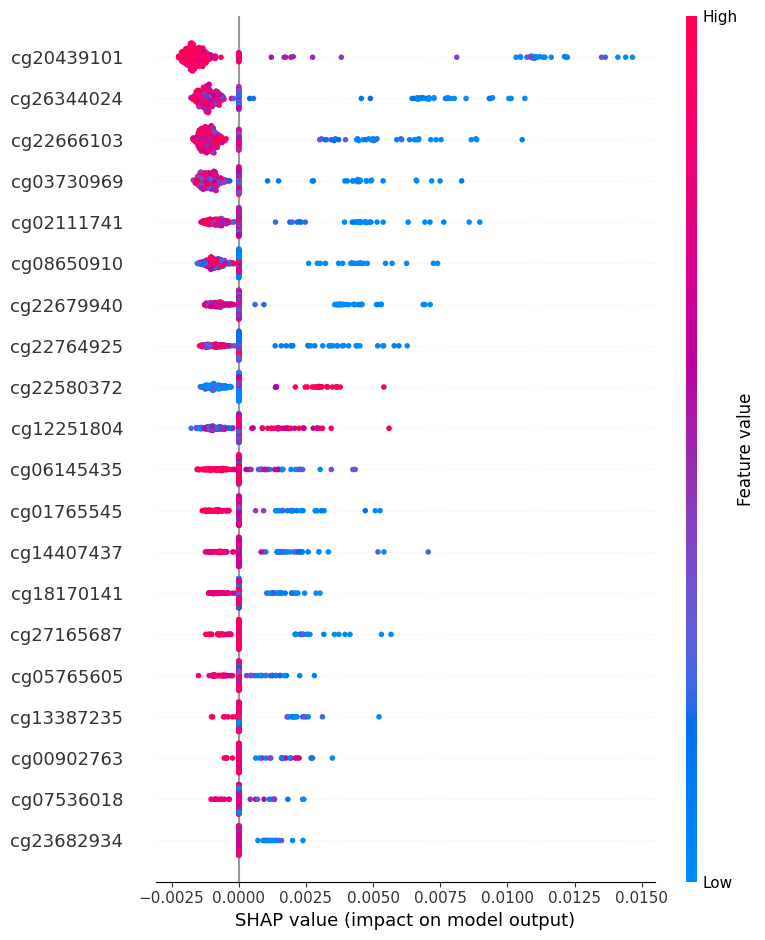


Optimal cutoff for astrocytoma at 365 days: 0.0067


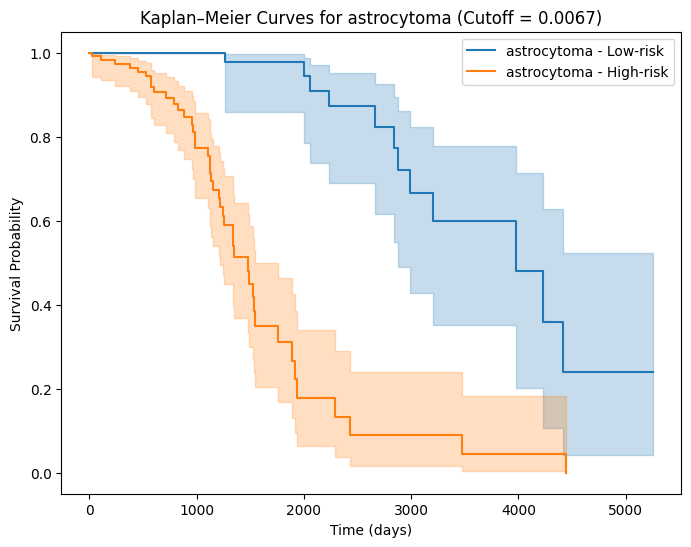


--- Analyzing risk for oligodendroglioma ---
Maximum follow-up time for oligodendroglioma: 5546 days
Calculating SHAP values for risk scores at t = 365 days...
Computing SHAP values (this may take a while)...


  0%|          | 0/168 [00:00<?, ?it/s]

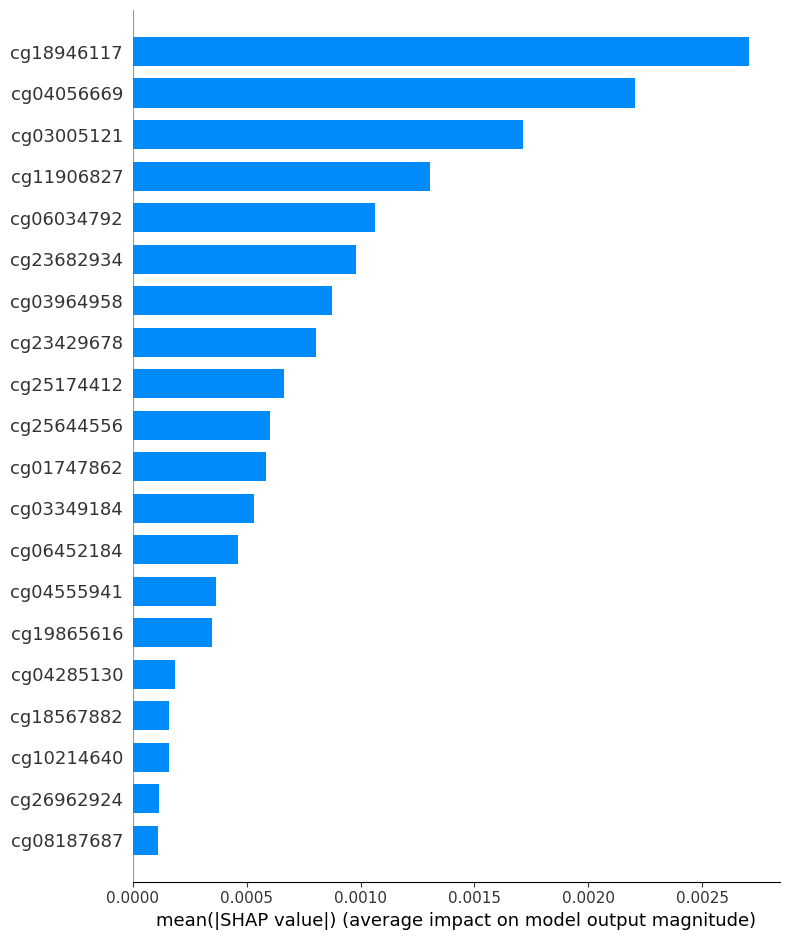

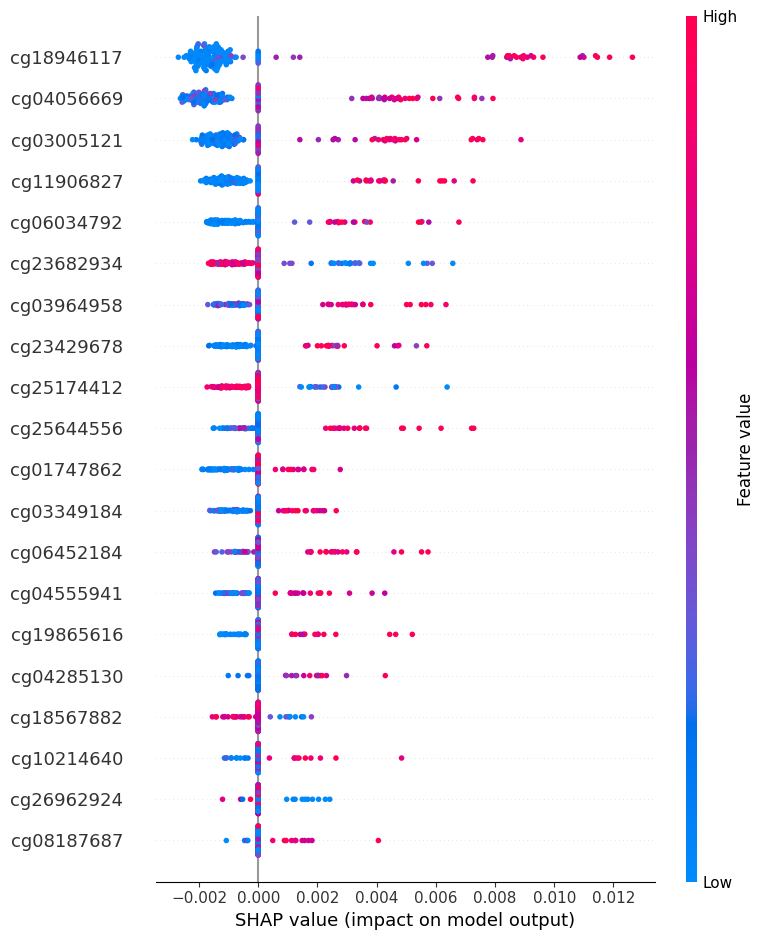


Optimal cutoff for oligodendroglioma at 365 days: 0.0141


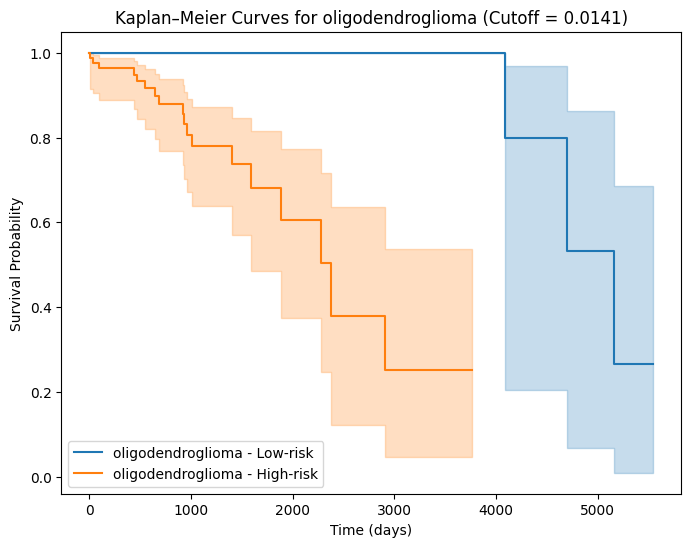

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import cumulative_dynamic_auc

random_state = 42

# -------------------------------
# Helper: Select Predictors
# -------------------------------
def select_predictors(df):
    """
    Select predictors from the DataFrame:
      - Methylation features: columns starting with 'cg'
      - MGMT column (if it exists)
      - Gene features (if present)
      - Cancer type dummies (from one-hot encoding)
    """
    # Methylation features (columns starting with 'cg')
    cg_features = [col for col in df.columns if col.startswith("cg")]
    
    # Include MGMT feature if available
    mgmt_feature = ['MGMT'] if 'MGMT' in df.columns else []
    
    # Gene features
    gene_features = ['RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR']
    gene_feats = [col for col in gene_features if col in df.columns]
    
    # One-hot encode cancer types
    if 'classification.2021_simplified.labels' in df.columns:
        dummies = pd.get_dummies(df['classification.2021_simplified.labels'], prefix='cancer')
        df = pd.concat([df, dummies], axis=1)
        dummy_cols = list(dummies.columns)
    else:
        dummy_cols = []
    
    predictors = cg_features + mgmt_feature + gene_feats + dummy_cols
    return predictors, df


# -------------------------------
# Compute Risk Scores using RSF
# -------------------------------
def compute_risk_scores(df_sub, eval_time):
    """
    Train RSF model, compute risk scores at a given time (eval_time).
    
    Returns:
      risk_scores: NumPy array of risk scores.
      model: Trained RSF model.
      X: Predictor DataFrame.
      durations, events: Survival data.
      y_struct: Structured survival array.
    """
    df_sub = df_sub.copy()
    df_sub['OS.time'] = pd.to_numeric(df_sub['OS.time'], errors='coerce')
    df_sub = df_sub.dropna(subset=['OS.time', 'OS'])
    df_sub['OS'] = df_sub['OS'].astype(int)
    
    predictors, df_sub = select_predictors(df_sub)
    X = df_sub[predictors].copy()
    durations = df_sub['OS.time'].values
    events = df_sub['OS'].values.astype(bool)
    
    y_struct = np.array([(e, t) for e, t in zip(events, durations)],
                        dtype=[('event', '?'), ('time', '<f8')])
    
    rsf = RandomSurvivalForest(n_estimators=100,
                               min_samples_split=10,
                               min_samples_leaf=15,
                               max_features="sqrt",
                               n_jobs=-1,
                               random_state=random_state)
    rsf.fit(X, y_struct)
    
    surv_funcs = rsf.predict_survival_function(X)
    risk_scores = np.array([1 - fn(eval_time) for fn in surv_funcs])
    
    return risk_scores, rsf, X, durations, events, y_struct


# -------------------------------
# SHAP Feature Importance Analysis
# -------------------------------
def explain_model_with_shap(model, X):
    """
    Use SHAP's KernelExplainer to compute SHAP values for RSF model's risk predictions.
    """
    print("Computing SHAP values (this may take a while)...")
    
    def predict_risk(X_input):
        """Wrapper function to get risk scores from RSF model."""
        surv_funcs = model.predict_survival_function(X_input)
        return np.array([1 - fn(365) for fn in surv_funcs])  # Using 365 days for risk scores

    # Sample a background dataset for KernelExplainer
    X_background = X.sample(n=min(100, len(X)), random_state=random_state)

    # Initialize KernelExplainer
    explainer = shap.KernelExplainer(predict_risk, X_background)

    # Compute SHAP values for all features
    shap_values = explainer.shap_values(X)

    # Plot feature importance
    shap.summary_plot(shap_values, X, plot_type="bar")  # Bar plot
    shap.summary_plot(shap_values, X)  # Beeswarm plot

    return shap_values


# -------------------------------
# Kaplan–Meier Plot for Risk Groups
# -------------------------------
def plot_km_for_subgroup(df_sub, risk_scores, cutoff, label):
    df_sub = df_sub.copy()
    df_sub['OS.time'] = pd.to_numeric(df_sub['OS.time'], errors='coerce')
    df_sub = df_sub.dropna(subset=['OS.time', 'OS'])
    df_sub['OS'] = df_sub['OS'].astype(int)
    df_sub['risk_score'] = risk_scores
    df_sub['risk_group'] = np.where(risk_scores < cutoff, 'Low-risk', 'High-risk')
    
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8,6))
    for grp in ['Low-risk', 'High-risk']:
        mask = df_sub['risk_group'] == grp
        durations_grp = df_sub.loc[mask, 'OS.time']
        events_grp = df_sub.loc[mask, 'OS']
        if durations_grp.size == 0:
            print(f"No data for {grp} group in {label}.")
            continue
        kmf.fit(durations_grp, event_observed=events_grp, label=f"{label} - {grp}")
        kmf.plot_survival_function(ci_show=True)
    plt.title(f"Kaplan–Meier Curves for {label} (Cutoff = {cutoff:.4f})")
    plt.xlabel("Time (days)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()


# -------------------------------
# Main Analysis by Cancer Type
# -------------------------------
def analyze_risk_by_cancer_type(final_df):
    """
    For each cancer type:
      - Train RSF and compute risk scores.
      - Compute SHAP values for risk scores.
      - Perform risk stratification and plot Kaplan–Meier curves.
    """
    df = final_df[final_df['classification.2021_simplified.labels'] != 'unclassified'].copy()
    df['OS.time'] = pd.to_numeric(df['OS.time'], errors='coerce')
    cancer_types = df['classification.2021_simplified.labels'].unique()
    
    for ctype in cancer_types:
        print(f"\n--- Analyzing risk for {ctype} ---")
        df_sub = df[df['classification.2021_simplified.labels'] == ctype].copy()
        T_max = df_sub['OS.time'].max()
        print(f"Maximum follow-up time for {ctype}: {T_max:.0f} days")
        
        if 365 > T_max:
            print(f"Not enough follow-up for 365 days risk stratification in {ctype}.")
            continue
        
        # Compute risk scores at 1 year (365 days)
        risk_scores, model, X, durations, events, y_struct = compute_risk_scores(df_sub, 365)
        
        # Compute SHAP values to interpret RSF model
        print("Calculating SHAP values for risk scores at t = 365 days...")
        shap_values = explain_model_with_shap(model, X)
        
        # Determine the best cutoff for risk stratification
        cutoff = np.percentile(risk_scores, 50)  # Median cutoff
        print(f"\nOptimal cutoff for {ctype} at 365 days: {cutoff:.4f}")

        # Kaplan-Meier survival analysis
        plot_km_for_subgroup(df_sub, risk_scores, cutoff, label=ctype)


# -------------------------------
# Run the Analysis
# -------------------------------
if __name__ == "__main__":
    final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")
    analyze_risk_by_cancer_type(final_df)


In [45]:
final_df.columns

Index(['Sample', 'RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR',
       'Sample_Name', 'Patient_ID',
       ...
       'cg04285130', 'cg10267724', 'cg06908895', 'cg05389922', 'cg27660920',
       'cg26118698', 'cg22764925', 'cg03005121', 'cg12434587', 'cg12981137'],
      dtype='object', length=157)

In [48]:
print(final_df.columns.tolist())


['Sample', 'RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR', 'Sample_Name', 'Patient_ID', 'OS.time', 'OS', 'classification.2021_simplified.labels', 'cg12601945', 'cg26557658', 'cg14407437', 'cg27165687', 'cg27304110', 'cg19693031', 'cg11075509', 'cg03221073', 'cg25771140', 'cg12437148', 'cg23399173', 'cg14754761', 'cg02458113', 'cg15355298', 'cg14692854', 'cg02878891', 'cg22580372', 'cg19865616', 'cg18946117', 'cg08187687', 'cg03964958', 'cg19187155', 'cg06860600', 'cg09666573', 'cg00857862', 'cg06859735', 'cg26344024', 'cg04148458', 'cg00902763', 'cg08521684', 'cg04056669', 'cg05789005', 'cg14959580', 'cg26685352', 'cg06452184', 'cg10785622', 'cg02549628', 'cg09098545', 'cg03730969', 'cg21499459', 'cg01747862', 'cg04555941', 'cg20439101', 'cg06821992', 'cg08351336', 'cg01765545', 'cg16225168', 'cg07536018', 'cg23429678', 'cg15421962', 'cg04446284', 'cg13971262', 'cg03349184', 'cg00334245', 'cg23778363', 'cg15298323', 'cg05228964', 'cg06145435', 'cg08650910', 'cg22772747', '

In [60]:
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

In [61]:
import numpy as np
import pandas as pd
from sksurv.svm import FastKernelSurvivalSVM
from sksurv.util import Surv
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Avoid division by zero for Beta values near 0 or 1
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))  # Convert to M values
M2 = np.log2(B2 / (1 - B2))  # Convert to M values

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))  # Apply inverse logit transformation

# Add MGMT column to the dataset
final_df["MGMT"] = MGMT

# Remove original probe columns
final_df.drop(columns=mgmt_probes, inplace=True)

print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Handle Missing Values and Invalid OS.time
# -----------------------------------------------------------------------------
# Drop rows where OS.time is missing
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()

# Remove rows where OS.time is zero or negative
final_df = final_df[final_df["OS.time"] > 0].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after removing invalid survival times.")

# -----------------------------------------------------------------------------
# Prepare Data for Survival-SVM
# -----------------------------------------------------------------------------
# Select Methylation, Gene, and MGMT Features
methylation_features = [col for col in final_df.columns if col.startswith("cg")]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]  # Keep only existing columns
extra_features = ["MGMT"]  # Only MGMT now

# Survival and Cancer Labels
survival_event_col = "OS"
survival_time_col = "OS.time"
cancer_label_col = "classification.2021_simplified.labels"

# Prepare Feature Matrix (X) and Target (y)
feature_cols = methylation_features + gene_features + extra_features
X = final_df[feature_cols].copy()

# Handle NaN values in features
X = X.fillna(X.median())  # Fill missing values with median

# ✅ FIXED: Store Original Indices Before Transforming
X_indices = X.index  # Save original indices

# ✅ FIXED: Correct Surv.from_dataframe() syntax
y = Surv.from_dataframe(survival_event_col, survival_time_col, final_df)

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ FIXED: Keep Track of Indices When Splitting Data
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X_scaled, y, X_indices, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
)

# Train Survival-SVM Model
surv_svm = FastKernelSurvivalSVM(kernel="rbf", alpha=1e-4, gamma=0.1)
surv_svm.fit(X_train, y_train)

# Evaluate Model Performance
score = surv_svm.score(X_test, y_test)
print(f"✅ Concordance Index (C-index): {score:.4f}")

# Predict Risk Scores (Higher score = Higher risk)
risk_scores = surv_svm.predict(X_test)

# ✅ FIXED: Use `test_idx` Instead of `X_test.index`
results_df = final_df.loc[test_idx].copy()
results_df["Risk_Score"] = risk_scores



✅ MGMT column created and probes removed!
✅ Filtered dataset: 648 rows remaining after removing invalid survival times.
✅ Concordance Index (C-index): 0.7831


In [64]:
import shap
from sksurv.ensemble import RandomSurvivalForest

# Define feature groups
mgmt_features = ["MGMT"]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
methylation_features = [col for col in final_df.columns if col.startswith("cg")]

# Train separate RSF models for each feature group
feature_sets = {
    "MGMT Only": mgmt_features,
    "Gene Features": gene_features,
    "Methylation Features": methylation_features,
}

In [65]:
from sksurv.svm import FastKernelSurvivalSVM

# Store C-index scores
c_index_results = {}

for name, features in feature_sets.items():
    X_subset = final_df[features].copy()
    X_subset = X_subset.fillna(X_subset.median())  # Handle NaNs
    X_scaled = scaler.fit_transform(X_subset)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
    )

    # Train Survival-SVM
    surv_svm = FastKernelSurvivalSVM(kernel="rbf", alpha=1e-4, gamma=0.1)
    surv_svm.fit(X_train, y_train)

    # Evaluate Model Performance
    score = surv_svm.score(X_test, y_test)
    c_index_results[name] = score
    print(f"✅ C-index for {name}: {score:.4f}")


✅ C-index for MGMT Only: 0.6432
✅ C-index for Gene Features: 0.7354
✅ C-index for Methylation Features: 0.8101


In [66]:
# Use all features: Methylation + Genes + MGMT
all_features = methylation_features + gene_features + ["MGMT"]
X_combined = final_df[all_features].copy()
X_combined = X_combined.fillna(X_combined.median())  # Handle missing values
X_scaled_combined = scaler.fit_transform(X_combined)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_combined, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
)

# Train Survival-SVM Model
surv_svm_combined = FastKernelSurvivalSVM(kernel="rbf", alpha=1e-4, gamma=0.1)
surv_svm_combined.fit(X_train, y_train)

# Evaluate Performance
c_index_combined = surv_svm_combined.score(X_test, y_test)
print(f"✅ C-index for Combined Model: {c_index_combined:.4f}")


✅ C-index for Combined Model: 0.7831


In [68]:
import optuna
from sksurv.svm import FastKernelSurvivalSVM
from sklearn.model_selection import train_test_split

# Function to Optimize Hyperparameters
def objective(trial):
    # Define Search Space
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
    alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-1)  # Regularization
    gamma = trial.suggest_loguniform("gamma", 1e-6, 1e1)  # Kernel coefficient
    
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled_combined, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
    )

    # Train Survival-SVM
    surv_svm = FastKernelSurvivalSVM(kernel=kernel, alpha=alpha, gamma=gamma)
    surv_svm.fit(X_train, y_train)

    # Evaluate Performance (C-index)
    return surv_svm.score(X_test, y_test)

# Run Optuna Optimization
study = optuna.create_study(direction="maximize")  # Maximize C-index
study.optimize(objective, n_trials=50)

# Best Hyperparameters
print("✅ Best hyperparameters:", study.best_params)
print("✅ Best C-index:", study.best_value)


[I 2025-03-12 00:05:59,525] A new study created in memory with name: no-name-3ab24328-ef4f-41e9-8f6e-4be0e8dd0f9d
[I 2025-03-12 00:06:00,352] Trial 0 finished with value: 0.8572877916807575 and parameters: {'kernel': 'poly', 'alpha': 0.06956855569878734, 'gamma': 0.0004792845859254546}. Best is trial 0 with value: 0.8572877916807575.
[I 2025-03-12 00:06:00,412] Trial 1 finished with value: 0.8532296246195469 and parameters: {'kernel': 'linear', 'alpha': 1.0246467617483138e-06, 'gamma': 1.3131496645208e-05}. Best is trial 0 with value: 0.8572877916807575.
[I 2025-03-12 00:06:00,747] Trial 2 finished with value: 0.8393642204937437 and parameters: {'kernel': 'poly', 'alpha': 0.0003626992220892789, 'gamma': 4.533727248654554e-06}. Best is trial 0 with value: 0.8572877916807575.
[I 2025-03-12 00:06:01,338] Trial 3 finished with value: 0.8403787622590463 and parameters: {'kernel': 'poly', 'alpha': 0.013705520567018013, 'gamma': 1.1339774198651182e-06}. Best is trial 0 with value: 0.857287791

✅ Best hyperparameters: {'kernel': 'poly', 'alpha': 0.03595075898748086, 'gamma': 0.012441802385449147}
✅ Best C-index: 0.8745350016909029


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sksurv.svm import FastKernelSurvivalSVM
from sksurv.util import Surv

# -----------------------------------------------------------------------------
# Load Dataset
# -----------------------------------------------------------------------------
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# -----------------------------------------------------------------------------
# Ensure the two probe columns exist
# -----------------------------------------------------------------------------
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Avoid division by zero for Beta values near 0 or 1
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))  # Convert to M values
M2 = np.log2(B2 / (1 - B2))  # Convert to M values

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))  # Apply inverse logit transformation

# Add MGMT column to the dataset
final_df["MGMT"] = MGMT

# Remove original probe columns
final_df.drop(columns=mgmt_probes, inplace=True)

print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Handle Missing Values and Invalid OS.time
# -----------------------------------------------------------------------------
# Drop rows where OS.time is missing
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()

# Remove rows where OS.time is zero or negative
final_df = final_df[final_df["OS.time"] > 0].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after removing invalid survival times.")

# -----------------------------------------------------------------------------
# Prepare Data for Survival-SVM
# -----------------------------------------------------------------------------
# Select Methylation, Gene, and MGMT Features
methylation_features = [col for col in final_df.columns if col.startswith("cg")]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]  # Keep only existing columns
extra_features = ["MGMT"]  # Only MGMT now

# Survival and Cancer Labels
survival_event_col = "OS"
survival_time_col = "OS.time"
cancer_label_col = "classification.2021_simplified.labels"

# -----------------------------------------------------------------------------
# Include Cancer Type as a Feature
# -----------------------------------------------------------------------------
final_df[cancer_label_col] = final_df[cancer_label_col].astype(str)  # Ensure categorical format

# One-Hot Encode Cancer Type
encoder = OneHotEncoder(sparse_output=False, drop="first")  # Avoid multicollinearity
cancer_encoded = encoder.fit_transform(final_df[[cancer_label_col]])
cancer_encoded_df = pd.DataFrame(
    cancer_encoded, columns=encoder.get_feature_names_out([cancer_label_col])
)

# -----------------------------------------------------------------------------
# Combine All Features: Methylation + Genes + MGMT + Encoded Cancer Type
# -----------------------------------------------------------------------------
all_features = methylation_features + gene_features + extra_features
X_combined = final_df[all_features].copy()

# Handle Missing Values
X_combined = X_combined.fillna(X_combined.median())

# Append Encoded Cancer Type
X_combined = pd.concat([X_combined.reset_index(drop=True), cancer_encoded_df], axis=1)

# Standardize Features
scaler = StandardScaler()
X_scaled_combined = scaler.fit_transform(X_combined)

# Convert survival data
y = Surv.from_dataframe(survival_event_col, survival_time_col, final_df)


# -----------------------------------------------------------------------------
# Train/Test Split (Stratify by Cancer Type)
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_combined, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
)

# -----------------------------------------------------------------------------
# Train Survival-SVM Model
# -----------------------------------------------------------------------------
surv_svm_combined = FastKernelSurvivalSVM(kernel="rbf", alpha=1e-4, gamma=0.1)
surv_svm_combined.fit(X_train, y_train)

# Evaluate Performance
c_index_combined = surv_svm_combined.score(X_test, y_test)
print(f"✅ C-index for Combined Model: {c_index_combined:.4f}")

# -----------------------------------------------------------------------------
# Optimize Hyperparameters using Optuna
# -----------------------------------------------------------------------------
def objective(trial):
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
    alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-1)
    gamma = trial.suggest_loguniform("gamma", 1e-6, 1e1)

    # Train/Test Split (Stratify by Cancer Type)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled_combined, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
    )

    # Train Survival-SVM
    surv_svm = FastKernelSurvivalSVM(kernel=kernel, alpha=alpha, gamma=gamma)
    surv_svm.fit(X_train, y_train)

    # Evaluate Performance (C-index)
    return surv_svm.score(X_test, y_test)

# Run Optuna Optimization
study = optuna.create_study(direction="maximize")  # Maximize C-index
study.optimize(objective, n_trials=50)

# Best Hyperparameters
print("✅ Best hyperparameters:", study.best_params)
print("✅ Best C-index:", study.best_value)


[I 2025-03-12 00:39:02,273] A new study created in memory with name: no-name-e8c8960c-2be7-4b79-87dc-6794a8f4ee35


✅ MGMT column created and probes removed!
✅ Filtered dataset: 648 rows remaining after removing invalid survival times.
✅ C-index for Combined Model: 0.8301


[I 2025-03-12 00:39:02,923] Trial 0 finished with value: 0.8386878593168752 and parameters: {'kernel': 'poly', 'alpha': 0.0009321785096397205, 'gamma': 3.7250502829119593e-06}. Best is trial 0 with value: 0.8386878593168752.
[I 2025-03-12 00:39:02,976] Trial 1 finished with value: 0.8430842069665201 and parameters: {'kernel': 'linear', 'alpha': 6.628863243990322e-06, 'gamma': 0.00019458688192215408}. Best is trial 1 with value: 0.8430842069665201.
[I 2025-03-12 00:39:03,012] Trial 2 finished with value: 0.8430842069665201 and parameters: {'kernel': 'linear', 'alpha': 3.3094708549251054e-06, 'gamma': 0.001246343460388246}. Best is trial 1 with value: 0.8430842069665201.
[I 2025-03-12 00:39:03,046] Trial 3 finished with value: 0.8430842069665201 and parameters: {'kernel': 'linear', 'alpha': 6.412756338502716e-06, 'gamma': 0.00020261045396737442}. Best is trial 1 with value: 0.8430842069665201.
[I 2025-03-12 00:39:03,070] Trial 4 finished with value: 0.8437605681433886 and parameters: {'k

✅ Best hyperparameters: {'kernel': 'poly', 'alpha': 0.0035862048690675076, 'gamma': 0.011855271600393092}
✅ Best C-index: 0.8735204599256002


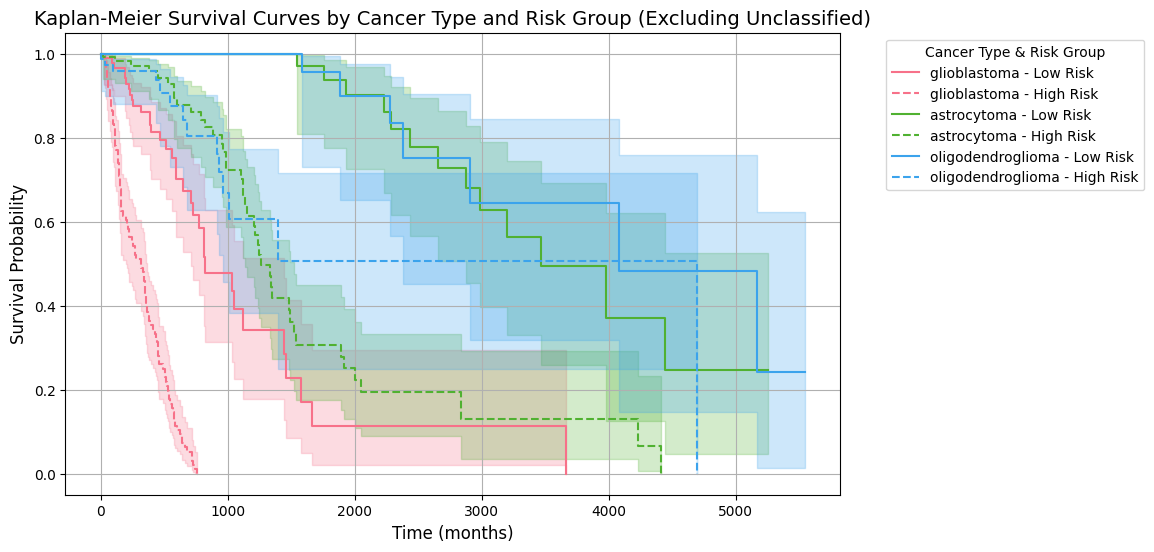

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter  # Correct import

# Step 1: Predict Risk Scores
risk_scores = surv_svm_combined.predict(X_scaled_combined)  # Use `.predict()` instead

# Step 2: Assign Risk Scores to DataFrame
final_df["Risk Score"] = risk_scores

# Filter Out Unclassified Cancer Types
unclassified_label = "unclassified"  # Change this if the label is different
final_df = final_df[final_df[cancer_label_col] != unclassified_label].copy()

# Recalculate Cancer Types After Filtering
cancer_types = final_df[cancer_label_col].unique()

# Step 3: Assign High/Low Risk Within Each Cancer Type
final_df["Risk Group"] = "Low Risk"  # Default to Low Risk
for cancer in cancer_types:
    subset = final_df[final_df[cancer_label_col] == cancer]
    median_risk = subset["Risk Score"].median()
    final_df.loc[(final_df[cancer_label_col] == cancer) & 
                 (final_df["Risk Score"] > median_risk), "Risk Group"] = "High Risk"

# Step 4: Prepare Data for Kaplan-Meier Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors for clarity
colors = sns.color_palette("husl", len(cancer_types))  # Different colors for each cancer type

for i, cancer in enumerate(cancer_types):
    for risk_group, linestyle in zip(["Low Risk", "High Risk"], ["solid", "dashed"]):
        # Filter the data
        subset = final_df[(final_df[cancer_label_col] == cancer) & (final_df["Risk Group"] == risk_group)]
        
        # Prepare survival data
        T = subset["OS.time"].values
        E = subset["OS"].values
        
        # Fit Kaplan-Meier model
        kmf = KaplanMeierFitter()
        kmf.fit(T, E, label=f"{cancer} - {risk_group}")
        
        # Plot the survival curve
        kmf.plot(ax=ax, color=colors[i], linestyle=linestyle)

# Step 5: Customize the Plot
ax.set_title("Kaplan-Meier Survival Curves by Cancer Type and Risk Group (Excluding Unclassified)", fontsize=14)
ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
ax.legend(title="Cancer Type & Risk Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()


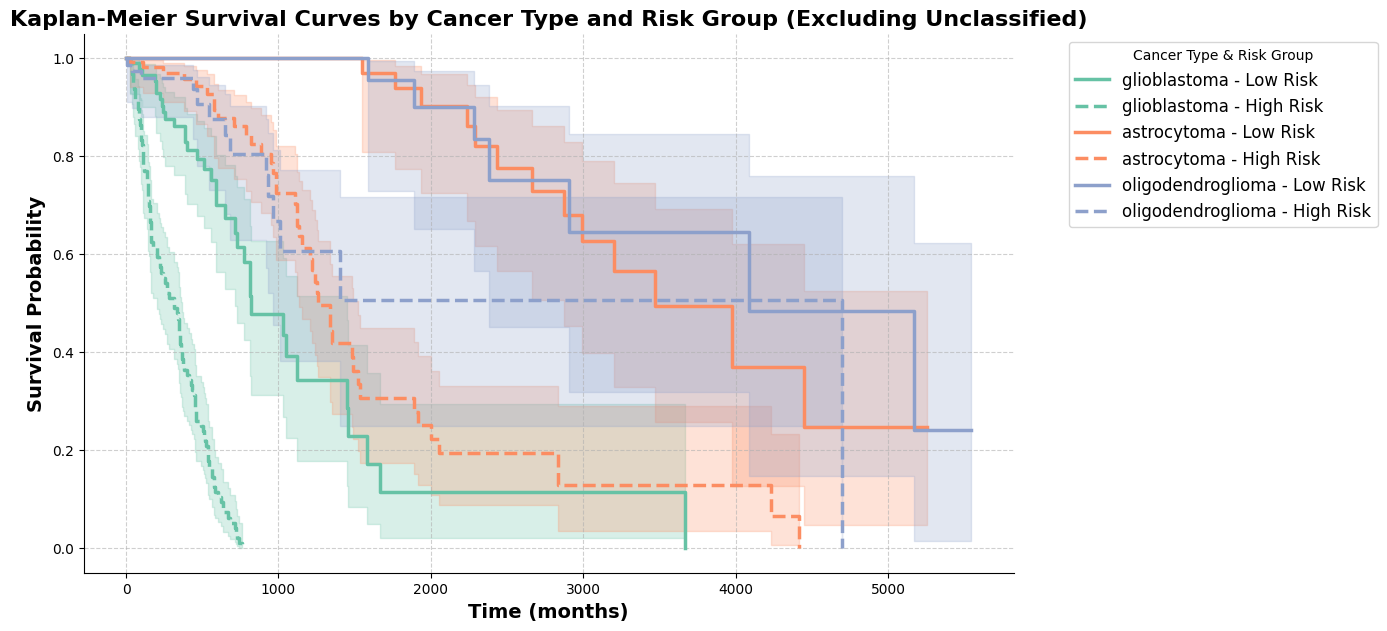

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter

# Step 4: Prepare Data for Kaplan-Meier Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for clarity
colors = sns.color_palette("Set2", len(cancer_types))  # Improved color scheme

for i, cancer in enumerate(cancer_types):
    for risk_group, linestyle in zip(["Low Risk", "High Risk"], ["solid", "dashed"]):
        # Filter the data
        subset = final_df[(final_df[cancer_label_col] == cancer) & (final_df["Risk Group"] == risk_group)]
        
        if subset.shape[0] == 0:
            continue  # Skip if no data for this category

        # Prepare survival data
        T = subset["OS.time"].values
        E = subset["OS"].values
        
        # Fit Kaplan-Meier model
        kmf = KaplanMeierFitter()
        kmf.fit(T, E, label=f"{cancer} - {risk_group}")
        
        # Plot the survival curve with thicker lines
        kmf.plot(ax=ax, color=colors[i], linestyle=linestyle, linewidth=2.5)

# Step 5: Customize the Plot
ax.set_title("Kaplan-Meier Survival Curves by Cancer Type and Risk Group (Excluding Unclassified)", fontsize=16, fontweight="bold")
ax.set_xlabel("Time (months)", fontsize=14, fontweight="bold")
ax.set_ylabel("Survival Probability", fontsize=14, fontweight="bold")
ax.legend(title="Cancer Type & Risk Group", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(True, linestyle="--", alpha=0.6)

# Show plot
plt.show()


<lifelines.CoxPHFitter: fitted with 614 total observations, 409 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
      baseline estimation = breslow
   number of observations = 614
number of events observed = 205
   partial log-likelihood = -759.10
         time fit was run = 2025-03-12 07:45:52 UTC

---
                                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                
cg12601945                                               1.90      6.72      0.97           -0.00            3.81                1.00               45.33
cg26557658                                               3.30     27.04      1.50            0.35            6.25                1.42              516.40
cg14407437                                              -1.52      0.22      0.90           -3.28            0.25                0.04                1.28
cg27165687                                              -1.11      0.33      1.30           -3.66            1.44                0.03                4.20
cg27304110                                              -4.30      0.01      2.01           -8.23           -0.36                0.00                0.70
cg19693031                                              -1.04      0.35      0.77           -2.54            0.47                0.08                1.59
cg11075509                                              -1.40      0.25      1.12           -3.59            0.79                0.03                2.21
cg03221073                                              -0.78      0.46      1.01           -2.77            1.20                0.06                3.31
cg25771140                                              -1.03      0.36      0.89           -2.78            0.72                0.06                2.06
cg12437148                                              -0.99      0.37      0.95           -2.85            0.87                0.06                2.39
cg23399173                                               0.37      1.45      1.37           -2.32            3.07                0.10               21.44
cg14754761                                              -6.40      0.00      2.70          -11.70           -1.11                0.00                0.33
cg02458113                                              -1.46      0.23      1.66           -4.72            1.79                0.01                6.00
cg15355298                                               1.33      3.80      2.36           -3.30            5.96                0.04              389.50
cg14692854                                               0.49      1.63      1.10           -1.67            2.66                0.19               14.24
cg02878891                                              -1.71      0.18      0.72           -3.11           -0.30                0.04                0.74
cg22580372                                               1.71      5.52      1.20           -0.65            4.07                0.52               58.50
cg19865616                                              -3.02      0.05      1.77           -6.50            0.45                0.00                1.57
cg18946117                                              -0.33      0.72      1.53           -3.33            2.67                0.04               14.49
cg08187687                                               0.22      1.24      0.84           -1.43            1.86                0.24                6.42
cg03964958                                              -0.15      0.86      0.93           -1.98            1.68                0.14                5.36
cg19187155                                               0.37      1.45      0.62           -0.84    

<Axes: xlabel='log(HR) (95% CI)'>

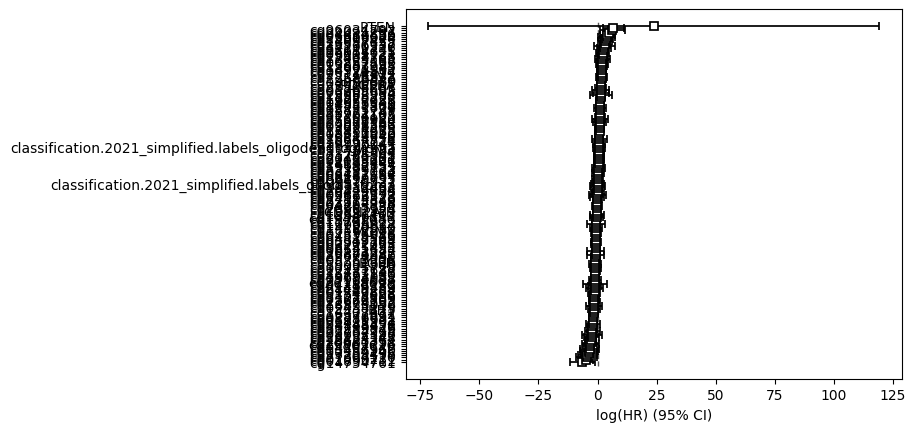

In [98]:
from lifelines import CoxPHFitter
import pandas as pd

# Step 1: Prepare Data for Cox Model
cox_df = final_df.copy()

# Convert categorical variable (Cancer Type) into dummy variables
cox_df = pd.get_dummies(cox_df, columns=[cancer_label_col], drop_first=True)  # One-hot encode cancer types

# Select relevant features
cox_features = methylation_features + gene_features + ["MGMT"] + list(cox_df.columns[cox_df.columns.str.startswith(cancer_label_col)])
cox_df = cox_df[cox_features + ["OS.time", "OS"]]

# Step 2: Fit Cox Proportional Hazards Model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="OS.time", event_col="OS")

# Step 3: Display Results
cph.print_summary()  # Shows hazard ratios, p-values, and confidence intervals

# Step 4: Plot Hazard Ratios
cph.plot()  # Visualizes predictor importance


In [103]:
import numpy as np
import pandas as pd
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

# Load the dataset
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Avoid division by zero for Beta values near 0 or 1
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))  # Convert to M values
M2 = np.log2(B2 / (1 - B2))  # Convert to M values

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))  # Apply inverse logit transformation

# Add MGMT column to the dataset
final_df["MGMT"] = MGMT

# Remove original probe columns
final_df.drop(columns=mgmt_probes, inplace=True)

print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Handle Missing Values and Invalid OS.time
# -----------------------------------------------------------------------------
# Drop rows where OS.time is missing
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()

# Remove rows where OS.time is zero or negative
final_df = final_df[final_df["OS.time"] > 0].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after removing invalid survival times.")

# -----------------------------------------------------------------------------
# Prepare Data for Random Survival Forest
# -----------------------------------------------------------------------------
# Select Methylation, Gene, and MGMT Features
methylation_features = [col for col in final_df.columns if col.startswith("cg")]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]  # Keep only existing columns
extra_features = ["MGMT"]

# Survival and Cancer Labels
survival_event_col = "OS"
survival_time_col = "OS.time"
cancer_label_col = "classification.2021_simplified.labels"

# Prepare Feature Matrix (X) and Target (y)
feature_cols = methylation_features + gene_features + extra_features
X = final_df[feature_cols].copy()

# Handle NaN values in features
X = X.fillna(X.median())  # Fill missing values with median

# Convert survival data
y = Surv.from_dataframe(event=survival_event_col, time=survival_time_col, data=final_df)

# Train-Test Split (No Scaling Applied)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
)

# Train Random Survival Forest Model
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rsf.fit(X_train, y_train)

# Evaluate Model Performance
c_index = rsf.score(X_test, y_test)
print(f"✅ Concordance Index (C-index): {c_index:.4f}")

# Predict Risk Scores (Higher score = Higher risk)
risk_scores = rsf.predict(X_test)

# Save results
results_df = final_df.loc[X_test.index].copy()
results_df["Risk_Score"] = risk_scores

print("✅ Random Survival Forest Model Training Complete!")


✅ MGMT column created and probes removed!
✅ Filtered dataset: 648 rows remaining after removing invalid survival times.
✅ Concordance Index (C-index): 0.8394
✅ Random Survival Forest Model Training Complete!


In [104]:
import numpy as np
import pandas as pd
import optuna
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

# Load the dataset
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Avoid division by zero for Beta values near 0 or 1
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))  # Convert to M values
M2 = np.log2(B2 / (1 - B2))  # Convert to M values

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))  # Apply inverse logit transformation

# Add MGMT column to the dataset
final_df["MGMT"] = MGMT

# Remove original probe columns
final_df.drop(columns=mgmt_probes, inplace=True)

print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Handle Missing Values and Invalid OS.time
# -----------------------------------------------------------------------------
# Drop rows where OS.time is missing
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()

# Remove rows where OS.time is zero or negative
final_df = final_df[final_df["OS.time"] > 0].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after removing invalid survival times.")

# -----------------------------------------------------------------------------
# Prepare Data for Random Survival Forest
# -----------------------------------------------------------------------------
# Select Methylation, Gene, and MGMT Features
methylation_features = [col for col in final_df.columns if col.startswith("cg")]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]  # Keep only existing columns
extra_features = ["MGMT"]

# Survival and Cancer Labels
survival_event_col = "OS"
survival_time_col = "OS.time"
cancer_label_col = "classification.2021_simplified.labels"

# Prepare Feature Matrix (X) and Target (y)
feature_cols = methylation_features + gene_features + extra_features
X = final_df[feature_cols].copy()

# Handle NaN values in features
X = X.fillna(X.median())  # Fill missing values with median

# Convert survival data
y = Surv.from_dataframe(event=survival_event_col, time=survival_time_col, data=final_df)

# Train-Test Split (No Scaling Applied)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
)

# -----------------------------------------------------------------------------
# Hyperparameter Tuning with Optuna
# -----------------------------------------------------------------------------

def objective(trial):
    """Objective function for Optuna"""
    # Define hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Train RSF Model
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_train, y_train)

    # Evaluate Performance
    return rsf.score(X_test, y_test)

# Run Optuna Optimization
study = optuna.create_study(direction="maximize")  # Maximize C-index
study.optimize(objective, n_trials=50)

# Get Best Hyperparameters
best_params = study.best_params
best_c_index = study.best_value
print(f"✅ Best Hyperparameters: {best_params}")
print(f"✅ Best C-index: {best_c_index:.4f}")

# -----------------------------------------------------------------------------
# Train Final Model with Best Hyperparameters
# -----------------------------------------------------------------------------
best_rsf = RandomSurvivalForest(
    n_estimators=best_params["n_estimators"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)
best_rsf.fit(X_train, y_train)

# Evaluate Final Model
final_c_index = best_rsf.score(X_test, y_test)
print(f"✅ Final C-index with Optimized RSF: {final_c_index:.4f}")

# Predict Risk Scores
risk_scores = best_rsf.predict(X_test)

# Save Results
results_df = final_df.loc[X_test.index].copy()
results_df["Risk_Score"] = risk_scores

print("✅ Random Survival Forest Model Training Complete!")


[I 2025-03-12 01:05:16,357] A new study created in memory with name: no-name-7a3c0474-8506-4288-a608-84063b1bf298


✅ MGMT column created and probes removed!
✅ Filtered dataset: 648 rows remaining after removing invalid survival times.


[I 2025-03-12 01:05:21,979] Trial 0 finished with value: 0.8512005410889415 and parameters: {'n_estimators': 135, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 0.8512005410889415.
[I 2025-03-12 01:05:22,140] Trial 1 finished with value: 0.8491714575583361 and parameters: {'n_estimators': 98, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.8512005410889415.
[I 2025-03-12 01:05:22,725] Trial 2 finished with value: 0.844436929320257 and parameters: {'n_estimators': 113, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8512005410889415.
[I 2025-03-12 01:05:23,902] Trial 3 finished with value: 0.830909705782888 and parameters: {'n_estimators': 221, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8512005410889415.
[I 2025-03-12 01:05:26,219] Trial 4 finished with value: 0.84815691

✅ Best Hyperparameters: {'n_estimators': 167, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': None}
✅ Best C-index: 0.8576
✅ Final C-index with Optimized RSF: 0.8576
✅ Random Survival Forest Model Training Complete!


In [105]:
import numpy as np
import pandas as pd
import optuna
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# -----------------------------------------------------------------------------
# Load the Dataset
# -----------------------------------------------------------------------------
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# -----------------------------------------------------------------------------
# Convert Beta values to M values for MGMT
# -----------------------------------------------------------------------------
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Avoid division by zero
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))
M2 = np.log2(B2 / (1 - B2))

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))

# Add MGMT column and drop probes
final_df["MGMT"] = MGMT
final_df.drop(columns=mgmt_probes, inplace=True)

print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Handle Missing Values and Invalid Survival Times
# -----------------------------------------------------------------------------
# Remove missing or invalid survival data
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()
final_df = final_df[final_df["OS.time"] > 0].copy()

# Remove unclassified cancer types
final_df = final_df[final_df["classification.2021_simplified.labels"] != "unclassified"].copy()

print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after removing invalid survival times and unclassified cancer types.")

# -----------------------------------------------------------------------------
# Prepare Data for Random Survival Forest
# -----------------------------------------------------------------------------
# Feature Selection
methylation_features = [col for col in final_df.columns if col.startswith("cg")]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]
extra_features = ["MGMT"]

# Define survival columns and cancer label
survival_event_col = "OS"
survival_time_col = "OS.time"
cancer_label_col = "classification.2021_simplified.labels"

# Define feature matrix (excluding categorical cancer type for now)
feature_cols = methylation_features + gene_features + extra_features
X = final_df[feature_cols].copy()

# Handle NaN values
X = X.fillna(X.median())

# Convert survival data
y = Surv.from_dataframe(event=survival_event_col, time=survival_time_col, data=final_df)

# -----------------------------------------------------------------------------
# Train-Test Split (No Data Leakage)
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, final_df.index, test_size=0.2, random_state=42, stratify=final_df[cancer_label_col]
)

# -----------------------------------------------------------------------------
# One-Hot Encode Cancer Types (After Split to Prevent Data Leakage)
# -----------------------------------------------------------------------------
encoder = OneHotEncoder(drop="first", sparse_output=False)

# Fit encoder on training data and transform both sets
cancer_train = encoder.fit_transform(final_df.loc[train_idx, [cancer_label_col]])
cancer_test = encoder.transform(final_df.loc[test_idx, [cancer_label_col]])

# Convert to DataFrame
cancer_train_df = pd.DataFrame(cancer_train, index=train_idx, columns=encoder.get_feature_names_out([cancer_label_col]))
cancer_test_df = pd.DataFrame(cancer_test, index=test_idx, columns=encoder.get_feature_names_out([cancer_label_col]))

# Add categorical variables to feature matrices
X_train = pd.concat([X_train, cancer_train_df], axis=1)
X_test = pd.concat([X_test, cancer_test_df], axis=1)

# -----------------------------------------------------------------------------
# Hyperparameter Tuning with Optuna
# -----------------------------------------------------------------------------
def objective(trial):
    """Objective function for Optuna"""
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Train RSF Model
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_train, y_train)

    # Evaluate Performance
    return rsf.score(X_test, y_test)

# Run Optuna Optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Get Best Hyperparameters
best_params = study.best_params
best_c_index = study.best_value
print(f"✅ Best Hyperparameters: {best_params}")
print(f"✅ Best C-index: {best_c_index:.4f}")

# -----------------------------------------------------------------------------
# Train Final Model with Best Hyperparameters
# -----------------------------------------------------------------------------
best_rsf = RandomSurvivalForest(
    n_estimators=best_params["n_estimators"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)
best_rsf.fit(X_train, y_train)

# Evaluate Final Model
final_c_index = best_rsf.score(X_test, y_test)
print(f"✅ Final C-index with Optimized RSF: {final_c_index:.4f}")

# Predict Risk Scores
risk_scores = best_rsf.predict(X_test)

# Save Results
results_df = final_df.loc[test_idx].copy()
results_df["Risk_Score"] = risk_scores

print("✅ Random Survival Forest Model Training Complete!")


[I 2025-03-12 01:12:17,003] A new study created in memory with name: no-name-06bcac36-3b1a-45e5-88b7-a4254a04be7c


✅ MGMT column created and probes removed!
✅ Filtered dataset: 614 rows remaining after removing invalid survival times and unclassified cancer types.


[I 2025-03-12 01:12:22,491] Trial 0 finished with value: 0.8397534668721109 and parameters: {'n_estimators': 75, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.8397534668721109.
[I 2025-03-12 01:12:29,956] Trial 1 finished with value: 0.8536209553158706 and parameters: {'n_estimators': 140, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 1 with value: 0.8536209553158706.
[I 2025-03-12 01:12:30,369] Trial 2 finished with value: 0.8709553158705701 and parameters: {'n_estimators': 83, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8709553158705701.
[I 2025-03-12 01:12:30,770] Trial 3 finished with value: 0.8628659476117103 and parameters: {'n_estimators': 168, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8709553158705701.
[I 2025-03-12 01:12:31,364] Trial 4 finished with value: 0.8640215716

✅ Best Hyperparameters: {'n_estimators': 68, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2'}
✅ Best C-index: 0.8829
✅ Final C-index with Optimized RSF: 0.8829
✅ Random Survival Forest Model Training Complete!


In [107]:
import numpy as np
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw

# Convert years to days
time_points_days = [365.25 * 1, 365.25 * 3, 365.25 * 5]  # 1-year, 3-year, 5-year

# Ensure valid time points (only keep time points where some patients are still at risk)
valid_time_points_days = [t for t in time_points_days if np.any(y_test["OS.time"] >= t)]
print(f"✅ Valid time points for AUC & C-index: {valid_time_points_days} days")

# Compute Time-Dependent AUC
auc_scores, mean_auc = cumulative_dynamic_auc(
    y_train, y_test, risk_scores, valid_time_points_days
)

# Compute Time-Dependent C-Index
c_index_scores = [
    concordance_index_ipcw(y_train, y_test, risk_scores, tau=t) for t in valid_time_points_days
]

# Extract C-Index values from tuples
c_index_values = [c_idx[0] for c_idx in c_index_scores]  # Extract first value from tuple

# Display Results
for t, auc, c_idx in zip(valid_time_points_days, auc_scores, c_index_values):
    print(f"📊 Time {t:.0f} days → AUC: {auc:.4f}, C-Index: {c_idx:.4f}")

# Mean AUC Across Time Points
print(f"✅ Mean AUC across valid time points: {mean_auc:.4f}")


✅ Valid time points for AUC & C-index: [365.25, 1095.75, 1826.25] days
📊 Time 365 days → AUC: 0.9326, C-Index: 0.9114
📊 Time 1096 days → AUC: 0.9250, C-Index: 0.8691
📊 Time 1826 days → AUC: 0.9875, C-Index: 0.8846
✅ Mean AUC across valid time points: 0.9448


In [111]:
import numpy as np
import pandas as pd
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw

# Define time points in days (1-year, 3-year, 5-year)
time_points_days = [365.25 * 1, 365.25 * 3, 365.25 * 5]

# Get unique cancer types (excluding "unclassified")
cancer_types = final_df[cancer_label_col].unique()

# Store results
cancer_auc_results = {}
cancer_cindex_results = {}

for cancer in cancer_types:
    print(f"\n🧬 **Analyzing Cancer Type: {cancer}**")

    # Filter dataset for this cancer type
    cancer_df = final_df[final_df[cancer_label_col] == cancer].copy()
    
    # Prepare features and target
    X_cancer = cancer_df[feature_cols].copy().fillna(cancer_df[feature_cols].median())  # Handle missing values
    y_cancer = Surv.from_dataframe(event=survival_event_col, time=survival_time_col, data=cancer_df)
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_cancer, y_cancer, test_size=0.2, random_state=42
    )

    # Train Random Survival Forest
    best_rsf.fit(X_train, y_train)

    # Predict Risk Scores
    risk_scores = best_rsf.predict(X_test)

    # **Ensure valid time points for this cancer type**
    valid_time_points_days = [t for t in time_points_days if np.any(y_test["OS.time"] >= t)]
    
    if not valid_time_points_days:
        print("⚠️ Skipping cancer type (not enough survival data)")
        continue

    print(f"✅ Valid time points: {valid_time_points_days} days")

    # Compute Time-Dependent AUC
    auc_scores, mean_auc = cumulative_dynamic_auc(
        y_train, y_test, risk_scores, valid_time_points_days
    )

    # **Fix: Skip C-Index Computation If All Patients Are Censored**
    if np.any(y_test[survival_event_col] == 1):  # Check if any patients have died
        c_index_scores = [
            concordance_index_ipcw(y_train, y_test, risk_scores, tau=t) for t in valid_time_points_days
        ]
        c_index_values = [c_idx[0] for c_idx in c_index_scores]  # Extract first value from tuple
    else:
        print(f"⚠️ Skipping C-Index for {cancer} (all test patients are censored)")
        c_index_values = ["N/A"] * len(valid_time_points_days)

    # Store results
    cancer_auc_results[cancer] = dict(zip(valid_time_points_days, auc_scores))
    cancer_cindex_results[cancer] = dict(zip(valid_time_points_days, c_index_values))

    # Display results
    for t, auc, c_idx in zip(valid_time_points_days, auc_scores, c_index_values):
        print(f"📊 {cancer}: Time {t:.0f} days → AUC: {auc:.4f}, C-Index: {c_idx if c_idx != 'N/A' else 'N/A'}")

    print(f"✅ Mean AUC for {cancer}: {mean_auc:.4f}")

# Summary of results
print("\n📊 **Final Summary of AUC & C-Index per Cancer Type**")
for cancer in cancer_auc_results:
    print(f"\n🧬 {cancer}:")
    for t in cancer_auc_results[cancer]:
        print(f"📊 Time {t:.0f} days → AUC: {cancer_auc_results[cancer][t]:.4f}, C-Index: {cancer_cindex_results[cancer][t]}")



🧬 **Analyzing Cancer Type: glioblastoma**
✅ Valid time points: [365.25] days
📊 glioblastoma: Time 365 days → AUC: 0.7230, C-Index: 0.6995064097704371
✅ Mean AUC for glioblastoma: 0.7230

🧬 **Analyzing Cancer Type: astrocytoma**
✅ Valid time points: [365.25, 1095.75, 1826.25] days
📊 astrocytoma: Time 365 days → AUC: 0.9744, C-Index: 0.9791666666666666
📊 astrocytoma: Time 1096 days → AUC: 0.9499, C-Index: 0.9283639829155816
📊 astrocytoma: Time 1826 days → AUC: 0.9677, C-Index: 0.8820295067172736
✅ Mean AUC for astrocytoma: 0.9632

🧬 **Analyzing Cancer Type: oligodendroglioma**
✅ Valid time points: [365.25, 1095.75, 1826.25] days


ValueError: all samples are censored

In [112]:
# Create a composite stratification label combining OS event and cancer type
final_df["stratify_label"] = final_df["OS"].astype(str) + "_" + final_df["classification.2021_simplified.labels"].astype(str)

# Create a new DataFrame that counts the number of samples in each composite category
stratification_counts = final_df["stratify_label"].value_counts().reset_index()
stratification_counts.columns = ["stratify_label", "count"]

# Display the counts for each category
print(stratification_counts)


          stratify_label  count
0        0.0_astrocytoma    201
1  0.0_oligodendroglioma    145
2       1.0_glioblastoma    130
3       0.0_glioblastoma     63
4        1.0_astrocytoma     54
5  1.0_oligodendroglioma     21


In [113]:
import numpy as np
import pandas as pd
import optuna
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# Load the dataset
# -----------------------------------------------------------------------------
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# -----------------------------------------------------------------------------
# Convert Beta values to M values
# -----------------------------------------------------------------------------
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Avoid division by zero for Beta values near 0 or 1
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))  # Convert to M values
M2 = np.log2(B2 / (1 - B2))  # Convert to M values

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))  # Apply inverse logit transformation

# Add MGMT column to the dataset and remove original probe columns
final_df["MGMT"] = MGMT
final_df.drop(columns=mgmt_probes, inplace=True)
print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Handle Missing Values and Invalid OS.time
# -----------------------------------------------------------------------------
# Drop rows where OS.time or OS event is missing
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()

# Remove rows where OS.time is zero or negative
final_df = final_df[final_df["OS.time"] > 0].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after removing invalid survival times.")

# -----------------------------------------------------------------------------
# Create Composite Stratification Label
# -----------------------------------------------------------------------------
# Combine OS event and cancer type into a new column for stratification
final_df["stratify_label"] = final_df["OS"].astype(str) + "_" + final_df["classification.2021_simplified.labels"].astype(str)

# Optional: Check the counts for each category
strat_counts = final_df["stratify_label"].value_counts()
print("Composite stratification label counts:")
print(strat_counts)

# -----------------------------------------------------------------------------
# Prepare Data for Random Survival Forest
# -----------------------------------------------------------------------------
# Select Methylation, Gene, and MGMT Features
methylation_features = [col for col in final_df.columns if col.startswith("cg")]
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]  # Keep only existing columns
extra_features = ["MGMT"]

# Define Survival and Cancer Labels
survival_event_col = "OS"
survival_time_col = "OS.time"
cancer_label_col = "classification.2021_simplified.labels"  # original label (unused for strat here)

# Prepare Feature Matrix (X) and Target (y)
feature_cols = methylation_features + gene_features + extra_features
X = final_df[feature_cols].copy()

# Handle missing values in features
X = X.fillna(X.median())

# Convert survival data
y = Surv.from_dataframe(event=survival_event_col, time=survival_time_col, data=final_df)

# -----------------------------------------------------------------------------
# Train-Test Split with Composite Stratification
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, final_df.index, test_size=0.2, random_state=42, stratify=final_df["stratify_label"]
)

# -----------------------------------------------------------------------------
# Hyperparameter Tuning with Optuna
# -----------------------------------------------------------------------------
def objective(trial):
    """Objective function for Optuna"""
    # Define hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Train RSF Model
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_train, y_train)
    
    # Evaluate Performance using the concordance index
    return rsf.score(X_test, y_test)

# Run Optuna Optimization
study = optuna.create_study(direction="maximize")  # Maximize C-index
study.optimize(objective, n_trials=50)

# Get Best Hyperparameters
best_params = study.best_params
best_c_index = study.best_value
print(f"✅ Best Hyperparameters: {best_params}")
print(f"✅ Best C-index: {best_c_index:.4f}")

# -----------------------------------------------------------------------------
# Train Final Model with Best Hyperparameters
# -----------------------------------------------------------------------------
best_rsf = RandomSurvivalForest(
    n_estimators=best_params["n_estimators"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)
best_rsf.fit(X_train, y_train)

# Evaluate Final Model
final_c_index = best_rsf.score(X_test, y_test)
print(f"✅ Final C-index with Optimized RSF: {final_c_index:.4f}")

# Predict Risk Scores
risk_scores = best_rsf.predict(X_test)

# Save Results
results_df = final_df.loc[test_idx].copy()
results_df["Risk_Score"] = risk_scores

print("✅ Random Survival Forest Model Training Complete!")


[I 2025-03-12 14:15:22,758] A new study created in memory with name: no-name-a87e592a-63aa-4e7a-9d65-cd1bda1a72d1


✅ MGMT column created and probes removed!
✅ Filtered dataset: 648 rows remaining after removing invalid survival times.
Composite stratification label counts:
stratify_label
0.0_astrocytoma          201
0.0_oligodendroglioma    145
1.0_glioblastoma         130
0.0_glioblastoma          63
1.0_astrocytoma           54
0.0_unclassified          21
1.0_oligodendroglioma     21
1.0_unclassified          13
Name: count, dtype: int64


[I 2025-03-12 14:15:23,172] Trial 0 finished with value: 0.8838731909028257 and parameters: {'n_estimators': 172, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8838731909028257.
[I 2025-03-12 14:15:24,157] Trial 1 finished with value: 0.8811164713990352 and parameters: {'n_estimators': 213, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8838731909028257.
[I 2025-03-12 14:15:24,475] Trial 2 finished with value: 0.881461061337009 and parameters: {'n_estimators': 116, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8838731909028257.
[I 2025-03-12 14:15:24,801] Trial 3 finished with value: 0.8824948311509304 and parameters: {'n_estimators': 191, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.8838731909028257.
[I 2025-03-12 14:15:25,395] Trial 4 finished with value: 0.8835

✅ Best Hyperparameters: {'n_estimators': 178, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2'}
✅ Best C-index: 0.8877
✅ Final C-index with Optimized RSF: 0.8877
✅ Random Survival Forest Model Training Complete!


In [115]:
import numpy as np
import pandas as pd
import optuna
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# -----------------------------------------------------------------------------
# Load the dataset and preprocess MGMT
# -----------------------------------------------------------------------------
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values for MGMT probes
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Clip Beta values to avoid division by zero
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))
M2 = np.log2(B2 / (1 - B2))

# Compute MGMT methylation probability and add to DataFrame
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))
final_df["MGMT"] = MGMT

# Remove the original probe columns
final_df.drop(columns=mgmt_probes, inplace=True)
print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Data Cleaning: Remove rows with missing survival data and invalid times,
# and remove unclassified cancers.
# -----------------------------------------------------------------------------
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()
final_df = final_df[final_df["OS.time"] > 0].copy()

# Remove unclassified cancer types
cancer_label_col = "classification.2021_simplified.labels"
final_df = final_df[final_df[cancer_label_col] != "unclassified"].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after cleaning.")

# -----------------------------------------------------------------------------
# Create Composite Stratification Label (OS event + cancer type)
# -----------------------------------------------------------------------------
final_df["stratify_label"] = final_df["OS"].astype(str) + "_" + final_df[cancer_label_col].astype(str)
print("Composite stratification label counts:")
print(final_df["stratify_label"].value_counts())

# -----------------------------------------------------------------------------
# Define Feature Groups
# -----------------------------------------------------------------------------
# Methylation features: all columns starting with "cg"
methylation_features = [col for col in final_df.columns if col.startswith("cg")]

# Gene features: predefined list (keep only those present)
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]

# MGMT as a separate group (single feature)
mgmt_features = ["MGMT"]

# -----------------------------------------------------------------------------
# Survival Outcome
# -----------------------------------------------------------------------------
y = Surv.from_dataframe(event="OS", time="OS.time", data=final_df)

# -----------------------------------------------------------------------------
# Define a Function to Run Analysis for Each Feature Group
# -----------------------------------------------------------------------------
def run_analysis(feature_list, group_name, n_trials=50):
    print(f"\n\n===== Analysis for Feature Group: {group_name} =====")
    
    # Extract the feature group
    X_group = final_df[feature_list].copy()
    
    # Get the cancer type column for encoding (already filtered)
    cancer_data = final_df[[cancer_label_col]].copy()
    
    # Split the indices using stratification by the composite label (OS event + cancer type)
    indices = final_df.index
    train_idx, test_idx = train_test_split(
        indices, test_size=0.2, random_state=42, stratify=final_df["stratify_label"]
    )
    
    # Convert index labels to positional indices for y
    pos_train = final_df.index.get_indexer(train_idx)
    pos_test  = final_df.index.get_indexer(test_idx)
    
    # One-hot encode the cancer type for training and test sets (fit only on train to avoid leakage)
    encoder = OneHotEncoder(drop="first", sparse_output=False)
    cancer_train = encoder.fit_transform(cancer_data.loc[train_idx])
    cancer_test = encoder.transform(cancer_data.loc[test_idx])
    
    cancer_train_df = pd.DataFrame(
        cancer_train, index=train_idx, columns=encoder.get_feature_names_out([cancer_label_col])
    )
    cancer_test_df = pd.DataFrame(
        cancer_test, index=test_idx, columns=encoder.get_feature_names_out([cancer_label_col])
    )
    
    # Combine the feature group with the one-hot encoded cancer type
    X_train = pd.concat([X_group.loc[train_idx], cancer_train_df], axis=1)
    X_test  = pd.concat([X_group.loc[test_idx], cancer_test_df], axis=1)
    
    # Fill missing values with the median (based on training data)
    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())
    
    # -----------------------------------------------------------------------------
    # Hyperparameter Tuning with Optuna for this feature group
    # -----------------------------------------------------------------------------
    def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        )
        rsf.fit(X_train, y[pos_train])
        return rsf.score(X_test, y[pos_test])
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    
    best_params = study.best_params
    best_c_index = study.best_value
    print(f"✅ Best Hyperparameters for {group_name}: {best_params}")
    print(f"✅ Best C-index for {group_name}: {best_c_index:.4f}")
    
    # -----------------------------------------------------------------------------
    # Train Final Model with Best Hyperparameters
    # -----------------------------------------------------------------------------
    best_rsf = RandomSurvivalForest(
        n_estimators=best_params["n_estimators"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        random_state=42,
        n_jobs=-1
    )
    best_rsf.fit(X_train, y[pos_train])
    
    final_c_index = best_rsf.score(X_test, y[pos_test])
    print(f"✅ Final C-index with Optimized RSF for {group_name}: {final_c_index:.4f}")
    
    # Predict risk scores and create a results DataFrame
    risk_scores = best_rsf.predict(X_test)
    results_df = final_df.loc[test_idx].copy()
    results_df["Risk_Score"] = risk_scores
    print(results_df[["Risk_Score", "OS", "OS.time", cancer_label_col]].head())
    
    return best_rsf, results_df

# -----------------------------------------------------------------------------
# Run Analysis for Each Feature Group Separately
# -----------------------------------------------------------------------------
rsf_genes, results_genes = run_analysis(gene_features, "Genes")
rsf_methylation, results_methylation = run_analysis(methylation_features, "Methylation")
rsf_mgmt, results_mgmt = run_analysis(mgmt_features, "MGMT")


[I 2025-03-12 14:22:47,785] A new study created in memory with name: no-name-0c3539f9-62dd-43e0-bd32-adf3cbec4401
[I 2025-03-12 14:22:47,916] Trial 0 finished with value: 0.8377442996742671 and parameters: {'n_estimators': 221, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.8377442996742671.


✅ MGMT column created and probes removed!
✅ Filtered dataset: 614 rows remaining after cleaning.
Composite stratification label counts:
stratify_label
0.0_astrocytoma          201
0.0_oligodendroglioma    145
1.0_glioblastoma         130
0.0_glioblastoma          63
1.0_astrocytoma           54
1.0_oligodendroglioma     21
Name: count, dtype: int64


===== Analysis for Feature Group: Genes =====


[I 2025-03-12 14:22:47,984] Trial 1 finished with value: 0.8304153094462541 and parameters: {'n_estimators': 103, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8377442996742671.
[I 2025-03-12 14:22:48,138] Trial 2 finished with value: 0.8342833876221498 and parameters: {'n_estimators': 221, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8377442996742671.
[I 2025-03-12 14:22:48,293] Trial 3 finished with value: 0.8271579804560261 and parameters: {'n_estimators': 251, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8377442996742671.
[I 2025-03-12 14:22:48,368] Trial 4 finished with value: 0.8467019543973942 and parameters: {'n_estimators': 84, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.8467019543973942.
[I 2025-03-12 14:22:48,434] Trial 5 finished with value: 0.8

✅ Best Hyperparameters for Genes: {'n_estimators': 158, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': None}
✅ Best C-index for Genes: 0.8520
✅ Final C-index with Optimized RSF for Genes: 0.8520
     Risk_Score   OS  OS.time classification.2021_simplified.labels
294   24.537767  0.0   1300.0                           astrocytoma
441   16.252441  0.0    451.0                     oligodendroglioma
123  193.816241  1.0     57.0                          glioblastoma
474   16.252441  0.0   2289.0                     oligodendroglioma
487   16.252441  0.0    497.0                     oligodendroglioma


===== Analysis for Feature Group: Methylation =====


[I 2025-03-12 14:22:56,275] Trial 0 finished with value: 0.9022801302931596 and parameters: {'n_estimators': 67, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.9022801302931596.
[I 2025-03-12 14:22:58,874] Trial 1 finished with value: 0.9071661237785016 and parameters: {'n_estimators': 86, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 1 with value: 0.9071661237785016.
[I 2025-03-12 14:22:59,193] Trial 2 finished with value: 0.9030944625407166 and parameters: {'n_estimators': 175, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.9071661237785016.
[I 2025-03-12 14:23:04,854] Trial 3 finished with value: 0.9055374592833876 and parameters: {'n_estimators': 108, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 1 with value: 0.9071661237785016.
[I 2025-03-12 14:23:06,819] Trial 4 finished with value: 0.9075732899

✅ Best Hyperparameters for Methylation: {'n_estimators': 224, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': None}
✅ Best C-index for Methylation: 0.9121


[I 2025-03-12 14:26:51,988] A new study created in memory with name: no-name-385a5aad-6815-447f-9408-0e918eb90d40
[I 2025-03-12 14:26:52,144] Trial 0 finished with value: 0.8102605863192183 and parameters: {'n_estimators': 268, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8102605863192183.


✅ Final C-index with Optimized RSF for Methylation: 0.9121
     Risk_Score   OS  OS.time classification.2021_simplified.labels
294   37.107280  0.0   1300.0                           astrocytoma
441    7.658070  0.0    451.0                     oligodendroglioma
123  171.268057  1.0     57.0                          glioblastoma
474   21.423580  0.0   2289.0                     oligodendroglioma
487   11.277529  0.0    497.0                     oligodendroglioma


===== Analysis for Feature Group: MGMT =====


[I 2025-03-12 14:26:52,223] Trial 1 finished with value: 0.8104641693811075 and parameters: {'n_estimators': 106, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 0.8104641693811075.
[I 2025-03-12 14:26:52,352] Trial 2 finished with value: 0.8114820846905537 and parameters: {'n_estimators': 210, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 2 with value: 0.8114820846905537.
[I 2025-03-12 14:26:52,523] Trial 3 finished with value: 0.810871335504886 and parameters: {'n_estimators': 294, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with value: 0.8114820846905537.
[I 2025-03-12 14:26:52,674] Trial 4 finished with value: 0.8131107491856677 and parameters: {'n_estimators': 260, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 4 with value: 0.8131107491856677.
[I 2025-03-12 14:26:52,804] Trial 5 finished with value: 0.808835

✅ Best Hyperparameters for MGMT: {'n_estimators': 191, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
✅ Best C-index for MGMT: 0.8160
✅ Final C-index with Optimized RSF for MGMT: 0.8160
     Risk_Score   OS  OS.time classification.2021_simplified.labels
294   25.712746  0.0   1300.0                           astrocytoma
441    7.444041  0.0    451.0                     oligodendroglioma
123   94.235767  1.0     57.0                          glioblastoma
474    3.230010  0.0   2289.0                     oligodendroglioma
487    4.351550  0.0    497.0                     oligodendroglioma


In [116]:
import numpy as np
import pandas as pd
import optuna
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# -----------------------------------------------------------------------------
# Load the dataset and preprocess MGMT
# -----------------------------------------------------------------------------
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")

# Ensure the two probe columns exist
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values for MGMT probes
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)

# Clip Beta values to avoid division by zero
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)

M1 = np.log2(B1 / (1 - B1))
M2 = np.log2(B2 / (1 - B2))

# Compute MGMT methylation probability and add to DataFrame
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))
final_df["MGMT"] = MGMT

# Remove the original probe columns
final_df.drop(columns=mgmt_probes, inplace=True)
print("✅ MGMT column created and probes removed!")

# -----------------------------------------------------------------------------
# Data Cleaning: Remove rows with missing survival data, invalid times,
# and remove unclassified cancers.
# -----------------------------------------------------------------------------
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()
final_df = final_df[final_df["OS.time"] > 0].copy()

cancer_label_col = "classification.2021_simplified.labels"
final_df = final_df[final_df[cancer_label_col] != "unclassified"].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after cleaning.")

# -----------------------------------------------------------------------------
# Create Composite Stratification Label (OS event + cancer type)
# -----------------------------------------------------------------------------
final_df["stratify_label"] = final_df["OS"].astype(str) + "_" + final_df[cancer_label_col].astype(str)
print("Composite stratification label counts:")
print(final_df["stratify_label"].value_counts())

# -----------------------------------------------------------------------------
# Define Predictor Groups
# -----------------------------------------------------------------------------
# Methylation features: all columns starting with "cg"
methylation_features = [col for col in final_df.columns if col.startswith("cg")]

# Gene features: predefined list (keeping only those present)
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]

# MGMT as a separate feature
mgmt_features = ["MGMT"]

# Combine all predictor groups
all_predictors = gene_features + methylation_features + mgmt_features

# -----------------------------------------------------------------------------
# Prepare Survival Outcome
# -----------------------------------------------------------------------------
y = Surv.from_dataframe(event="OS", time="OS.time", data=final_df)

# -----------------------------------------------------------------------------
# Train-Test Split using Composite Stratification
# -----------------------------------------------------------------------------
indices = final_df.index
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=final_df["stratify_label"]
)

# Convert DataFrame indices to positional indices for the survival data array
pos_train = final_df.index.get_indexer(train_idx)
pos_test  = final_df.index.get_indexer(test_idx)

# -----------------------------------------------------------------------------
# One-Hot Encode Cancer Type (for predictive modeling)
# -----------------------------------------------------------------------------
encoder = OneHotEncoder(drop="first", sparse_output=False)
cancer_train = encoder.fit_transform(final_df.loc[train_idx, [cancer_label_col]])
cancer_test  = encoder.transform(final_df.loc[test_idx, [cancer_label_col]])

cancer_train_df = pd.DataFrame(
    cancer_train, index=train_idx, columns=encoder.get_feature_names_out([cancer_label_col])
)
cancer_test_df = pd.DataFrame(
    cancer_test, index=test_idx, columns=encoder.get_feature_names_out([cancer_label_col])
)

# -----------------------------------------------------------------------------
# Create Feature Matrices
# -----------------------------------------------------------------------------
# Select all predictors
X_all = final_df[all_predictors].copy()

# Combine with one-hot encoded cancer type
X_train = pd.concat([X_all.loc[train_idx], cancer_train_df], axis=1)
X_test  = pd.concat([X_all.loc[test_idx], cancer_test_df], axis=1)

# Fill missing values using training median
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# -----------------------------------------------------------------------------
# Hyperparameter Tuning with Optuna for the Combined Model
# -----------------------------------------------------------------------------
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_train, y[pos_train])
    return rsf.score(X_test, y[pos_test])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_c_index = study.best_value
print(f"✅ Best Hyperparameters: {best_params}")
print(f"✅ Best C-index: {best_c_index:.4f}")

# -----------------------------------------------------------------------------
# Train Final Model with Best Hyperparameters
# -----------------------------------------------------------------------------
best_rsf = RandomSurvivalForest(
    n_estimators=best_params["n_estimators"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)
best_rsf.fit(X_train, y[pos_train])

final_c_index = best_rsf.score(X_test, y[pos_test])
print(f"✅ Final C-index with Optimized RSF: {final_c_index:.4f}")

# -----------------------------------------------------------------------------
# Predict Risk Scores and Save Results
# -----------------------------------------------------------------------------
risk_scores = best_rsf.predict(X_test)
results_df = final_df.loc[test_idx].copy()
results_df["Risk_Score"] = risk_scores
print(results_df[["Risk_Score", "OS", "OS.time", cancer_label_col]].head())


[I 2025-03-12 14:28:17,572] A new study created in memory with name: no-name-787c7212-a102-4188-8a87-3c119f89dfe4


✅ MGMT column created and probes removed!
✅ Filtered dataset: 614 rows remaining after cleaning.
Composite stratification label counts:
stratify_label
0.0_astrocytoma          201
0.0_oligodendroglioma    145
1.0_glioblastoma         130
0.0_glioblastoma          63
1.0_astrocytoma           54
1.0_oligodendroglioma     21
Name: count, dtype: int64


[I 2025-03-12 14:28:18,122] Trial 0 finished with value: 0.9039087947882736 and parameters: {'n_estimators': 194, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9039087947882736.
[I 2025-03-12 14:28:18,650] Trial 1 finished with value: 0.9018729641693811 and parameters: {'n_estimators': 220, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9039087947882736.
[I 2025-03-12 14:28:24,007] Trial 2 finished with value: 0.9067589576547231 and parameters: {'n_estimators': 129, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 2 with value: 0.9067589576547231.
[I 2025-03-12 14:28:24,650] Trial 3 finished with value: 0.9002442996742671 and parameters: {'n_estimators': 221, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9067589576547231.
[I 2025-03-12 14:28:29,954] Trial 4 finished with value: 0.9059

✅ Best Hyperparameters: {'n_estimators': 179, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': None}
✅ Best C-index: 0.9133
✅ Final C-index with Optimized RSF: 0.9133
     Risk_Score   OS  OS.time classification.2021_simplified.labels
294   35.337289  0.0   1300.0                           astrocytoma
441    7.889662  0.0    451.0                     oligodendroglioma
123  172.172137  1.0     57.0                          glioblastoma
474   19.880446  0.0   2289.0                     oligodendroglioma
487   10.951638  0.0    497.0                     oligodendroglioma


✅ MGMT column created and probes removed!
✅ Filtered dataset: 614 rows remaining after cleaning.
Composite stratification label counts:
stratify_label
0.0_astrocytoma          201
0.0_oligodendroglioma    145
1.0_glioblastoma         130
0.0_glioblastoma          63
1.0_astrocytoma           54
1.0_oligodendroglioma     21
Name: count, dtype: int64
Cross-validated C-index: 0.8829 ± 0.0152


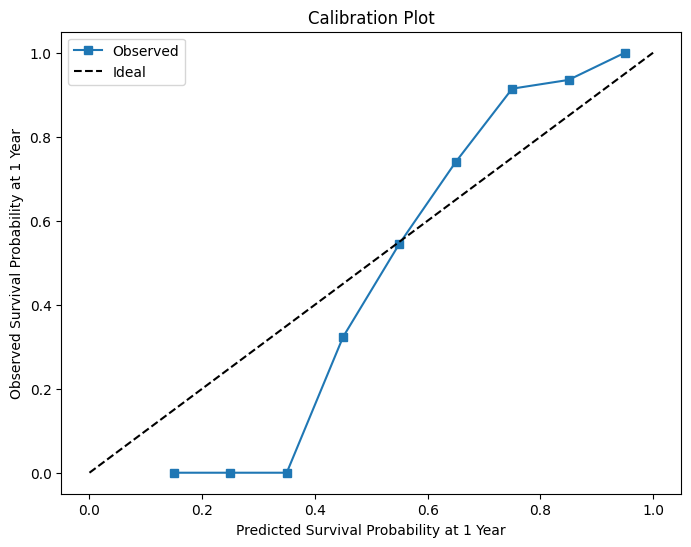

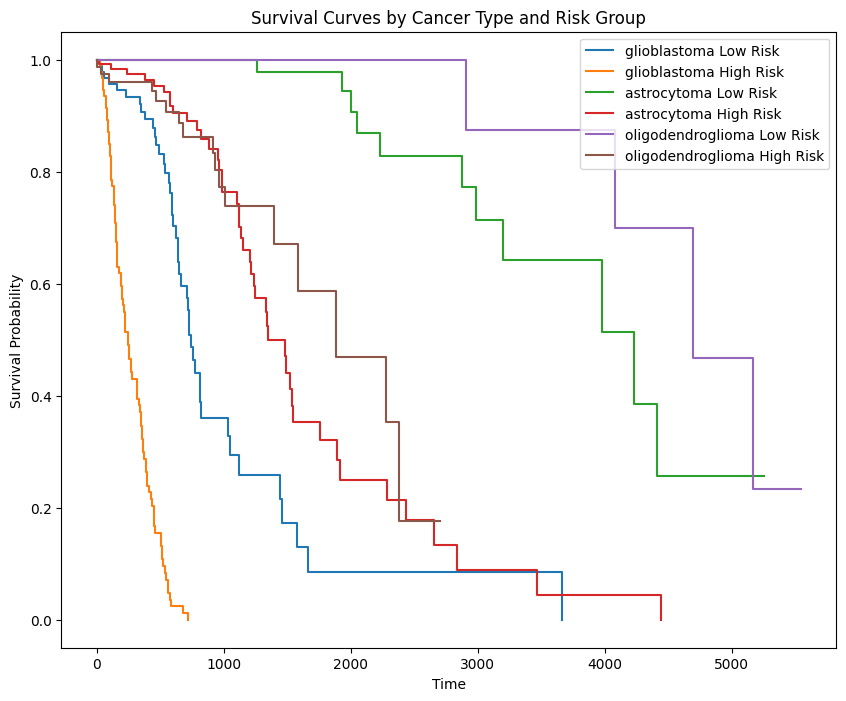

In [122]:
import numpy as np
import pandas as pd
import optuna
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer
from sksurv.metrics import concordance_index_censored
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# -------------------------
# 1. Data Loading & Preprocessing
# -------------------------

# Load dataset and preprocess MGMT
final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")
mgmt_probes = ["cg12434587", "cg12981137"]
assert all(col in final_df.columns for col in mgmt_probes), "❌ Error: MGMT probes are missing from final_df!"

# Convert Beta values to M values
B1 = final_df["cg12434587"].astype(float)
B2 = final_df["cg12981137"].astype(float)
B1 = np.clip(B1, 1e-6, 1 - 1e-6)
B2 = np.clip(B2, 1e-6, 1 - 1e-6)
M1 = np.log2(B1 / (1 - B1))
M2 = np.log2(B2 / (1 - B2))

# Compute MGMT methylation probability
y_mgmt = 4.3215 + 0.5271 * M1 + 0.9265 * M2
MGMT = 1 / (1 + np.exp(-y_mgmt))
final_df["MGMT"] = MGMT
final_df.drop(columns=mgmt_probes, inplace=True)
print("✅ MGMT column created and probes removed!")

# Data cleaning
final_df = final_df.dropna(subset=["OS.time", "OS"]).copy()
final_df = final_df[final_df["OS.time"] > 0].copy()
cancer_label_col = "classification.2021_simplified.labels"
final_df = final_df[final_df[cancer_label_col] != "unclassified"].copy()
print(f"✅ Filtered dataset: {final_df.shape[0]} rows remaining after cleaning.")

# Composite stratification label (OS event + cancer type)
final_df["stratify_label"] = final_df["OS"].astype(str) + "_" + final_df[cancer_label_col].astype(str)
print("Composite stratification label counts:")
print(final_df["stratify_label"].value_counts())

# Define predictors
# Genes (only those present)
gene_features = ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]
gene_features = [col for col in gene_features if col in final_df.columns]

# Methylation features: all columns starting with "cg"
methylation_features = [col for col in final_df.columns if col.startswith("cg")]

# MGMT as separate feature
mgmt_features = ["MGMT"]

# All predictors (excluding cancer type which will be encoded separately)
all_predictors = gene_features + methylation_features + mgmt_features

# Prepare survival outcome (structured array)
y = Surv.from_dataframe(event="OS", time="OS.time", data=final_df)

# One-hot encode cancer type for modeling (added later)
encoder = OneHotEncoder(drop="first", sparse_output=False)
# Fit on the entire dataset for later use (if you prefer, you can restrict to training only)
encoder.fit(final_df[[cancer_label_col]])

# Create a combined X matrix (all predictors + one-hot encoded cancer type)
X_predictors = final_df[all_predictors].copy()
cancer_oh = pd.DataFrame(encoder.transform(final_df[[cancer_label_col]]),
                         index=final_df.index,
                         columns=encoder.get_feature_names_out([cancer_label_col]))
X_all = pd.concat([X_predictors, cancer_oh], axis=1)
X_all = X_all.fillna(X_all.median())  # simple imputation

# -------------------------
# 2. Cross Validation for Robust Estimate
# -------------------------
# We use StratifiedKFold based on the composite label
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom scorer: we use concordance index (RSF's score returns c-index)
def rsf_cv_score(estimator, X, y_true):
    # y_true is the structured array
    pred = estimator.predict(X)
    # Compute c-index via sksurv.metrics (ignoring censoring details for simplicity)
    result = concordance_index_censored(y_true["event"], y_true["time"], pred)
    return result[0]

scorer = make_scorer(rsf_cv_score, greater_is_better=True)

# Prepare an array to store scores
cv_scores = []

for train_index, test_index in skf.split(X_all, final_df["stratify_label"]):
    X_train_cv = X_all.iloc[train_index]
    X_test_cv  = X_all.iloc[test_index]
    
    # Convert survival outcome for cv splits
    y_train_cv = y[train_index]
    y_test_cv  = y[test_index]
    
    # Train a Random Survival Forest with best parameters (or default for cv)
    # For demonstration, we use default hyperparameters; you can integrate hyperparameter tuning inside cv
    rsf_cv = RandomSurvivalForest(n_estimators=100, random_state=42, n_jobs=-1)
    rsf_cv.fit(X_train_cv, y_train_cv)
    score = rsf_cv.score(X_test_cv, y_test_cv)
    cv_scores.append(score)

print(f"Cross-validated C-index: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# -------------------------
# 3. Calibration Plot at a Fixed Time Horizon
# -------------------------
# Choose a time horizon (e.g., 365 days)
# -------------------------
# 3. Calibration Plot at a Fixed Time Horizon
# -------------------------
# Choose a time horizon (e.g., 365 days)
time_horizon = 365

# Get survival functions as step functions (not as array)
surv_funcs = best_rsf.predict_survival_function(X_all, return_array=False)
# Get the time grid from the first survival function (assuming they share the same grid)
times = surv_funcs[0].x
time_idx = np.argmin(np.abs(times - time_horizon))

# If you prefer to work with arrays, you can also compute:
pred_surv_array = best_rsf.predict_survival_function(X_all, return_array=True)
# Get predicted survival probabilities at the chosen time horizon
pred_prob = pred_surv_array[:, time_idx]

# Now, bin the predicted probabilities and compute observed survival using Kaplan–Meier.
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
observed_probs = []

kmf = KaplanMeierFitter()
for i in range(len(bins) - 1):
    in_bin = (pred_prob >= bins[i]) & (pred_prob < bins[i+1])
    if np.sum(in_bin) < 5:
        observed_probs.append(np.nan)
        continue
    kmf.fit(durations=final_df.loc[in_bin, "OS.time"],
            event_observed=final_df.loc[in_bin, "OS"])
    obs_prob = kmf.predict(time_horizon)
    observed_probs.append(obs_prob)

# Plot calibration curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, observed_probs, "s-", label="Observed")
plt.plot([0,1], [0,1], "k--", label="Ideal")
plt.xlabel("Predicted Survival Probability at 1 Year")
plt.ylabel("Observed Survival Probability at 1 Year")
plt.title("Calibration Plot")
plt.legend()
plt.show()


# -------------------------
# 4. Stratify High/Low Risk Groups by Cancer Type and Plot Survival Curves
# -------------------------
# First, predict risk scores for all subjects using the best RSF model.
risk_scores_all = best_rsf.predict(X_all)

# Add risk scores and cancer type to the DataFrame
final_df["Risk_Score"] = risk_scores_all

# Plot KM curves for each cancer type stratified by risk (split at median risk within that type)
plt.figure(figsize=(10, 8))
for cancer in final_df[cancer_label_col].unique():
    subset = final_df[final_df[cancer_label_col] == cancer]
    median_risk = subset["Risk_Score"].median()
    low_risk = subset[subset["Risk_Score"] <= median_risk]
    high_risk = subset[subset["Risk_Score"] > median_risk]
    
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()
    ax = plt.gca()
    
    kmf_low.fit(durations=low_risk["OS.time"], event_observed=low_risk["OS"],
                label=f"{cancer} Low Risk")
    kmf_high.fit(durations=high_risk["OS.time"], event_observed=high_risk["OS"],
                 label=f"{cancer} High Risk")
    kmf_low.plot_survival_function(ax=ax, ci_show=False)
    kmf_high.plot_survival_function(ax=ax, ci_show=False)

plt.title("Survival Curves by Cancer Type and Risk Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()





=== Multivariate Log-Rank Test ===


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.00 0.96      0.06


=== Pairwise Log-Rank Test Results ===
                   Group1                  Group2  TestStatistic       p-value
0       glioblastoma_high         astrocytoma_low     252.104117  9.030893e-57
1       glioblastoma_high        astrocytoma_high     217.409511  3.322386e-49
2       glioblastoma_high   oligodendroglioma_low     176.494819  2.823477e-40
3       glioblastoma_high  oligodendroglioma_high     137.910126  7.625084e-32
4        glioblastoma_low       glioblastoma_high     122.972024  1.414290e-28
5        glioblastoma_low         astrocytoma_low     107.732695  3.075865e-25
6        glioblastoma_low   oligodendroglioma_low      73.409416  1.053623e-17
7        astrocytoma_high         astrocytoma_low      55.318221  1.025139e-13
8        astrocytoma_high   oligodendroglioma_low      45.268584  1.717827e-11
9         astrocytoma_low  oligodendroglioma_high      32.595858  1.134563e-08
10  oligodendroglioma_low  oligodendroglioma_high      27.661322  1.445237e-07
11       gli

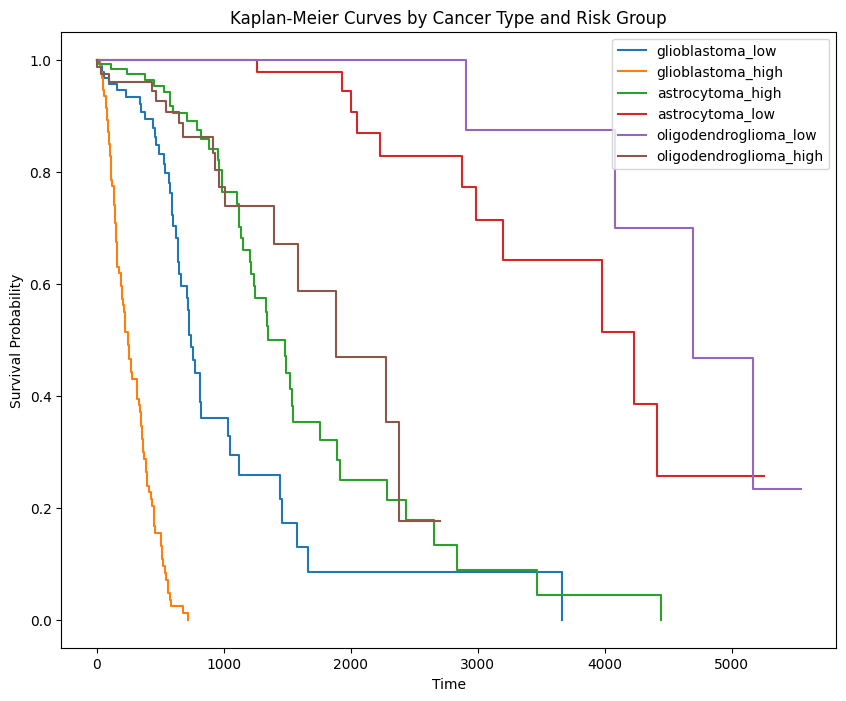

In [124]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# -----------------------------------------------------------------------------
# 1. Create "group" labels: <cancer>_<low/high>
#    (Assuming you already have 'OS.time', 'OS', 'Risk_Score', and 'classification.2021_simplified.labels' in final_df)
# -----------------------------------------------------------------------------
unique_cancers = final_df["classification.2021_simplified.labels"].unique()
for cancer in unique_cancers:
    mask = final_df["classification.2021_simplified.labels"] == cancer
    median_risk = final_df.loc[mask, "Risk_Score"].median()
    final_df.loc[mask, "Risk_Group"] = np.where(
        final_df.loc[mask, "Risk_Score"] <= median_risk, "low", "high"
    )

final_df["group"] = (
    final_df["classification.2021_simplified.labels"] + "_" + final_df["Risk_Group"]
)

# -----------------------------------------------------------------------------
# 2. Multivariate Log-Rank Test
# -----------------------------------------------------------------------------
multi_result = multivariate_logrank_test(
    final_df["OS.time"],
    final_df["OS"],
    final_df["group"]
)
print("=== Multivariate Log-Rank Test ===")
multi_result.print_summary()

# -----------------------------------------------------------------------------
# 3. Pairwise Log-Rank Tests
#    We'll store the results in a list of dictionaries.
# -----------------------------------------------------------------------------
groups = final_df["group"].unique()
pairs = list(itertools.combinations(groups, 2))

logrank_results = []
for (g1, g2) in pairs:
    mask1 = final_df["group"] == g1
    mask2 = final_df["group"] == g2

    result = logrank_test(
        final_df.loc[mask1, "OS.time"],
        final_df.loc[mask2, "OS.time"],
        event_observed_A=final_df.loc[mask1, "OS"],
        event_observed_B=final_df.loc[mask2, "OS"]
    )
    logrank_results.append({
        "Group1": g1,
        "Group2": g2,
        "TestStatistic": result.test_statistic,
        "p-value": result.p_value
    })

# Convert the list of dictionaries to a DataFrame for organized display
df_logrank = pd.DataFrame(logrank_results)
df_logrank = df_logrank.sort_values("p-value").reset_index(drop=True)

print("\n=== Pairwise Log-Rank Test Results ===")
print(df_logrank)

# -----------------------------------------------------------------------------
# 4. Plot Kaplan–Meier Curves for All Groups (Optional)
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
kmf = KaplanMeierFitter()

for group_name in groups:
    group_df = final_df[final_df["group"] == group_name]
    kmf.fit(
        durations=group_df["OS.time"],
        event_observed=group_df["OS"],
        label=group_name
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Curves by Cancer Type and Risk Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()


  0%|          | 0/123 [00:00<?, ?it/s]

Aggregated Mean Absolute SHAP Values by Group:
group                                               astrocytoma_high  \
RB1                                                         0.000000   
CDKN2A/B                                                    0.000000   
MDM4                                                        0.338307   
PDGFRA                                                      0.120612   
MDM2                                                        0.000000   
...                                                              ...   
cg22764925                                                  0.000000   
cg03005121                                                  0.000000   
MGMT                                                        0.352969   
classification.2021_simplified.labels_glioblastoma          0.004479   
classification.2021_simplified.labels_oligodend...          0.110860   

group                                               astrocytoma_low  \
RB1              

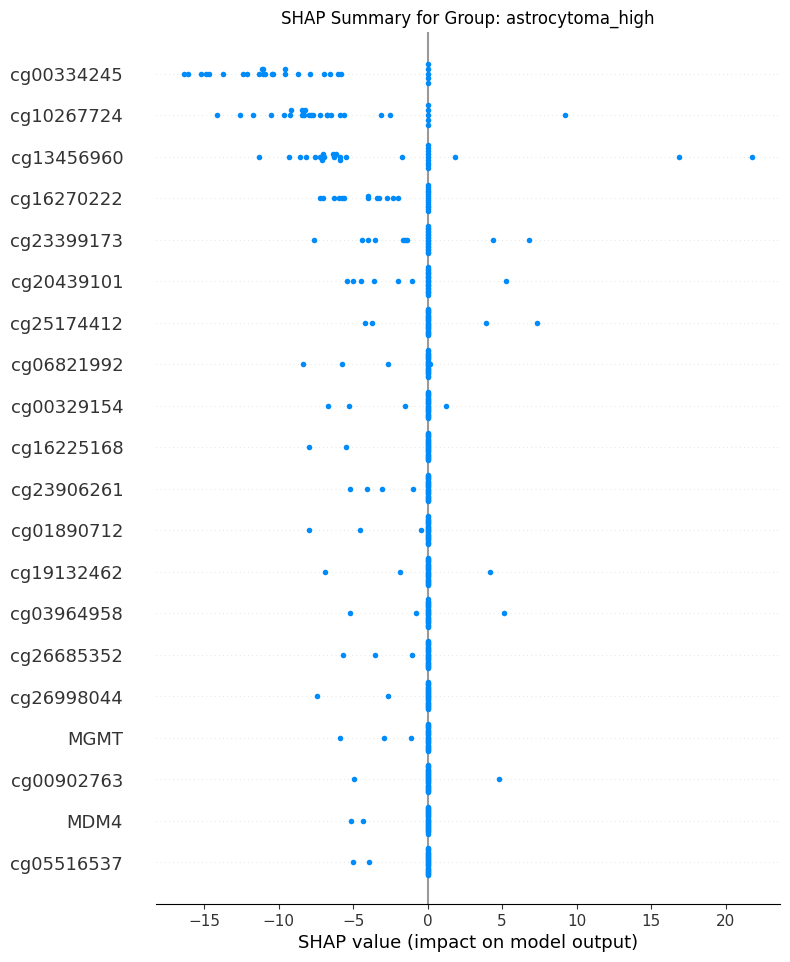

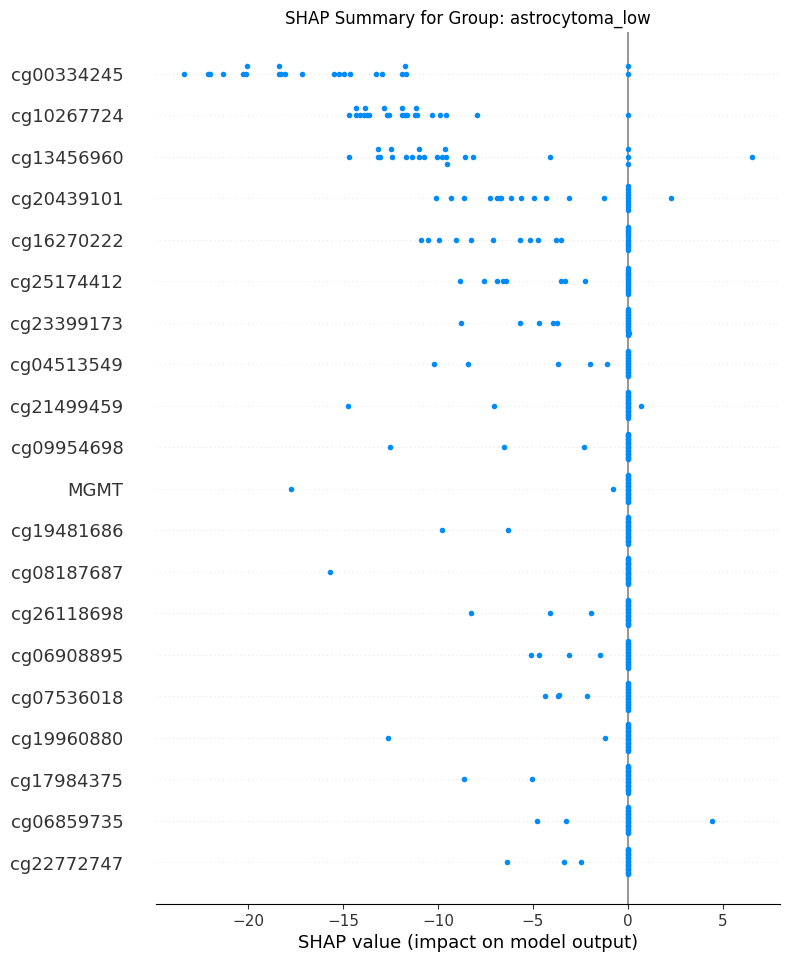

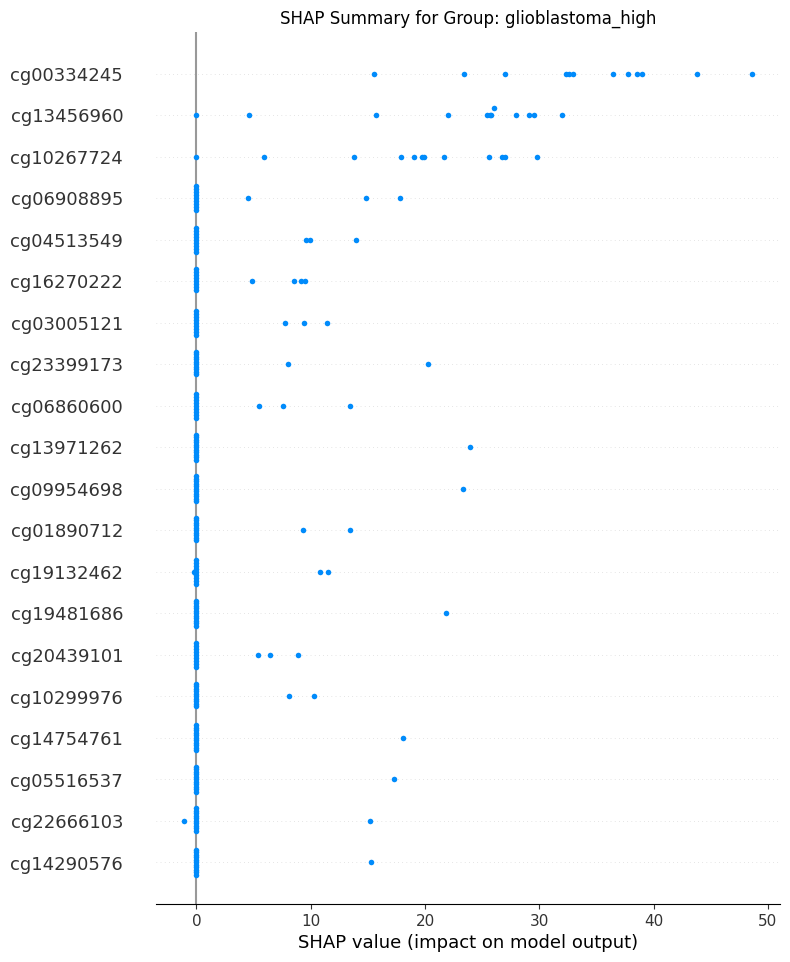

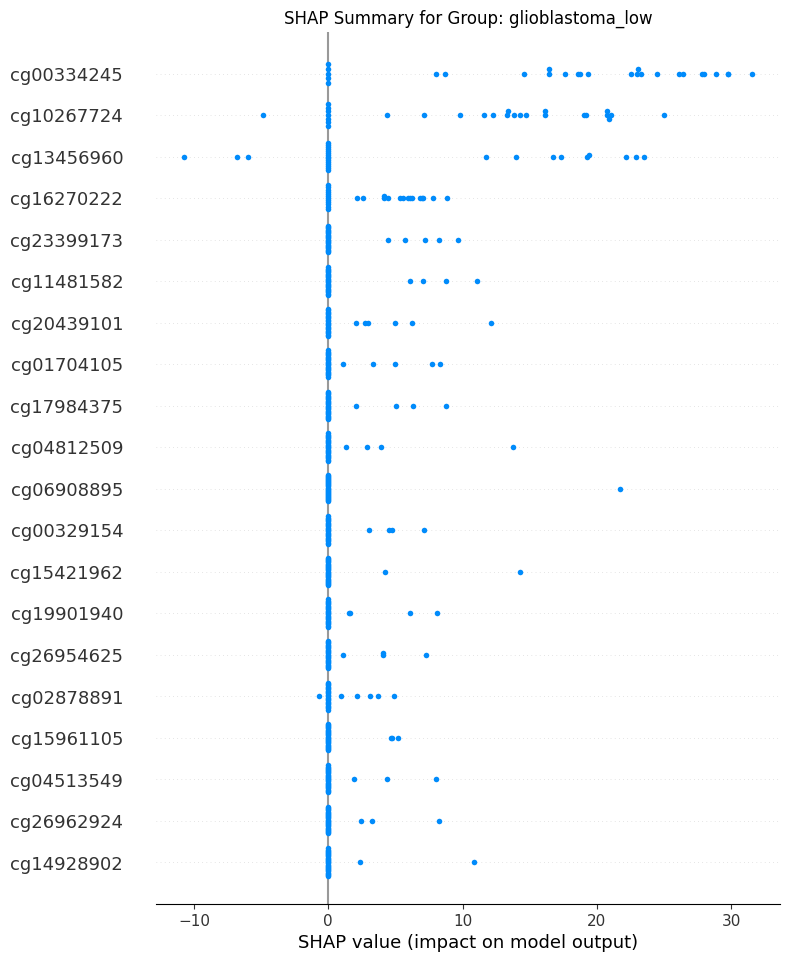

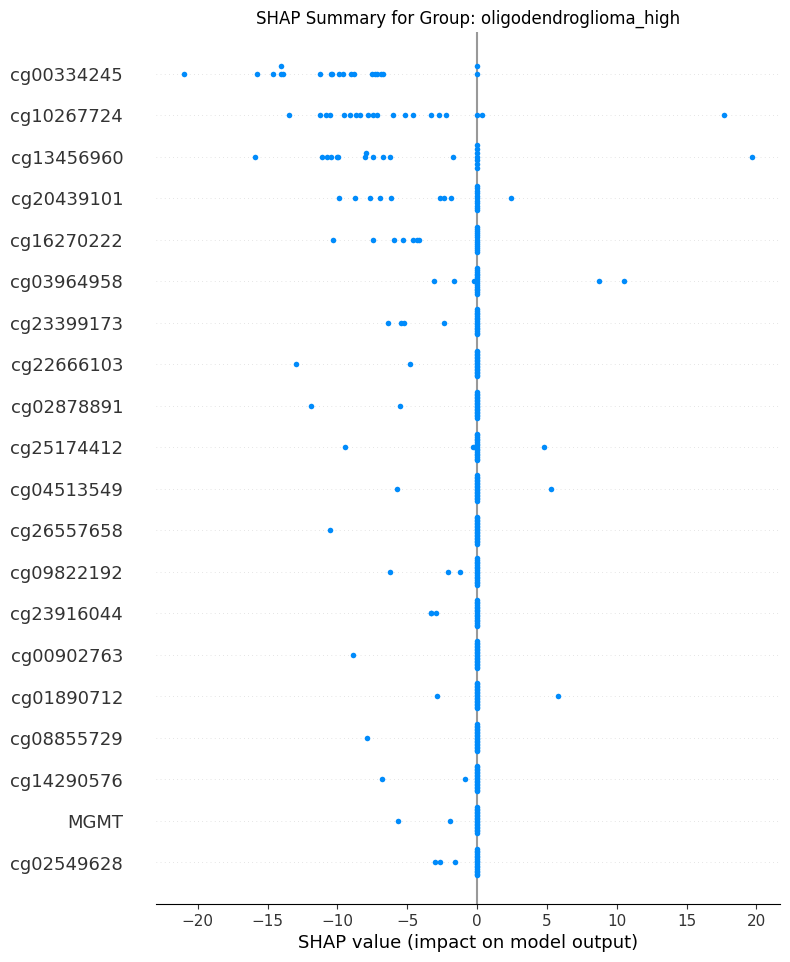

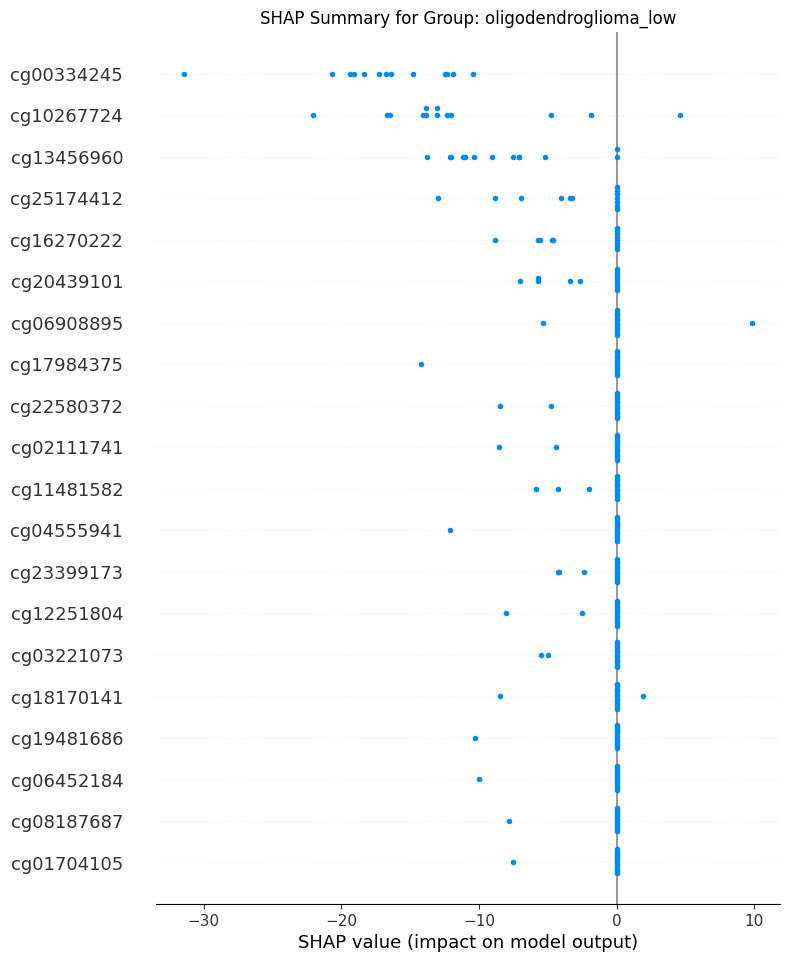

In [127]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare a background sample for the KernelExplainer ---
# We use a subset of the training data as background.
X_sample = X_train.sample(n=100, random_state=42)

# --- Create a SHAP KernelExplainer using the RSF model's predict function ---
# Note: best_rsf.predict returns risk scores.
explainer = shap.KernelExplainer(best_rsf.predict, X_sample)

# --- Compute SHAP values on the test set ---
# Note: nsamples controls the number of Monte Carlo samples used; increase for more precision.
shap_values = explainer.shap_values(X_test, nsamples=100)

# Convert the SHAP values to a DataFrame for easier handling
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

# --- Join subgroup information (cancer type and risk group) ---
# We assume that final_df already contains the "classification.2021_simplified.labels",
# "Risk_Score", "Risk_Group", and combined "group" columns as set up earlier.
subgroup_info = final_df.loc[X_test.index, ["classification.2021_simplified.labels", "Risk_Group", "group"]]
shap_df = shap_df.join(subgroup_info)

# --- Aggregate SHAP values by subgroup ---
# Here we compute the mean absolute SHAP value for each feature in each subgroup.
agg_shap = shap_df.drop(columns=["classification.2021_simplified.labels", "Risk_Group", "group"]).groupby(shap_df["group"]).agg(lambda x: np.mean(np.abs(x)))
print("Aggregated Mean Absolute SHAP Values by Group:")
print(agg_shap.T)  # Transpose for easier reading (features as rows)

# --- Visualize SHAP summaries for each subgroup ---
# Loop over each subgroup and create a summary plot.
for group_name, group_df in shap_df.groupby("group"):
    # Remove subgroup columns for plotting.
    features_data = group_df.drop(columns=["classification.2021_simplified.labels", "Risk_Group", "group"])
    plt.figure()
    shap.summary_plot(features_data.values, features_data.columns, show=False)
    plt.title(f"SHAP Summary for Group: {group_name}")
    plt.show()


Mean Absolute SHAP Values for Gene Features (with MGMT) by Cancer Type:
cancer_type  astrocytoma  glioblastoma  oligodendroglioma
RB1             0.048959      0.194565           0.000000
CDKN2A/B        0.000000      0.056740           0.075198
MDM4            0.066188      0.124606           0.027968
PDGFRA          0.074537      0.269904           0.000000
MDM2            0.000000      0.010599           0.000000
PTEN            0.080926      0.000000           0.052387
EGFR            0.068013      0.327711           0.109513
MGMT            0.243430      0.342894           0.442280


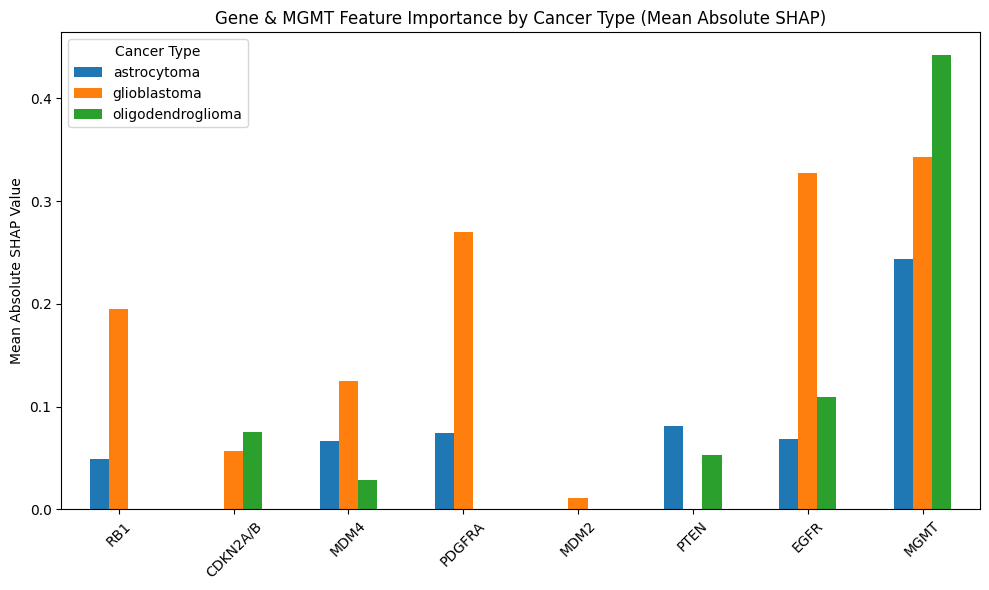

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume that:
# - shap_df_full is a DataFrame with SHAP values computed for the full model on X_test.
# - It has the same columns as X_all.
# - The cancer type is stored in final_df in the column "classification.2021_simplified.labels".
# - gene_features is a list of gene feature names (e.g., ["RB1", "CDKN2A/B", "MDM4", "PDGFRA", "MDM2", "PTEN", "EGFR"]).

# Create a combined list of gene features plus MGMT.
gene_MGMT_features = gene_features + ["MGMT"]

# Create a DataFrame of SHAP values for these features from the full model.
# We assume shap_df_full was built as:
# shap_df_full = pd.DataFrame(shap_values, columns=X_all.columns, index=X_test.index)
shap_genes = shap_df_full[gene_MGMT_features].copy()

# Add the cancer type information from final_df (using the same index as X_test).
shap_genes["cancer_type"] = final_df.loc[X_test.index, "classification.2021_simplified.labels"]

# Now, group by cancer type and compute the mean absolute SHAP value for each gene/MGMT feature.
agg_shap_by_cancer = shap_genes.groupby("cancer_type").agg(lambda x: np.mean(np.abs(x)))
print("Mean Absolute SHAP Values for Gene Features (with MGMT) by Cancer Type:")
print(agg_shap_by_cancer.T)  # Transpose for easier reading (features as rows)

# Optionally, plot the results as a grouped bar chart.
agg_shap_by_cancer_T = agg_shap_by_cancer.T  # genes as rows, cancer types as columns

agg_shap_by_cancer_T.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Mean Absolute SHAP Value")
plt.title("Gene & MGMT Feature Importance by Cancer Type (Mean Absolute SHAP)")
plt.xticks(rotation=45)
plt.legend(title="Cancer Type")
plt.tight_layout()
plt.show()


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    brier_score
)

warnings.filterwarnings("ignore")
random_state = 42

# -----------------------------------------------------------------------------
# Define Additional Gene Features and Feature Selection Function
# -----------------------------------------------------------------------------
additional_genes = ['RB1', 'CDKN2A/B', 'MDM4', 'PDGFRA', 'MDM2', 'PTEN', 'EGFR']

def select_features(df):
    """
    Select all methylation features (columns starting with "cg")
    and additional gene features.
    """
    cg_cols = [col for col in df.columns if col.startswith("cg")]
    genes = [col for col in additional_genes if col in df.columns]
    return cg_cols + genes

# -----------------------------------------------------------------------------
# Prepare Features: Include Cancer Type as a Categorical Variable
# -----------------------------------------------------------------------------
def prepare_features(final_df):
    """
    Filters out unclassified samples, one-hot encodes the cancer type 
    (classification.2021_simplified.labels), and selects features.
    Returns:
      - X: DataFrame of predictors (methylation, genes, and cancer type dummies)
      - y: DataFrame with survival info (OS and OS.time)
      - df: The filtered DataFrame (for further reference)
    """
    # Filter out unclassified samples.
    df = final_df[final_df['classification.2021_simplified.labels'] != 'unclassified'].copy()
    
    # One-hot encode the cancer classification column.
    if 'classification.2021_simplified.labels' in df.columns:
        dummies = pd.get_dummies(df['classification.2021_simplified.labels'], prefix='cancer')
        df = pd.concat([df, dummies], axis=1)
    
    # Select base features: methylation + additional genes.
    base_features = select_features(df)
    # Also include the dummy variables for cancer types.
    dummy_cols = [col for col in df.columns if col.startswith("cancer_")]
    all_features = base_features + dummy_cols
    
    X = df[all_features]
    y = df[['OS.time', 'OS']]
    return X, y, df

# -----------------------------------------------------------------------------
# Convert Survival Data to Structured Array
# -----------------------------------------------------------------------------
def convert_survival_data(y_df):
    """
    Converts the survival columns ("OS" and "OS.time") into a structured numpy array.
    """
    return np.array([(bool(e), t) for e, t in zip(y_df["OS"], y_df["OS.time"])],
                    dtype=[('event', '?'), ('time', '<f8')])

# -----------------------------------------------------------------------------
# Define a Custom Scorer for Permutation Importance
# -----------------------------------------------------------------------------
def rsf_scorer(estimator, X, y):
    """
    Custom scoring function that uses the model's score method.
    """
    return estimator.score(X, y)

# -----------------------------------------------------------------------------
# Overall Random Survival Forest Analysis
# -----------------------------------------------------------------------------
def run_overall_rsf(final_df):
    """
    Performs an overall Random Survival Forest (RSF) analysis on final_df.
    The cancer type is included as a categorical variable (one-hot encoded)
    so that interactions between cancer type and other features are captured.
    
    Reports:
      - Concordance Index (C-index)
      - Time-dependent AUC at specified evaluation times
      - Brier scores at specified evaluation times
      - Risk quantification at 1 year (using 1 - S(365))
      - Permutation-based feature importance
    """
    # Prepare features and survival data.
    X, y, df = prepare_features(final_df)
    
    # Drop rows with missing values.
    valid_idx = X.dropna().index.intersection(y.dropna().index)
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]
    
    # Convert survival data to structured array.
    y_struct = convert_survival_data(y)
    
    # Split into training and test sets.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_struct, test_size=0.3, random_state=random_state
    )
    
    # Fit the RSF model.
    rsf = RandomSurvivalForest(n_estimators=100,
                               min_samples_split=10,
                               min_samples_leaf=15,
                               max_features="sqrt",
                               n_jobs=-1,
                               random_state=random_state)
    rsf.fit(X_train, y_train)
    
    # Calculate concordance index.
    train_ci = rsf.score(X_train, y_train)
    test_ci = rsf.score(X_test, y_test)
    print(f"Overall RSF Model Concordance Index: Train = {train_ci:.3f}, Test = {test_ci:.3f}")
    
    # Define evaluation times (in days): 1, 3, 5, and 7 years.
    eval_times = np.array([365, 1095, 1825, 2555])
    test_times = np.array([t for _, t in y_test])
    max_followup = test_times.max()
    eval_times_valid = eval_times[eval_times <= max_followup]
    if len(eval_times_valid) < len(eval_times):
        print(f"Warning: Some evaluation times exceed follow-up. Using: {eval_times_valid}")
    
    # Compute time-dependent AUC.
    aucs, mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf.predict(X_test), eval_times_valid)
    for t, auc_val in zip(eval_times_valid, aucs):
        print(f"Time {t} days: AUC = {auc_val:.3f}")
    print(f"Mean AUC: {mean_auc:.3f}")
    
    # Compute Brier scores.
    # Evaluate the survival functions at each valid time.
    estimates = np.row_stack([fn(eval_times_valid) for fn in rsf.predict_survival_function(X_test)])
    brier_scores, integrated_brier = brier_score(y_train, y_test, estimates, eval_times_valid)
    for t, brier in zip(eval_times_valid, brier_scores):
        print(f"Time {t} days: Brier Score = {brier:.3f}")
    print(f"Integrated Brier Score: {float(integrated_brier):.3f}")
    
    # Quantify risk using risk score = 1 - survival probability at 1 year (365 days).
    surv_funcs = rsf.predict_survival_function(X_test)
    surv_1yr = np.array([fn(365) for fn in surv_funcs])
    risk_scores = 1 - surv_1yr
    risk_quantiles = np.percentile(risk_scores, [25, 50, 75])
    print("Risk score quartiles at 1 year (1 - S(365)):", risk_quantiles)
    
    # Permutation-based feature importance.
    result = permutation_importance(rsf, X_test, y_test, n_repeats=10, random_state=random_state, scoring=rsf_scorer)
    perm_importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
    print("Top 20 Permutation Importances:")
    print(perm_importances.head(20))
    
    return rsf, X, y, perm_importances

# -----------------------------------------------------------------------------
# Main Workflow
# -----------------------------------------------------------------------------
def main():
    # Load your final_df from CSV (update path as necessary).
    final_df = pd.read_csv("/Users/nijat/Desktop/Final/final_df.csv")
    
    # Run the overall RSF analysis.
    rsf_model, X, y, perm_importances = run_overall_rsf(final_df)
    
    # Save permutation importances to CSV.
    perm_importances.to_csv("/Users/nijat/Desktop/Final/rsf_perm_importances_overall.csv")
    print("Permutation feature importances saved to '/Users/nijat/Desktop/Final/rsf_perm_importances_overall.csv'.")
    
    return rsf_model, X, y, perm_importances

if __name__ == "__main__":
    results = main()


Overall RSF Model Concordance Index: Train = 0.924, Test = 0.863
Time 365 days: AUC = 0.906
Time 1095 days: AUC = 0.962
Time 1825 days: AUC = 0.872
Time 2555 days: AUC = 0.843
Mean AUC: 0.908
Time 365 days: Brier Score = 365.000
Time 1095 days: Brier Score = 1095.000
Time 1825 days: Brier Score = 1825.000
Time 2555 days: Brier Score = 2555.000


TypeError: only length-1 arrays can be converted to Python scalars

Mean Absolute SHAP Values for Gene Features by Cancer Type:
cancer_type  astrocytoma  glioblastoma  oligodendroglioma
RB1             0.048959      0.194565           0.000000
CDKN2A/B        0.000000      0.056740           0.075198
MDM4            0.066188      0.124606           0.027968
PDGFRA          0.074537      0.269904           0.000000
MDM2            0.000000      0.010599           0.000000
PTEN            0.080926      0.000000           0.052387
EGFR            0.068013      0.327711           0.109513


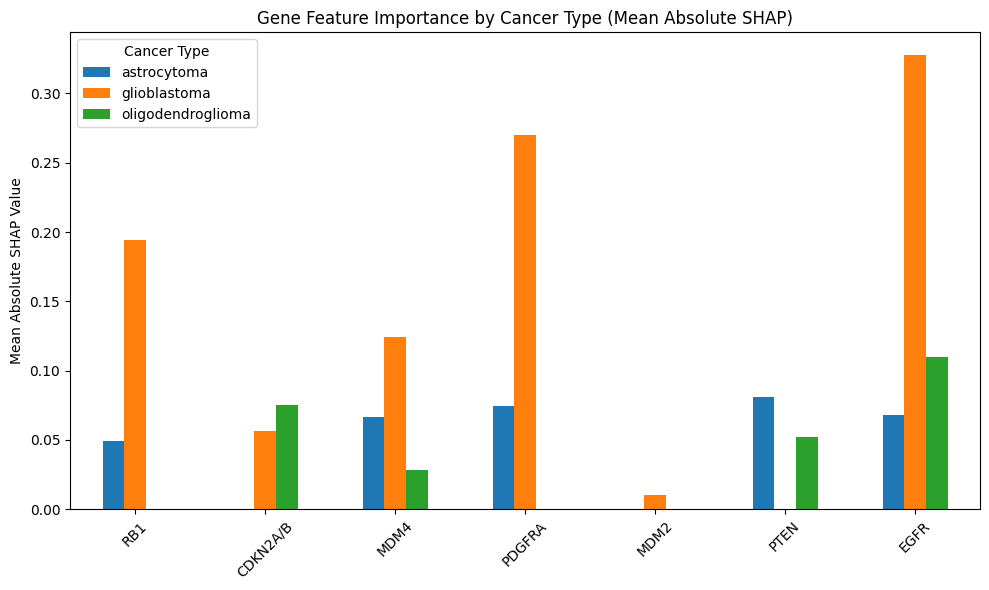

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume that:
# - shap_df_full is a DataFrame with SHAP values computed for the full model on X_test.
# - It has the same columns as X_all.
# - The cancer type is stored in final_df in the column "classification.2021_simplified.labels".

# Create a DataFrame of SHAP values for gene features from the full model.
# Here we assume shap_df_full was built as:
# shap_df_full = pd.DataFrame(shap_values, columns=X_all.columns, index=X_test.index)
# For gene features, select only the columns in gene_features.
shap_genes = shap_df_full[gene_features].copy()

# Add the cancer type information from final_df (using the same index as X_test).
shap_genes["cancer_type"] = final_df.loc[X_test.index, "classification.2021_simplified.labels"]

# Now, group by cancer type and compute the mean absolute SHAP value for each gene.
agg_shap_by_cancer = shap_genes.groupby("cancer_type").agg(lambda x: np.mean(np.abs(x)))
print("Mean Absolute SHAP Values for Gene Features by Cancer Type:")
print(agg_shap_by_cancer.T)  # Transposed for easier reading (genes as rows)

# Optionally, plot the results as a grouped bar chart.
agg_shap_by_cancer_T = agg_shap_by_cancer.T  # genes as rows, cancer types as columns

agg_shap_by_cancer_T.plot(kind="bar", figsize=(10,6))
plt.ylabel("Mean Absolute SHAP Value")
plt.title("Gene Feature Importance by Cancer Type (Mean Absolute SHAP)")
plt.xticks(rotation=45)
plt.legend(title="Cancer Type")
plt.tight_layout()
plt.show()


In [135]:
# Create DataFrame using the index of X_test (which has 123 rows)
shap_df_full = pd.DataFrame(shap_values, columns=X_all.columns, index=X_test.index)

# Now extract only gene feature SHAP values
shap_genes = shap_df_full[gene_features]

# For example, compute and print descriptive statistics:
print(shap_genes.describe())

# Or compute mean absolute SHAP values for each gene:
agg_shap_genes = np.mean(np.abs(shap_genes), axis=0)
print("Mean Absolute SHAP Values for Gene Features:")
print(agg_shap_genes.sort_values(ascending=False))



              RB1    CDKN2A/B        MDM4      PDGFRA        MDM2        PTEN  \
count  123.000000  123.000000  123.000000  123.000000  123.000000  123.000000   
mean     0.041391   -0.002184    0.004562    0.054674    0.003361   -0.047610   
std      0.545237    0.244766    0.498268    0.982094    0.037272    0.402288   
min     -2.496909   -1.562998   -1.939061   -1.972988    0.000000   -4.127232   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
max      5.040220    1.993718    4.859648   10.526253    0.413364    0.000000   

             EGFR  
count  123.000000  
mean    -0.079553  
std      0.923675  
min     -7.741591  
25%      0.000000  
50%      0.000000  
75%      0.000000  
max      5.039130  
Mean Absolute SHAP Values for Gene Features:
EGFR        0.161490
PDGFRA      0.116485
RB1

  0%|          | 0/123 [00:00<?, ?it/s]

Aggregated Mean Absolute SHAP Values by Group:
group                                               astrocytoma_high  \
RB1                                                         0.089175   
CDKN2A/B                                                    0.000000   
MDM4                                                        0.069252   
PDGFRA                                                      0.065300   
MDM2                                                        0.000000   
...                                                              ...   
cg22764925                                                  0.000000   
cg03005121                                                  0.124399   
MGMT                                                        0.223174   
classification.2021_simplified.labels_glioblastoma          0.131771   
classification.2021_simplified.labels_oligodend...          0.133991   

group                                               astrocytoma_low  \
RB1              

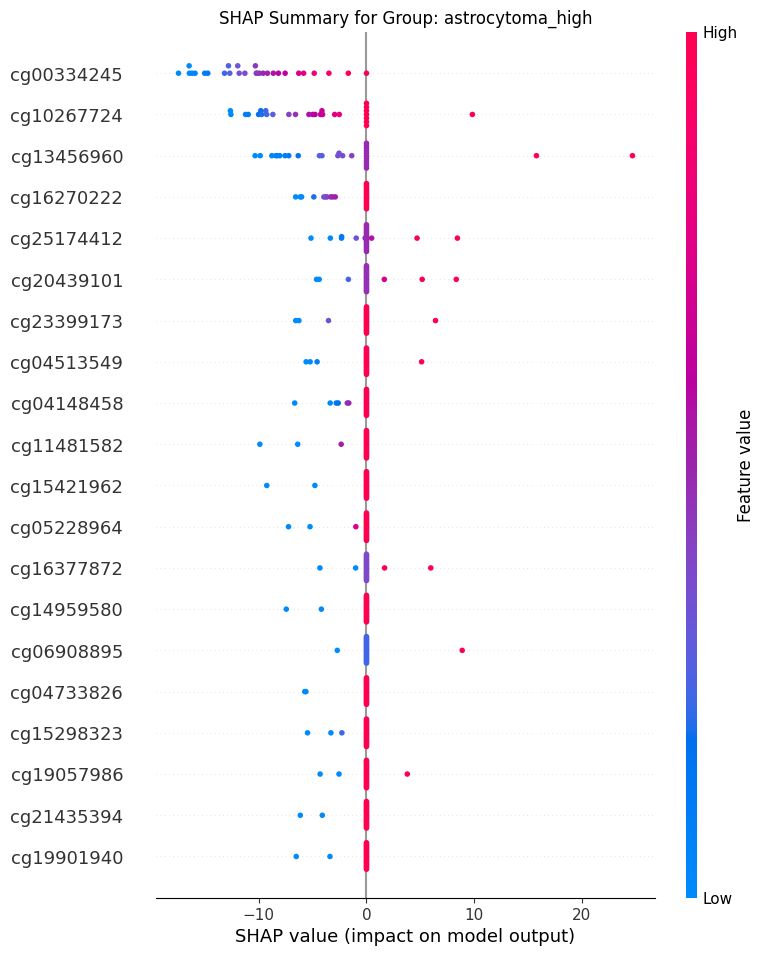

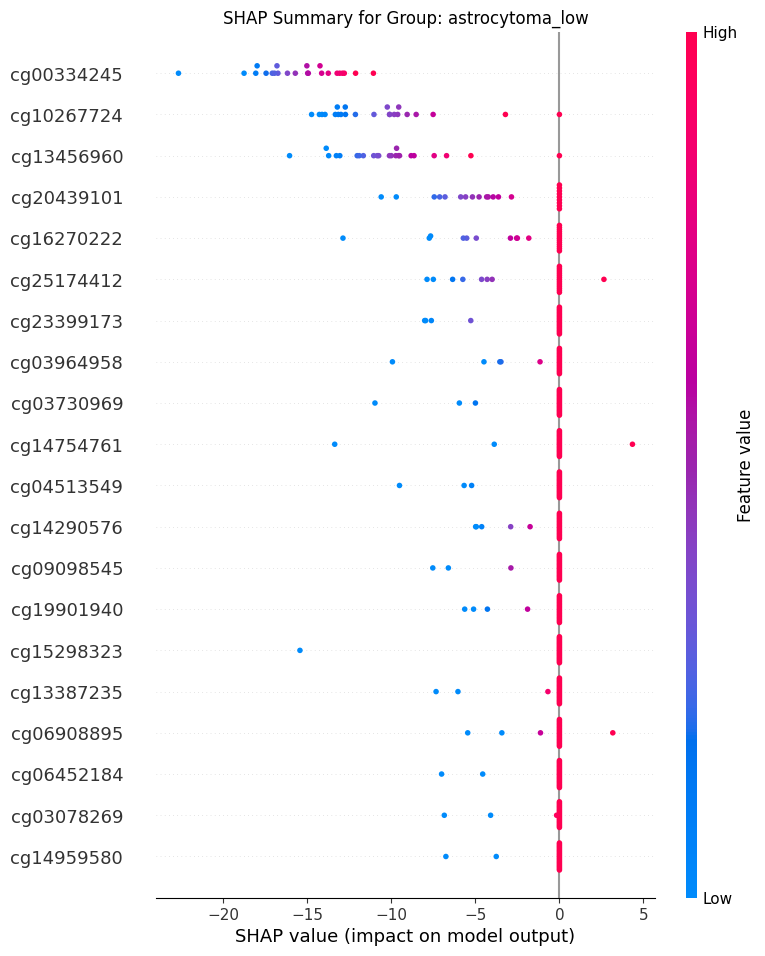

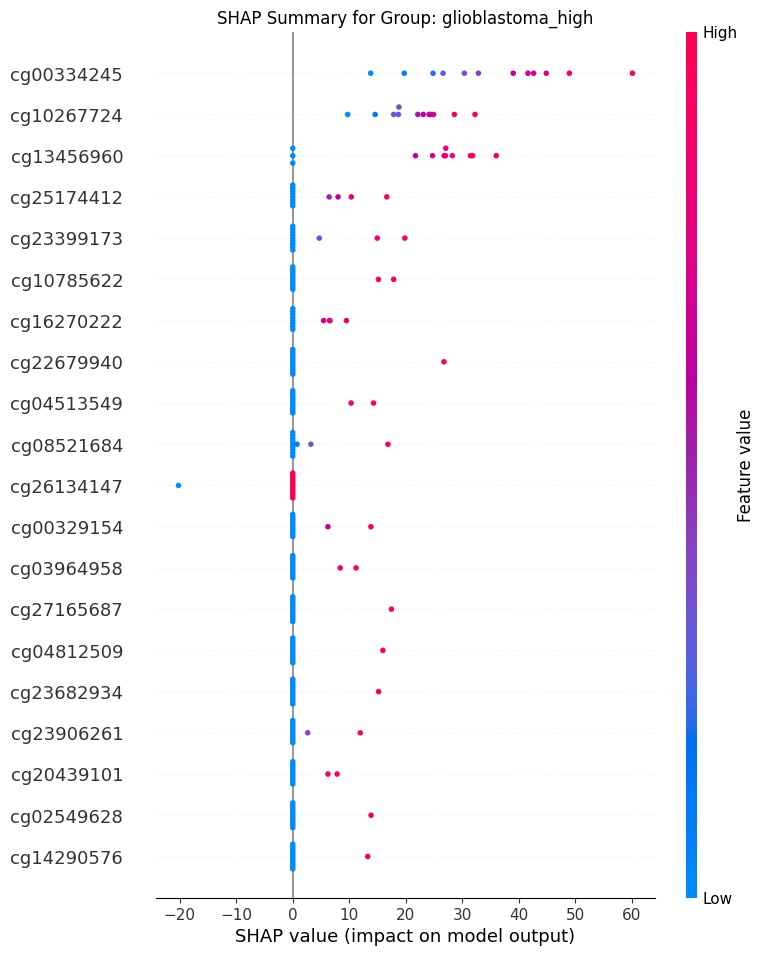

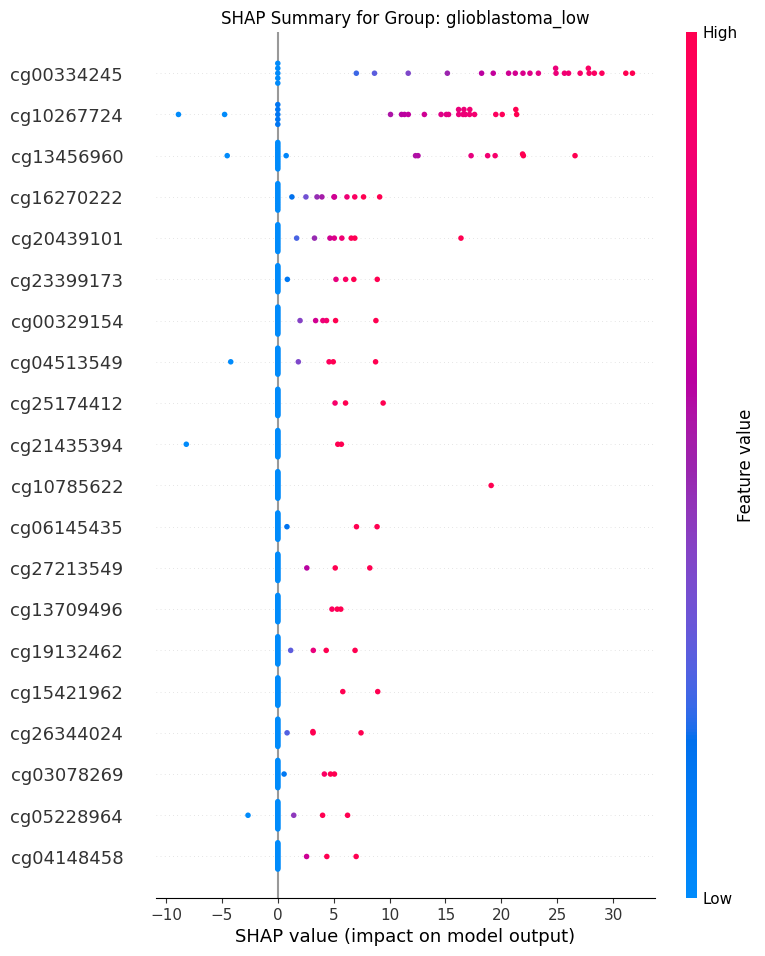

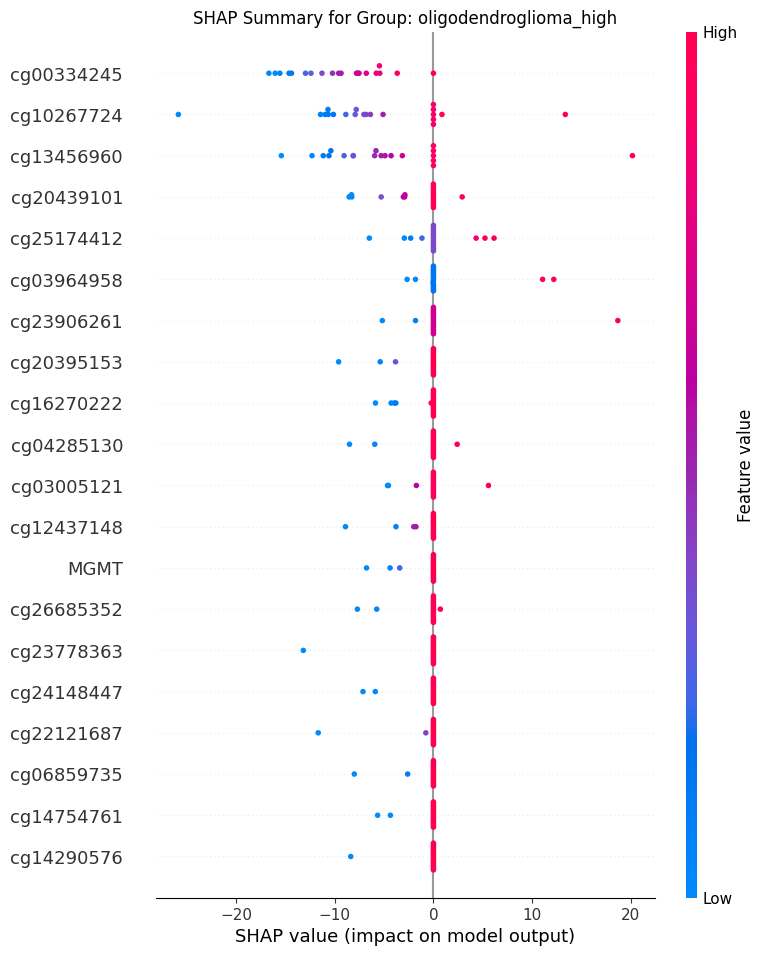

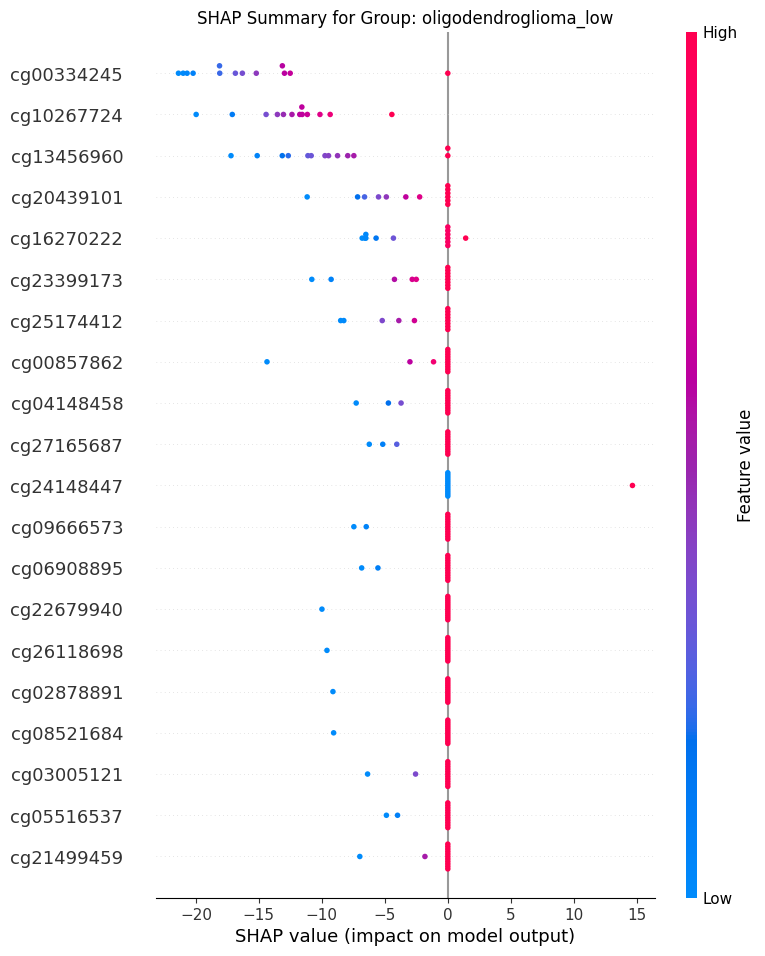

In [131]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare a background sample for the KernelExplainer ---
# We use a subset of the training data as background.
X_sample = X_train.sample(n=100, random_state=42)

# --- Create a SHAP KernelExplainer using the RSF model's predict function ---
# Note: best_rsf.predict returns risk scores.
explainer = shap.KernelExplainer(best_rsf.predict, X_sample)

# --- Compute SHAP values on the test set ---
# nsamples controls the number of Monte Carlo samples used; increase for more precision.
shap_values = explainer.shap_values(X_test, nsamples=100)

# Convert the SHAP values to a DataFrame for easier handling
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

# --- Join subgroup information (cancer type and risk group) ---
# We assume that final_df already contains the "classification.2021_simplified.labels",
# "Risk_Score", "Risk_Group", and combined "group" columns as set up earlier.
subgroup_info = final_df.loc[X_test.index, ["classification.2021_simplified.labels", "Risk_Group", "group"]]
shap_df = shap_df.join(subgroup_info)

# --- Aggregate SHAP values by subgroup ---
# Compute the mean absolute SHAP value for each feature in each subgroup.
agg_shap = shap_df.drop(columns=["classification.2021_simplified.labels", "Risk_Group", "group"]).groupby(shap_df["group"]).agg(lambda x: np.mean(np.abs(x)))
print("Aggregated Mean Absolute SHAP Values by Group:")
print(agg_shap.T)  # Transpose for easier reading (features as rows)

# --- Visualize SHAP summaries for each subgroup ---
# Loop over each subgroup and create a summary plot.
for group_name, group_df in shap_df.groupby("group"):
    # Remove subgroup columns for plotting.
    features_data = group_df.drop(columns=["classification.2021_simplified.labels", "Risk_Group", "group"])
    plt.figure()
    # Now pass the actual feature values (features_data) as the second argument for coloring.
    shap.summary_plot(features_data.values, features_data, feature_names=features_data.columns, show=False)
    plt.title(f"SHAP Summary for Group: {group_name}")
    plt.show()
